# Projeto de Pós-Graduação — Análise de Dados em Séries Financeiras Baseadas em Renko

**Tema central:** estudo da excursão contrária futura (`future_mae_h1`), análise do efeito de transformações no alvo, seleção de features e avaliação operacional via backtest.


## Roteiro de leitura do notebook

Este notebook foi reorganizado para funcionar como **documento técnico-acadêmico** e, ao mesmo tempo, preservar a reprodutibilidade do experimento.

### Estrutura principal
1. **Problema, hipóteses e tipo de estudo**
2. **Dados, construção do alvo e atributos**
3. **Transformações do alvo e análise exploratória**
4. **Seleção de features e comparação entre representações do alvo**
5. **Modelagem supervisionada**
6. **Backtest e avaliação operacional**
7. **Conclusões**

### Como ler
- O **corpo principal** do trabalho está nas seções numeradas acima.
- Blocos de apoio mais técnicos ou laterais foram mantidos, mas marcados como **exploratórios** ou **apêndice técnico**.
- O objetivo desta organização é tornar mais clara a lógica do projeto: **definição do problema → transformação do alvo → seleção de variáveis → modelagem → validação operacional**.


# 1. Descrição do Problema

Este projeto investiga a dinâmica da **excursão contrária futura** em séries financeiras representadas por gráfico Renko. O fenômeno de interesse é modelado pela variável `future_mae_h1`, construída para representar a magnitude do pavio contrário ao sentido do Renko futuro. Em termos práticos, trata-se de uma medida da intensidade do movimento adverso esperado no passo seguinte, com relevância direta para controle de risco, desenho de entradas escalonadas e avaliação de robustez operacional.

O problema central do trabalho não é apenas prever um valor numérico futuro, mas compreender como **diferentes representações do alvo** alteram a estrutura estatística observada entre o alvo e o conjunto de features. Em particular, o estudo compara duas abordagens de transformação:

1. **transformação logarítmica seguida de diferenciação fracionária**;
2. **diferenciação fracionária sem transformação logarítmica**.

A motivação dessa comparação é metodológica: a transformação do alvo pode mudar não apenas sua escala, mas também o tipo de regularidade que passa a ser visível na análise. Em consequência, a escolha da transformação influencia a seleção de features, a interpretação do processo gerador dos dados e a formulação do problema preditivo.

Além da dimensão estatística, o projeto também possui uma dimensão aplicada. Os resultados da análise são conectados a regras de decisão e a backtests, de modo a verificar se os padrões encontrados no espaço das features podem ser traduzidos em lógica operacional consistente.

## 1.1 Hipóteses do Problema

As hipóteses orientadoras do estudo são as seguintes:

1. A transformação do alvo `future_mae_h1` altera significativamente o padrão de associação entre o alvo e o conjunto de features disponíveis.
2. A versão **log-transformada e fracionariamente diferenciada** tende a evidenciar maior associação com variáveis categóricas ou discretas ligadas a **estado, direção e regime**.
3. A versão **fracionariamente diferenciada sem logaritmo** tende a preservar maior associação com variáveis contínuas relacionadas à **magnitude, intensidade e distância** do movimento.
4. A escolha da transformação do alvo influencia não apenas o desempenho de modelos supervisionados, mas também a própria etapa de **seleção de features** e a interpretação do fenômeno estudado.
5. Uma modelagem probabilística baseada em estados discretos e percentis condicionais pode oferecer informação operacional adicional em relação a abordagens puramente pontuais.

## 1.2 Tipo de Problema

O trabalho combina diferentes perspectivas de análise de dados:

- **análise exploratória**, para investigar a distribuição do alvo e de suas transformações;
- **engenharia de variáveis**, com ênfase na construção de medidas de direção, regime e scores discretos;
- **seleção de features**, orientada por medidas de associação e por critérios de interpretabilidade;
- **modelagem supervisionada**, tanto em formulações de regressão quanto em formulações orientadas a eventos/faixas;
- **avaliação operacional**, por meio de backtests e regras de entrada/saída.

Do ponto de vista formal, o projeto contém componentes de:

- **regressão**, quando o interesse recai sobre a magnitude contínua de `future_mae_h1`;
- **classificação e estimação de eventos**, quando o problema é reformulado em termos de probabilidades condicionais, faixas de percentis ou ocorrência de regiões operacionais específicas.

Portanto, trata-se de um problema de **análise de dados aplicada com modelagem supervisionada híbrida**, em que a representação do alvo é parte central da metodologia.

## 1.3 Seleção de Dados

Os dados foram construídos a partir de uma base de mercado em **gráfico Renko**, escolhida por enfatizar deslocamentos efetivos de preço e reduzir parte do ruído associado ao tempo cronológico. Essa representação é particularmente útil quando o objetivo é estudar movimentos de excursão e pavios, pois a estrutura do Renko favorece a leitura de continuidade, reversão e magnitude relativa dos deslocamentos.

O conjunto final combina:

- preços OHLC;
- variáveis derivadas de médias móveis;
- variáveis de direção e regime;
- scores discretos de estado;
- medidas de pavio corrente e pavio futuro;
- versões transformadas do alvo, incluindo diferenciação fracionária e variantes com/sem logaritmo.

A seleção dos dados não foi pensada apenas para maximizar desempenho preditivo, mas para permitir um estudo metodológico sobre como diferentes famílias de atributos reagem a diferentes representações do alvo.

## 1.4 Atributos do Dataset

Os atributos utilizados ao longo do notebook podem ser organizados em quatro grupos principais:

1. **Variáveis de preço e contexto temporal**  
   Exemplos: `Open`, `High`, `Low`, `Close`, `Date`.  
   Essas variáveis constituem a base da estrutura de mercado e são utilizadas tanto na construção do alvo quanto na avaliação operacional.

2. **Variáveis de direção e regime**  
   Exemplos: `dir_1`, `renko_dir_ma9`, `renko_dir_ma20`, `renko_dir_ma50`, `renko_dir_ma200`.  
   Essas variáveis sintetizam o alinhamento do Renko com médias móveis e com estados de persistência/reversão.

3. **Scores e estados discretos/estruturais**  
   Exemplos: `classe_score_*`, `dir_atual_*`, `next_bias_*`, `score_mean_*`, `score_total_*`.  
   Essas variáveis procuram representar configurações qualitativas do mercado em formato discreto ou semidiscreto, permitindo estudos condicionais por combinação exata de estados.

4. **Variáveis transformadas e alvos**  
   Exemplos: `mae_h1`, `future_mae_h1`, `frac_future_mae_h1` e derivações.  
   Esse grupo concentra a parte metodologicamente mais importante do projeto, pois é nele que se definem o alvo principal e suas representações alternativas.

Ao longo do notebook, algumas variáveis são utilizadas apenas em caráter exploratório, enquanto outras são incorporadas à etapa de modelagem e validação.

# 2. Importação das Bibliotecas Necessárias e Definição de Funções Auxiliares

A seção a seguir reúne bibliotecas e funções de apoio usadas em diferentes etapas do projeto: leitura dos dados, engenharia de atributos, diferenciação fracionária, transformadores probabilísticos, avaliação de modelos e apoio ao backtest.

> **Nota metodológica:** no notebook original, muitas funções foram sendo adicionadas conforme a pesquisa avançava. Nesta versão organizada, elas foram mantidas no início para facilitar reutilização.


In [1]:
import numpy as np
import pandas as pd


def build_renko_4class_target_pandas(
    df: pd.DataFrame,
    dir_col: str = "dir_1",
    horizon: int = 3,
    target_col: str = "target_4c",
    sum_col: str = "soma_dir_futura",
    neutral_value=np.nan
) -> pd.DataFrame:
    out = df.copy()

    if dir_col not in out.columns:
        raise KeyError(f"Coluna '{dir_col}' não encontrada.")

    future_dirs = pd.concat(
        [out[dir_col].shift(-i) for i in range(1, horizon + 1)],
        axis=1
    )

    future_sum = future_dirs.sum(axis=1, min_count=horizon)

    target = pd.Series(neutral_value, index=out.index, dtype="float64")

    target.loc[(future_sum >= 2).fillna(False)] = 2
    target.loc[(future_sum == 1).fillna(False)] = 1
    target.loc[(future_sum == -1).fillna(False)] = -1
    target.loc[(future_sum <= -2).fillna(False)] = -2

    out[sum_col] = future_sum
    out[target_col] = target

    return out

In [2]:
import numpy as np
import pandas as pd


def make_event(series, mode="le", threshold=None, lower=None, upper=None):
    s = pd.to_numeric(series, errors="coerce")

    if mode == "le":
        if threshold is None:
            raise ValueError("Para mode='le', informe threshold.")
        return s <= threshold

    elif mode == "ge":
        if threshold is None:
            raise ValueError("Para mode='ge', informe threshold.")
        return s >= threshold

    elif mode == "between":
        if lower is None or upper is None:
            raise ValueError("Para mode='between', informe lower e upper.")
        return (s >= lower) & (s <= upper)

    elif mode == "abs_ge":
        if threshold is None:
            raise ValueError("Para mode='abs_ge', informe threshold.")
        return s.abs() >= threshold

    else:
        raise ValueError(f"Modo inválido: {mode}")


def _mode_rounded(s, step=25):
    s = pd.to_numeric(pd.Series(s), errors="coerce").dropna()
    if len(s) == 0:
        return np.nan
    rounded = (s / step).round() * step
    m = rounded.mode()
    if len(m) == 0:
        return np.nan
    return float(m.iloc[0])


def _q(p):
    def f(s):
        s = pd.to_numeric(pd.Series(s), errors="coerce").dropna()
        if len(s) == 0:
            return np.nan
        return float(s.quantile(p))
    return f


def build_discrete_probability_study(
    df,
    y="future_mae_h1",
    discrete_vars=None,
    train_frac=0.70,
    min_count=20,
    event_mode="between",
    threshold=None,
    lower=None,
    upper=None,
    mode_round_step=25,
    sort_by="prob_event",
):
    """
    Estudo probabilístico por combinação EXATA de variáveis discretas.
    """
    discrete_vars = discrete_vars or []

    if len(discrete_vars) == 0:
        raise ValueError("Informe ao menos uma variável discreta em discrete_vars.")

    needed_cols = list(dict.fromkeys(discrete_vars + [y]))
    data = df[needed_cols].copy()

    # alvo numérico
    data[y] = pd.to_numeric(data[y], errors="coerce")

    # variáveis discretas mantidas como estão
    data = data.dropna().reset_index(drop=True)

    if len(data) == 0:
        raise ValueError("DataFrame vazio após dropna.")

    split_idx = int(len(data) * train_frac)
    train = data.iloc[:split_idx].copy()
    test = data.iloc[split_idx:].copy()

    if len(train) == 0 or len(test) == 0:
        raise ValueError("Train ou test ficou vazio. Ajuste train_frac.")

    train["event"] = make_event(train[y], mode=event_mode, threshold=threshold, lower=lower, upper=upper).astype(int)
    test["event"] = make_event(test[y], mode=event_mode, threshold=threshold, lower=lower, upper=upper).astype(int)

    baseline_prob = float(test["event"].mean())

    # probabilidade empírica das combinações no treino
    combo_stats_train = (
        train.groupby(discrete_vars, dropna=False, observed=True)
        .agg(
            train_n=(y, "size"),
            train_prob_event=("event", "mean"),
        )
        .reset_index()
    )

    # aplica no teste
    test = test.merge(combo_stats_train, on=discrete_vars, how="left")

    # fallback para combinações inéditas
    test["train_prob_event"] = test["train_prob_event"].fillna(baseline_prob)
    test["train_n"] = test["train_n"].fillna(0)

    grouped = (
        test.groupby(discrete_vars, dropna=False, observed=True)
        .agg(
            n=(y, "size"),
            baseline_prob=("event", lambda s: baseline_prob),
            prob_event=("event", "mean"),
            train_prob_event=("train_prob_event", "mean"),
            train_n=("train_n", "mean"),
            mean_y=(y, "mean"),
            median_y=(y, "median"),
            mode_y_rounded=(y, lambda s: _mode_rounded(s, step=mode_round_step)),
            p10_y=(y, _q(0.10)),
            p25_y=(y, _q(0.25)),
            p50_y=(y, _q(0.50)),
            p75_y=(y, _q(0.75)),
            p90_y=(y, _q(0.90)),
        )
        .reset_index()
    )

    grouped["lift"] = grouped["prob_event"] / grouped["baseline_prob"]
    grouped["delta_prob"] = grouped["prob_event"] - grouped["baseline_prob"]

    grouped["train_lift"] = grouped["train_prob_event"] / grouped["baseline_prob"]
    grouped["delta_train_prob"] = grouped["train_prob_event"] - grouped["baseline_prob"]

    grouped_valid = grouped[grouped["n"] >= min_count].copy()

    sort_cols_map = {
        "prob_event": ["prob_event", "n"],
        "lift": ["lift", "n"],
        "train_prob_event": ["train_prob_event", "n"],
        "train_lift": ["train_lift", "n"],
    }

    chosen_sort = sort_cols_map.get(sort_by, ["prob_event", "n"])
    ranked = grouped_valid.sort_values(chosen_sort, ascending=[False, False]).reset_index(drop=True)

    return {
        "train": train,
        "test": test,
        "grouped": grouped,
        "grouped_valid": grouped_valid,
        "ranked": ranked,
        "baseline_prob": baseline_prob,
        "discrete_vars": discrete_vars,
    }

In [3]:
import numpy as np
import pandas as pd

def drop_high_spearman_features(
    df: pd.DataFrame,
    threshold: float = 0.90,
    exclude_cols: list[str] | None = None,
    use_abs: bool = True,
    verbose: bool = True
):
    """
    Remove features altamente correlacionadas entre si com base na correlação de Spearman.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame original.
    threshold : float, default=0.90
        Limite de correlação acima do qual uma feature será removida.
    exclude_cols : list[str] | None, default=None
        Colunas a serem preservadas, mesmo que sejam numéricas
        (ex.: ['target', 'Date']).
    use_abs : bool, default=True
        Se True, usa o valor absoluto da correlação.
        Ex.: -0.95 e 0.95 serão tratados igualmente como alta correlação.
    verbose : bool, default=True
        Se True, imprime o relatório das colunas excluídas.

    Retorna
    -------
    df_reduced : pd.DataFrame
        DataFrame com as colunas removidas.
    dropped_cols : list[str]
        Lista das colunas excluídas.
    report_df : pd.DataFrame
        Relatório detalhado das exclusões.
    corr_matrix : pd.DataFrame
        Matriz de correlação de Spearman usada no processo.
    """

    if exclude_cols is None:
        exclude_cols = []

    # Seleciona apenas colunas numéricas elegíveis
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in exclude_cols]

    if len(feature_cols) < 2:
        if verbose:
            print("Não há colunas numéricas suficientes para calcular correlação.")
        return df.copy(), [], pd.DataFrame(), pd.DataFrame()

    # Matriz de correlação de Spearman
    corr_matrix = df[feature_cols].corr(method="spearman")

    if use_abs:
        corr_for_selection = corr_matrix.abs()
    else:
        corr_for_selection = corr_matrix.copy()

    # Correlação média de cada coluna com as demais
    avg_corr = corr_for_selection.mean()

    # Considera apenas a metade superior da matriz
    upper = corr_for_selection.where(
        np.triu(np.ones(corr_for_selection.shape), k=1).astype(bool)
    )

    to_drop = set()
    report = []

    # Percorre pares altamente correlacionados
    for col in upper.columns:
        high_corr_rows = upper.index[upper[col] > threshold].tolist()

        for row in high_corr_rows:
            # Se alguma já foi marcada para exclusão, pula
            if row in to_drop or col in to_drop:
                continue

            corr_value = corr_matrix.loc[row, col]
            corr_value_used = corr_for_selection.loc[row, col]

            # Critério:
            # remove a coluna com maior correlação média com o resto
            if avg_corr[row] >= avg_corr[col]:
                drop_col = row
                keep_col = col
            else:
                drop_col = col
                keep_col = row

            to_drop.add(drop_col)

            report.append({
                "feature_excluida": drop_col,
                "feature_mantida": keep_col,
                "spearman": corr_value,
                "spearman_abs" if use_abs else "spearman_usado": corr_value_used,
                "corr_media_excluida": avg_corr[drop_col],
                "corr_media_mantida": avg_corr[keep_col],
            })

    dropped_cols = sorted(to_drop)
    df_reduced = df.drop(columns=dropped_cols, errors="ignore")
    report_df = pd.DataFrame(report).sort_values(
        by="spearman_abs" if use_abs else "spearman_usado",
        ascending=False
    ) if report else pd.DataFrame()

    if verbose:
        print("=" * 70)
        print(f"Threshold de correlação de Spearman: {threshold}")
        print(f"Total de colunas numéricas avaliadas: {len(feature_cols)}")
        print(f"Total de colunas excluídas: {len(dropped_cols)}")
        print("=" * 70)

        if dropped_cols:
            print("\nColunas excluídas:")
            for c in dropped_cols:
                print(f" - {c}")

            print("\nDetalhamento das exclusões:")
            with pd.option_context("display.max_rows", None, "display.max_columns", None):
                print(report_df)
        else:
            print("\nNenhuma coluna foi excluída.")

    return df_reduced, dropped_cols, report_df, corr_matrix

In [4]:
import pandas as pd
import numpy as np


def _calc_ma(series: pd.Series, period: int, ma_type: str = "sma") -> pd.Series:
    ma_type = ma_type.lower()

    if ma_type == "sma":
        return series.rolling(period, min_periods=period).mean()

    elif ma_type == "ema":
        return series.ewm(span=period, adjust=False, min_periods=period).mean()

    elif ma_type == "wma":
        weights = np.arange(1, period + 1, dtype=float)

        def _wma(x):
            return np.dot(x, weights) / weights.sum()

        return series.rolling(period, min_periods=period).apply(_wma, raw=True)

    else:
        raise ValueError("ma_type deve ser 'sma', 'ema' ou 'wma'.")


def _infer_direction(df: pd.DataFrame, direction_col=None, open_col="Open", close_col="Close") -> pd.Series:
    """
    Retorna:
      +1 -> renko de alta
      -1 -> renko de baixa
       0 -> neutro/indefinido
    """
    if direction_col is not None:
        s = df[direction_col].copy()
        return np.where(s > 0, 1, np.where(s < 0, -1, 0))

    if open_col in df.columns and close_col in df.columns:
        delta = df[close_col] - df[open_col]
        return np.where(delta > 0, 1, np.where(delta < 0, -1, 0))

    raise ValueError("Informe direction_col ou colunas open_col/close_col válidas.")


def estatistica_fluxo_renko_vs_media(
    df: pd.DataFrame,
    price_col: str = "Close",
    ma_col: str = None,
    ma_period: int = 20,
    ma_type: str = "sma",
    direction_col: str = None,
    open_col: str = "Open",
    close_col: str = "Close",
    drop_neutral: bool = True
):
    """
    Mede a proporção de renkos de alta e baixa acima e abaixo de uma média móvel.

    Retorna:
    - df_out: DataFrame original com colunas auxiliares adicionadas
    - resumo: tabela resumo por região (acima / abaixo / na média)
    """
    out = df.copy()

    # direção do renko
    out["renko_dir"] = _infer_direction(
        out,
        direction_col=direction_col,
        open_col=open_col,
        close_col=close_col
    )

    # média
    if ma_col is not None:
        out["ma_ref"] = out[ma_col]
    else:
        out["ma_ref"] = _calc_ma(out[price_col], ma_period, ma_type=ma_type)

    # região relativa à média
    out["regiao_ma"] = np.where(
        out[price_col] > out["ma_ref"], "acima",
        np.where(out[price_col] < out["ma_ref"], "abaixo", "na_media")
    )

    # remover linhas sem média ou neutras
    mask_valid = out["ma_ref"].notna()
    if drop_neutral:
        mask_valid &= (out["renko_dir"] != 0)

    base = out.loc[mask_valid].copy()

    # contagens
    resumo = (
        base.groupby("regiao_ma")["renko_dir"]
        .agg(
            total="count",
            qtd_alta=lambda s: (s == 1).sum(),
            qtd_baixa=lambda s: (s == -1).sum()
        )
        .reset_index()
    )

    # proporções
    resumo["prop_alta"] = resumo["qtd_alta"] / resumo["total"]
    resumo["prop_baixa"] = resumo["qtd_baixa"] / resumo["total"]

    # razão alta/baixa
    resumo["ratio_alta_baixa"] = np.where(
        resumo["qtd_baixa"] > 0,
        resumo["qtd_alta"] / resumo["qtd_baixa"],
        np.nan
    )

    # viés líquido
    resumo["flow_bias"] = resumo["prop_alta"] - resumo["prop_baixa"]

    return out, resumo


def relacao_fluxo_com_distancia_bricks(
    df: pd.DataFrame,
    price_col: str = "Close",
    ma_col: str = None,
    ma_period: int = 20,
    ma_type: str = "sma",
    direction_col: str = None,
    open_col: str = "Open",
    close_col: str = "Close",
    brick_size: float = None,
    dist_bricks_col: str = None,
    dist_bins = (0, 1, 2, 3, 5, 8, np.inf),
    usar_distancia_assinada: bool = True,
    drop_neutral: bool = True,
    min_obs_por_grupo: int = 1
):
    """
    Relaciona o fluxo dos renkos com o afastamento da média em bricks.

    Você pode:
    - informar uma coluna pronta de distância em bricks (dist_bricks_col), ou
    - deixar o código calcular por (preço - média) / brick_size

    Retorna:
    - df_out: dataframe com colunas auxiliares
    - resumo_bins: resumo por lado da média e bucket de distância
    - resumo_exato: resumo por distância exata em bricks (se assinada)
    """
    out = df.copy()

    # direção
    out["renko_dir"] = _infer_direction(
        out,
        direction_col=direction_col,
        open_col=open_col,
        close_col=close_col
    )

    # média
    if ma_col is not None:
        out["ma_ref"] = out[ma_col]
    else:
        out["ma_ref"] = _calc_ma(out[price_col], ma_period, ma_type=ma_type)

    # região
    out["regiao_ma"] = np.where(
        out[price_col] > out["ma_ref"], "1",
        np.where(out[price_col] < out["ma_ref"], "-1", "0")
    )

    # distância em bricks
    if dist_bricks_col is not None:
        out["dist_bricks"] = out[dist_bricks_col].astype(float)
    else:
        if brick_size is None:
            raise ValueError("Informe brick_size ou dist_bricks_col.")

        raw_dist = (out[price_col] - out["ma_ref"]) / brick_size

        # distância inteira em bricks completos, com sinal
        out["dist_bricks"] = np.sign(raw_dist) * np.floor(np.abs(raw_dist))

    # distância absoluta para buckets
    out["dist_bricks_abs"] = np.abs(out["dist_bricks"])

    # buckets de distância
    out["dist_bucket"] = pd.cut(
        out["dist_bricks_abs"],
        bins=list(dist_bins),
        right=False,
        include_lowest=True
    )

    mask_valid = out["ma_ref"].notna() & out["dist_bricks"].notna()
    if drop_neutral:
        mask_valid &= (out["renko_dir"] != 0)

    base = out.loc[mask_valid].copy()

    # ---------------------------------
    # 1) resumo por lado da média + faixa de distância
    # ---------------------------------
    resumo_bins = (
        base.groupby(["regiao_ma", "dist_bucket"], observed=False)["renko_dir"]
        .agg(
            total="count",
            qtd_alta=lambda s: (s == 1).sum(),
            qtd_baixa=lambda s: (s == -1).sum()
        )
        .reset_index()
    )

    resumo_bins = resumo_bins[resumo_bins["total"] >= min_obs_por_grupo].copy()

    resumo_bins["prop_alta"] = resumo_bins["qtd_alta"] / resumo_bins["total"]
    resumo_bins["prop_baixa"] = resumo_bins["qtd_baixa"] / resumo_bins["total"]
    resumo_bins["ratio_alta_baixa"] = np.where(
        resumo_bins["qtd_baixa"] > 0,
        resumo_bins["qtd_alta"] / resumo_bins["qtd_baixa"],
        np.nan
    )
    resumo_bins["flow_bias"] = resumo_bins["prop_alta"] - resumo_bins["prop_baixa"]

    # ---------------------------------
    # 2) resumo por distância exata em bricks
    # ---------------------------------
    if usar_distancia_assinada:
        grp_cols = ["dist_bricks"]
    else:
        grp_cols = ["dist_bricks_abs"]

    resumo_exato = (
        base.groupby(grp_cols)["renko_dir"]
        .agg(
            total="count",
            qtd_alta=lambda s: (s == 1).sum(),
            qtd_baixa=lambda s: (s == -1).sum()
        )
        .reset_index()
    )

    resumo_exato = resumo_exato[resumo_exato["total"] >= min_obs_por_grupo].copy()

    resumo_exato["prop_alta"] = resumo_exato["qtd_alta"] / resumo_exato["total"]
    resumo_exato["prop_baixa"] = resumo_exato["qtd_baixa"] / resumo_exato["total"]
    resumo_exato["ratio_alta_baixa"] = np.where(
        resumo_exato["qtd_baixa"] > 0,
        resumo_exato["qtd_alta"] / resumo_exato["qtd_baixa"],
        np.nan
    )
    resumo_exato["flow_bias"] = resumo_exato["prop_alta"] - resumo_exato["prop_baixa"]

    return out, resumo_bins, resumo_exato

In [5]:
import pandas as pd
import numpy as np


# =========================================================
# HELPERS
# =========================================================
def _calc_ma(series: pd.Series, period: int, ma_type: str = "sma") -> pd.Series:
    ma_type = ma_type.lower()

    if ma_type == "sma":
        return series.rolling(period, min_periods=period).mean()

    elif ma_type == "ema":
        return series.ewm(span=period, adjust=False, min_periods=period).mean()

    elif ma_type == "wma":
        weights = np.arange(1, period + 1, dtype=float)

        def _wma(x):
            return np.dot(x, weights) / weights.sum()

        return series.rolling(period, min_periods=period).apply(_wma, raw=True)

    else:
        raise ValueError("ma_type deve ser 'sma', 'ema' ou 'wma'.")


def _infer_direction(
    df: pd.DataFrame,
    direction_col: str = None,
    open_col: str = "Open",
    close_col: str = "Close"
) -> pd.Series:
    """
    Retorna:
      +1 -> renko de alta
      -1 -> renko de baixa
       0 -> neutro/indefinido
    """
    if direction_col is not None:
        s = df[direction_col].astype(float)
        return pd.Series(np.where(s > 0, 1, np.where(s < 0, -1, 0)), index=df.index)

    if open_col in df.columns and close_col in df.columns:
        delta = df[close_col] - df[open_col]
        return pd.Series(np.where(delta > 0, 1, np.where(delta < 0, -1, 0)), index=df.index)

    raise ValueError("Informe direction_col ou colunas open_col/close_col válidas.")


def montar_estados_ma_dist(
    df: pd.DataFrame,
    price_col: str = "Close",
    ma_col: str = None,
    ma_period: int = 20,
    ma_type: str = "sma",
    direction_col: str = None,
    open_col: str = "Open",
    close_col: str = "Close",
    brick_size: float = None,
    dist_bricks_col: str = None,
    dist_bins=(0, 1, 2, 3, 5, np.inf),
    include_current_dir: bool = False,

    # NOVO: slope da média
    include_ma_slope_state: bool = False,
    ma_slope_lookback: int = 5,
    ma_slope_strong_up: float = 1.0,
    ma_slope_weak_up: float = 0.3,
    ma_slope_weak_down: float = -0.3,
    ma_slope_strong_down: float = -1.0,
) -> pd.DataFrame:
    """
    Cria:
    - renko_dir
    - ma_ref
    - regiao_ma
    - dist_bricks
    - dist_bricks_abs
    - dist_bucket
    - opcional: ma_slope_bricks
    - opcional: ma_slope_state
    - estado_ma_dist
    """

    out = df.copy()

    out["renko_dir"] = _infer_direction(
        out,
        direction_col=direction_col,
        open_col=open_col,
        close_col=close_col
    )

    if ma_col is not None:
        out["ma_ref"] = out[ma_col]
    else:
        out["ma_ref"] = _calc_ma(out[price_col], ma_period, ma_type=ma_type)

    out["regiao_ma"] = np.where(
        out[price_col] > out["ma_ref"], 1,
        np.where(out[price_col] < out["ma_ref"], -1, 0)
    )

    if dist_bricks_col is not None:
        out["dist_bricks"] = out[dist_bricks_col].astype(float)
    else:
        if brick_size is None:
            raise ValueError("Informe brick_size ou dist_bricks_col.")
        raw_dist = (out[price_col] - out["ma_ref"]) / brick_size
        out["dist_bricks"] = np.sign(raw_dist) * np.floor(np.abs(raw_dist))

    out["dist_bricks_abs"] = np.abs(out["dist_bricks"])

    out["dist_bucket"] = pd.cut(
        out["dist_bricks_abs"],
        bins=list(dist_bins),
        right=False,
        include_lowest=True
    )

    # -----------------------------------------------------
    # NOVO: slope da média em bricks
    # slope_ma = (MA_t - MA_t-lookback) / brick_size
    # classes: -2, -1, 0, 1, 2
    # -----------------------------------------------------
    if include_ma_slope_state:
        if brick_size is None:
            raise ValueError(
                "Para include_ma_slope_state=True, informe brick_size "
                "(ou garanta state_brick_size na pipeline)."
            )

        out["ma_slope_bricks"] = (
            (out["ma_ref"] - out["ma_ref"].shift(ma_slope_lookback)) / brick_size
        )

        out["ma_slope_state"] = np.select(
            [
                out["ma_slope_bricks"] >= ma_slope_strong_up,
                out["ma_slope_bricks"] >= ma_slope_weak_up,
                out["ma_slope_bricks"] > ma_slope_weak_down,
                out["ma_slope_bricks"] > ma_slope_strong_down,
                out["ma_slope_bricks"] <= ma_slope_strong_down,
            ],
            [2, 1, 0, -1, -2],
            default=0
        )

    # -----------------------------------------------------
    # composição do estado
    # -----------------------------------------------------
    partes_estado = [
        out["regiao_ma"].astype(str),
        out["dist_bucket"].astype(str),
    ]

    if include_current_dir:
        dir_lbl = np.where(
            out["renko_dir"] == 1, 1,
            np.where(out["renko_dir"] == -1, -1, 0)
        )
        partes_estado.append(pd.Series(dir_lbl, index=out.index).astype(str))

    if include_ma_slope_state:
        partes_estado.append(out["ma_slope_state"].astype("Int64").astype(str))

    estado = partes_estado[0]
    for p in partes_estado[1:]:
        estado = estado + "|" + p

    out["estado_ma_dist"] = estado

    return out


# =========================================================
# ESTATÍSTICA MULTI-HORIZONTE
# =========================================================
def estatistica_horizontes_por_estado(
    df: pd.DataFrame,
    price_col: str = "Close",
    ma_col: str = None,
    ma_period: int = 20,
    ma_type: str = "sma",
    direction_col: str = None,
    open_col: str = "Open",
    close_col: str = "Close",
    brick_size: float = None,
    dist_bricks_col: str = None,
    dist_bins=(0, 1, 2, 3, 5, np.inf),
    include_current_dir: bool = True,

    # NOVO
    include_ma_slope_state: bool = False,
    ma_slope_lookback: int = 5,
    ma_slope_strong_up: float = 1.0,
    ma_slope_weak_up: float = 0.3,
    ma_slope_weak_down: float = -0.3,
    ma_slope_strong_down: float = -1.0,

    horizons=(1, 2, 3, 5),
    drop_neutral_current: bool = True,
    min_obs_por_estado: int = 20
):
    out = montar_estados_ma_dist(
        df=df,
        price_col=price_col,
        ma_col=ma_col,
        ma_period=ma_period,
        ma_type=ma_type,
        direction_col=direction_col,
        open_col=open_col,
        close_col=close_col,
        brick_size=brick_size,
        dist_bricks_col=dist_bricks_col,
        dist_bins=dist_bins,
        include_current_dir=include_current_dir,

        include_ma_slope_state=include_ma_slope_state,
        ma_slope_lookback=ma_slope_lookback,
        ma_slope_strong_up=ma_slope_strong_up,
        ma_slope_weak_up=ma_slope_weak_up,
        ma_slope_weak_down=ma_slope_weak_down,
        ma_slope_strong_down=ma_slope_strong_down,
    )
    
    registros = []

    for h in horizons:
        future_dirs_df = pd.concat(
            [out["renko_dir"].shift(-i) for i in range(1, h + 1)],
            axis=1
        )

        # soma direcional dos próximos h bricks
        out[f"future_sum_dir_h{h}"] = future_dirs_df.sum(axis=1, min_count=h)

        # retorno em pontos até h bricks à frente
        out[f"future_points_h{h}"] = out[price_col].shift(-h) - out[price_col]

        # classes auxiliares
        out[f"future_net_up_h{h}"] = np.where(out[f"future_sum_dir_h{h}"] > 0, 1.0, 0.0)
        out[f"future_net_down_h{h}"] = np.where(out[f"future_sum_dir_h{h}"] < 0, 1.0, 0.0)
        out[f"future_net_tie_h{h}"] = np.where(out[f"future_sum_dir_h{h}"] == 0, 1.0, 0.0)

        out[f"future_pts_pos_h{h}"] = np.where(out[f"future_points_h{h}"] > 0, 1.0, 0.0)
        out[f"future_pts_neg_h{h}"] = np.where(out[f"future_points_h{h}"] < 0, 1.0, 0.0)

        mask = (
            out["estado_ma_dist"].notna()
            & out["ma_ref"].notna()
            & out["dist_bricks"].notna()
            & out[f"future_sum_dir_h{h}"].notna()
            & out[f"future_points_h{h}"].notna()
        )

        if drop_neutral_current:
            mask &= out["renko_dir"].isin([1, -1])

        base = out.loc[mask].copy()

        if len(base) == 0:
            continue

        baseline_prob_up = (base[f"future_sum_dir_h{h}"] > 0).mean()
        baseline_prob_down = (base[f"future_sum_dir_h{h}"] < 0).mean()
        baseline_exp_points = base[f"future_points_h{h}"].mean()

        grp = (
            base.groupby("estado_ma_dist")
            .agg(
                total=(f"future_points_h{h}", "count"),
                prob_net_up=(f"future_net_up_h{h}", "mean"),
                prob_net_down=(f"future_net_down_h{h}", "mean"),
                prob_net_tie=(f"future_net_tie_h{h}", "mean"),
                exp_points=(f"future_points_h{h}", "mean"),
                med_points=(f"future_points_h{h}", "median"),
                std_points=(f"future_points_h{h}", "std"),
                hit_long=(f"future_pts_pos_h{h}", "mean"),
                hit_short=(f"future_pts_neg_h{h}", "mean"),
            )
            .reset_index()
        )

        grp = grp[grp["total"] >= min_obs_por_estado].copy()

        if grp.empty:
            continue

        grp["horizon"] = h
        grp["next_bias"] = grp["prob_net_up"] - grp["prob_net_down"]

        grp["baseline_prob_up"] = baseline_prob_up
        grp["baseline_prob_down"] = baseline_prob_down
        grp["baseline_exp_points"] = baseline_exp_points

        grp["lift_prob_up"] = grp["prob_net_up"] - baseline_prob_up
        grp["lift_prob_down"] = grp["prob_net_down"] - baseline_prob_down
        grp["lift_exp_points"] = grp["exp_points"] - baseline_exp_points

        # expectativa long e short, separadas
        grp["exp_long_points"] = grp["exp_points"]
        grp["exp_short_points"] = -grp["exp_points"]

        registros.append(grp)

    if not registros:
        raise ValueError("Nenhum mapa pôde ser construído com os filtros atuais.")

    mapa_longo = pd.concat(registros, ignore_index=True)

    # quebrar o estado em colunas auxiliares
    partes = mapa_longo["estado_ma_dist"].str.split("|", expand=True, regex=False)
    if partes.shape[1] >= 2:
        mapa_longo["regiao_ma"] = partes[0]
        mapa_longo["dist_bucket"] = partes[1]
    if partes.shape[1] >= 3:
        mapa_longo["dir_atual"] = partes[2]

    # formato largo para merge futuro
    mapa_wide = mapa_longo.pivot(index="estado_ma_dist", columns="horizon")
    mapa_wide.columns = [f"{col[0]}_h{col[1]}" for col in mapa_wide.columns]
    mapa_wide = mapa_wide.reset_index()

    return out, mapa_longo, mapa_wide


# =========================================================
# APLICAR MAPA COMO FEATURE
# =========================================================
def aplicar_mapa_horizontes(
    df: pd.DataFrame,
    mapa_wide: pd.DataFrame,
    estado_col: str = "estado_ma_dist"
) -> pd.DataFrame:
    """
    Faz merge do mapa_wide no dataframe e devolve as features por estado.
    """
    out = df.copy()
    out = out.merge(mapa_wide, left_on=estado_col, right_on="estado_ma_dist", how="left")

    if "estado_ma_dist_y" in out.columns:
        out = out.drop(columns=["estado_ma_dist_y"])
    if "estado_ma_dist_x" in out.columns:
        out = out.rename(columns={"estado_ma_dist_x": "estado_ma_dist"})

    return out

In [6]:
import pandas as pd
import numpy as np


def construir_score_discreto_estados(
    mapa_longo: pd.DataFrame,
    horizons=(1, 2, 3),
    brick_size: float = 20.0,
    prob_min: float = 0.55,
    prob_strong: float = 0.60,
    hit_min: float = 0.55,
    lift_min: float = 0.03,
    exp_bricks_min: float = 0.50,
    exp_bricks_strong: float = 1.00
):
    """
    Constrói score discreto a partir do mapa_longo gerado pela função
    estatistica_horizontes_por_estado.

    Score por horizonte:
      score_long  = evidências a favor de compra
      score_short = evidências a favor de venda
      score_net   = score_long - score_short

    Depois agrega por estado:
      score_total
      score_mean
      bullish_horizons
      bearish_horizons
      classe_score
    """

    required_cols = {
        "estado_ma_dist", "horizon",
        "prob_net_up", "prob_net_down",
        "exp_points", "hit_long", "hit_short",
        "lift_prob_up", "lift_prob_down"
    }
    missing = required_cols - set(mapa_longo.columns)
    if missing:
        raise ValueError(f"Faltam colunas no mapa_longo: {sorted(missing)}")

    base = mapa_longo.loc[mapa_longo["horizon"].isin(horizons)].copy()
    if base.empty:
        raise ValueError("Nenhuma linha encontrada para os horizons informados.")

    exp_pts_min = exp_bricks_min * brick_size
    exp_pts_strong = exp_bricks_strong * brick_size

    # ---------- score long ----------
    conds_long = pd.DataFrame({
        "prob_min": base["prob_net_up"] >= prob_min,
        "prob_strong": base["prob_net_up"] >= prob_strong,
        "hit_min": base["hit_long"] >= hit_min,
        "lift_min": base["lift_prob_up"] >= lift_min,
        "exp_min": base["exp_points"] >= exp_pts_min,
        "exp_strong": base["exp_points"] >= exp_pts_strong,
    }, index=base.index)

    # ---------- score short ----------
    conds_short = pd.DataFrame({
        "prob_min": base["prob_net_down"] >= prob_min,
        "prob_strong": base["prob_net_down"] >= prob_strong,
        "hit_min": base["hit_short"] >= hit_min,
        "lift_min": base["lift_prob_down"] >= lift_min,
        "exp_min": base["exp_points"] <= -exp_pts_min,
        "exp_strong": base["exp_points"] <= -exp_pts_strong,
    }, index=base.index)

    base["score_long"] = conds_long.sum(axis=1).astype(int)
    base["score_short"] = conds_short.sum(axis=1).astype(int)
    base["score_net"] = base["score_long"] - base["score_short"]

    # rótulo por horizonte
    def _classe_h(score):
        if score >= 4:
            return "bull_forte"
        elif score >= 2:
            return "bull_moderado"
        elif score >= 1:
            return "bull_leve"
        elif score <= -4:
            return "bear_forte"
        elif score <= -2:
            return "bear_moderado"
        elif score <= -1:
            return "bear_leve"
        else:
            return "neutro"

    base["classe_h"] = base["score_net"].apply(_classe_h)

    # agrega por estado
    resumo = (
        base.groupby("estado_ma_dist")
        .agg(
            total_horizons=("horizon", "count"),
            score_total=("score_net", "sum"),
            score_mean=("score_net", "mean"),
            score_long_total=("score_long", "sum"),
            score_short_total=("score_short", "sum"),
            bullish_horizons=("score_net", lambda s: int((s > 0).sum())),
            bearish_horizons=("score_net", lambda s: int((s < 0).sum())),
            neutral_horizons=("score_net", lambda s: int((s == 0).sum())),
        )
        .reset_index()
    )

    # colunas auxiliares, se existirem
    aux_cols = [c for c in ["regiao_ma", "dist_bucket", "dir_atual"] if c in base.columns]
    if aux_cols:
        aux = base.groupby("estado_ma_dist")[aux_cols].first().reset_index()
        resumo = resumo.merge(aux, on="estado_ma_dist", how="left")

    def _classe_estado(score_mean):
        if score_mean >= 4:
            return "bull_extremo"
        elif score_mean >= 2:
            return "bull_forte"
        elif score_mean >= 1:
            return "bull_moderado"
        elif score_mean > 0:
            return "bull_fraco"
        elif score_mean <= -4:
            return "bear_extremo"
        elif score_mean <= -2:
            return "bear_forte"
        elif score_mean <= -1:
            return "bear_moderado"
        elif score_mean < 0:
            return "bear_fraco"
        else:
            return "neutro"

    resumo["classe_score"] = resumo["score_mean"].apply(_classe_estado)

    return base, resumo


def aplicar_score_discreto_ao_df(
    df: pd.DataFrame,
    score_resumo: pd.DataFrame,
    estado_col: str = "estado_ma_dist"
):
    """
    Faz merge do score discreto ao dataframe original.
    """
    cols = [
        estado_col,
        "score_total",
        "score_mean",
        "score_long_total",
        "score_short_total",
        "bullish_horizons",
        "bearish_horizons",
        "neutral_horizons",
        "classe_score",
    ]

    merge_df = score_resumo[cols].copy()
    out = df.merge(merge_df, left_on=estado_col, right_on=estado_col, how="left")
    return out

## 2.1 Funções-base de engenharia de atributo

As funções abaixo compõem a base de engenharia de atributos utilizada ao longo do notebook.

> **Observação editorial:** embora este trecho tenha forte caráter técnico, ele foi mantido no corpo do notebook por ser parte da infraestrutura de construção das features que sustentam a análise principal.


In [7]:
from __future__ import annotations

import numpy as np
import pandas as pd
from typing import Optional, Any, Iterable, Callable, Dict, List, Tuple
import re
import os
from concurrent.futures import ThreadPoolExecutor, as_completed

try:
    from numba import njit
    _HAS_NUMBA = True
except Exception:
    njit = None
    _HAS_NUMBA = False



# =========================================================
# A) ACELERAÇÃO OPCIONAL (NUMBA)
# =========================================================
if _HAS_NUMBA:
    @njit(cache=True)
    def _signed_streak_numba(arr):
        n = len(arr)
        out = np.empty(n, dtype=np.float64)
        for i in range(n):
            out[i] = np.nan
        for i in range(n):
            x = arr[i]
            if np.isnan(x):
                out[i] = np.nan
                continue
            if i == 0 or np.isnan(arr[i - 1]):
                out[i] = x
            else:
                if x == arr[i - 1]:
                    out[i] = out[i - 1] + x
                else:
                    out[i] = x
        return out

    @njit(cache=True)
    def _episode_features_numba(state_arr, dir_arr, outside_value):
        n = len(state_arr)
        bars_since = np.empty(n, dtype=np.float64)
        neg_count = np.empty(n, dtype=np.float64)
        pos_count = np.empty(n, dtype=np.float64)
        for i in range(n):
            bars_since[i] = outside_value
            neg_count[i] = outside_value
            pos_count[i] = outside_value

        current_bars = 0
        current_neg = 0
        current_pos = 0
        in_episode = False
        prev_state = False

        for i in range(n):
            d = dir_arr[i]
            s = state_arr[i] == 1
            c = s and (not prev_state)

            if np.isnan(d):
                in_episode = False
                current_bars = 0
                current_neg = 0
                current_pos = 0
                bars_since[i] = outside_value
                neg_count[i] = outside_value
                pos_count[i] = outside_value
                prev_state = s
                continue

            if c:
                in_episode = True
                current_bars = 1
                current_neg = 1 if d == -1 else 0
                current_pos = 1 if d == 1 else 0
            elif in_episode and s:
                current_bars += 1
                if d == -1:
                    current_neg += 1
                elif d == 1:
                    current_pos += 1
            elif not s:
                in_episode = False
                current_bars = 0
                current_neg = 0
                current_pos = 0

            if in_episode and s:
                bars_since[i] = current_bars
                neg_count[i] = current_neg
                pos_count[i] = current_pos
            else:
                bars_since[i] = outside_value
                neg_count[i] = outside_value
                pos_count[i] = outside_value
            prev_state = s
        return bars_since, neg_count, pos_count


# =========================================================
# 0) HELPERS DE TIPO
# =========================================================

def _to_nullable_int(s: pd.Series) -> pd.Series:
    """
    Converte uma Series numérica para inteiro nulo do pandas (Int64),
    preservando NaN como <NA>.
    Só deve ser usada em colunas que são conceitualmente discretas.
    """
    return pd.to_numeric(s, errors="coerce").round().astype("Int64")


def _cast_discrete_columns_in_pipeline(
    df: pd.DataFrame,
    ma_windows: tuple,
    dir_windows: tuple,
    lag_list: tuple,
    add_target: bool,
    target_name: str,
    add_episode_features: bool
) -> pd.DataFrame:
    """
    Converte para Int64 apenas as colunas do pipeline que são
    conceitualmente discretas.
    """
    out = df.copy()
    discrete_cols = set()

    # -----------------------------------------------------
    # A) DIREÇÃO BÁSICA
    # -----------------------------------------------------
    discrete_cols.add("dir_1")
    discrete_cols.add("dir_flip")

    for lag in lag_list:
        discrete_cols.add(f"dir_lag_{lag}")

    # -----------------------------------------------------
    # B) PERSISTÊNCIA DIRECIONAL
    # -----------------------------------------------------
    for n in dir_windows:
        discrete_cols.add(f"dir_sum_{n}")
        # dir_mean_{n} -> float
        # dir_flip_rate_{n} -> float

    # -----------------------------------------------------
    # C) RUN LENGTH
    # -----------------------------------------------------
    discrete_cols.add("run_length_signed")
    discrete_cols.add("run_length_abs")
    discrete_cols.add("run_direction")
    discrete_cols.add("run_length_delta_1")
    discrete_cols.add("run_length_abs_delta_1")

    # -----------------------------------------------------
    # D) MÉDIAS, DISTÂNCIAS E EPISÓDIOS
    # -----------------------------------------------------
    for w in ma_windows:
        # flags binárias
        discrete_cols.add(f"above_ma_{w}")
        discrete_cols.add(f"below_ma_{w}")

        # streak relativa à média
        discrete_cols.add(f"posrel_streak_{w}")

        # contagens em janela
        for n in dir_windows:
            discrete_cols.add(f"above_ma_{w}_count_{n}")
            discrete_cols.add(f"below_ma_{w}_count_{n}")

        # episódios acima / abaixo
        if add_episode_features:
            for side in ("above", "below"):
                prefix = f"{side}_ma_{w}"
                discrete_cols.add(f"bars_since_cross_{prefix}")
                discrete_cols.add(f"neg_count_since_cross_{prefix}")
                discrete_cols.add(f"pos_count_since_cross_{prefix}")
                discrete_cols.add(f"dir_balance_since_cross_{prefix}")
                # neg_rate / pos_rate -> float

    # -----------------------------------------------------
    # E) TARGET
    # -----------------------------------------------------
    if add_target:
        discrete_cols.add(target_name)

    # aplica somente nas colunas existentes
    for col in discrete_cols:
        if col in out.columns:
            out[col] = _to_nullable_int(out[col])

    return out


# =========================================================
# 1) AUXILIARES BÁSICOS
# =========================================================

def infer_brick_size(close: pd.Series) -> float:
    diffs = close.diff().abs()
    diffs = diffs[diffs > 0].dropna()

    if diffs.empty:
        raise ValueError("Não foi possível inferir o brick_size.")

    return float(diffs.mode().iloc[0])


def compute_renko_direction(
    df: pd.DataFrame,
    close_col: str = "Close",
    open_col: str | None = None,
    fill_first_with_zero: bool = True
) -> pd.Series:
    """
    +1 = renko positivo
    -1 = renko negativo
    Preferência:
      - se existir Open: sign(Close - Open)
      - senão: sign(diff(Close))
    """
    close = pd.to_numeric(df[close_col], errors="coerce")

    if open_col is not None and open_col in df.columns:
        open_ = pd.to_numeric(df[open_col], errors="coerce")
        direction = np.sign(close - open_)
    else:
        direction = np.sign(close.diff())

    direction = pd.Series(direction, index=df.index, dtype=float)
    direction = direction.replace(0, np.nan).ffill()

    if fill_first_with_zero:
        direction = direction.fillna(0)

    return direction


def signed_streak(arr: np.ndarray) -> np.ndarray:
    """
    Exemplo:
    [ 1,  1,  1, -1, -1,  1] -> [ 1,  2,  3, -1, -2,  1]
    """
    out = np.full(len(arr), np.nan, dtype=float)

    for i in range(len(arr)):
        x = arr[i]

        if np.isnan(x):
            out[i] = np.nan
            continue

        if i == 0 or np.isnan(arr[i - 1]):
            out[i] = x
        else:
            if x == arr[i - 1]:
                out[i] = out[i - 1] + x
            else:
                out[i] = x

    return out


# =========================================================
# 2) ALVO DOS PRÓXIMOS N RENKOS
# =========================================================

def build_future_renko_target(
    df: pd.DataFrame,
    close_col: str = "Close",
    open_col: str | None = None,
    horizon: int = 3,
    mixed_value=np.nan,
    target_name: str = "target"
) -> pd.DataFrame:
    """
    target = +1  se os próximos 'horizon' bricks forem todos +1
    target = -1  se os próximos 'horizon' bricks forem todos -1
    target = mixed_value caso contrário
    """
    out = df.copy()

    dir_1 = compute_renko_direction(
        out,
        close_col=close_col,
        open_col=open_col,
        fill_first_with_zero=False
    )

    future_dirs = pd.concat(
        [dir_1.shift(-i) for i in range(1, horizon + 1)],
        axis=1
    )

    all_up = (future_dirs == 1).all(axis=1)
    all_down = (future_dirs == -1).all(axis=1)

    target = np.where(all_up, 1, np.where(all_down, -1, mixed_value))
    target = pd.Series(target, index=out.index, dtype=float)

    # últimas linhas não têm horizonte completo
    target[future_dirs.isna().any(axis=1)] = np.nan

    out[target_name] = target
    return out


# =========================================================
# 3) EPISÓDIOS (ACIMA / ABAIXO DA MÉDIA)
# =========================================================

def _build_episode_features_from_state(
    state: pd.Series,
    dir_1: pd.Series,
    prefix: str,
    outside_value: float = 0.0
) -> pd.DataFrame:
    """
    state = condição booleana do episódio
    Exemplo:
      - close > ma
      - close < ma

    Versão acelerada: usa kernel Numba quando disponível.
    """
    state = state.fillna(False).astype(bool)
    dir_series = pd.to_numeric(dir_1, errors="coerce")

    state_arr = state.to_numpy(dtype=np.int8, copy=False)
    dir_arr = dir_series.to_numpy(dtype=float, copy=False)

    if _HAS_NUMBA:
        bars_since, neg_count, pos_count = _episode_features_numba(state_arr, dir_arr, outside_value)
    else:
        n = len(state_arr)
        bars_since = np.full(n, outside_value, dtype=float)
        neg_count = np.full(n, outside_value, dtype=float)
        pos_count = np.full(n, outside_value, dtype=float)
        current_bars = 0
        current_neg = 0
        current_pos = 0
        in_episode = False
        prev_state = False
        for i in range(n):
            d = dir_arr[i]
            s = bool(state_arr[i])
            c = s and (not prev_state)
            if np.isnan(d):
                in_episode = False
                current_bars = current_neg = current_pos = 0
                prev_state = s
                continue
            if c:
                in_episode = True
                current_bars = 1
                current_neg = 1 if d == -1 else 0
                current_pos = 1 if d == 1 else 0
            elif in_episode and s:
                current_bars += 1
                if d == -1:
                    current_neg += 1
                elif d == 1:
                    current_pos += 1
            elif not s:
                in_episode = False
                current_bars = current_neg = current_pos = 0
            if in_episode and s:
                bars_since[i] = current_bars
                neg_count[i] = current_neg
                pos_count[i] = current_pos
            prev_state = s

    out = pd.DataFrame(index=state.index)
    out[f"bars_since_cross_{prefix}"] = bars_since
    out[f"neg_count_since_cross_{prefix}"] = neg_count
    out[f"pos_count_since_cross_{prefix}"] = pos_count

    bars_nonzero = pd.Series(bars_since, index=state.index).replace(0, np.nan)
    out[f"neg_rate_since_cross_{prefix}"] = (pd.Series(neg_count, index=state.index) / bars_nonzero).fillna(0.0)
    out[f"pos_rate_since_cross_{prefix}"] = (pd.Series(pos_count, index=state.index) / bars_nonzero).fillna(0.0)
    out[f"dir_balance_since_cross_{prefix}"] = pd.Series(pos_count, index=state.index) - pd.Series(neg_count, index=state.index)
    return out




# =========================================================
# BLOCO 1 - HELPERS GERAIS
# =========================================================
def _validate_temporal_order(
    df: pd.DataFrame,
    datetime_col: Optional[str] = None
) -> None:
    """
    Garante que o dataframe esteja ordenado no tempo.
    """
    if datetime_col is None:
        if not df.index.is_monotonic_increasing:
            raise ValueError(
                "O índice do dataframe não está monotonicamente crescente. "
                "Ordene temporalmente antes de usar a pipeline."
            )
        return

    if datetime_col not in df.columns:
        raise KeyError(f"Coluna datetime_col='{datetime_col}' não encontrada.")

    if not pd.Series(df[datetime_col]).is_monotonic_increasing:
        raise ValueError(
            f"A coluna '{datetime_col}' não está monotonicamente crescente. "
            "Ordene temporalmente antes de usar a pipeline."
        )


def _normalize_extra_feature_result(
    feat_obj: Any,
    base_index: pd.Index,
    func_name: str
) -> pd.DataFrame:
    """
    Padroniza o retorno das funções extras.
    Aceita: Series, DataFrame, dict ou None.
    """
    if feat_obj is None:
        return pd.DataFrame(index=base_index)

    if isinstance(feat_obj, pd.Series):
        return feat_obj.rename(feat_obj.name or func_name).to_frame()

    if isinstance(feat_obj, pd.DataFrame):
        return feat_obj.copy()

    if isinstance(feat_obj, dict):
        return pd.DataFrame(feat_obj, index=base_index)

    raise TypeError(
        f"extra_feature_func '{func_name}' retornou tipo inválido: {type(feat_obj)}. "
        "Use Series, DataFrame, dict ou None."
    )


def _apply_extra_feature_funcs(
    df: pd.DataFrame,
    extra_feature_funcs: Optional[Iterable[Callable[[pd.DataFrame], Any]]] = None
) -> pd.DataFrame:
    """
    Adiciona features causais extras ao dataframe.
    """
    out = df.copy()

    if not extra_feature_funcs:
        return out

    for i, func in enumerate(extra_feature_funcs, start=1):
        func_name = getattr(func, "__name__", f"extra_feature_func_{i}")
        feat_df = _normalize_extra_feature_result(func(out), out.index, func_name)

        duplicated = [c for c in feat_df.columns if c in out.columns]
        if duplicated:
            raise ValueError(
                f"A função '{func_name}' tentou sobrescrever colunas existentes: {duplicated}"
            )

        out = pd.concat([out, feat_df], axis=1)

    return out


# =========================================================
# BLOCO 2 - HELPERS DAS STATE FEATURES OOF
# =========================================================
def _safe_fix_estado_merge_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Corrige colunas duplicadas de merge do estado.
    """
    out = df.copy()

    if "estado_ma_dist_y" in out.columns:
        out = out.drop(columns=["estado_ma_dist_y"])

    if "estado_ma_dist_x" in out.columns:
        out = out.rename(columns={"estado_ma_dist_x": "estado_ma_dist"})

    return out


def _fill_unknown_state_features(
    df: pd.DataFrame,
    fill_numeric_with: float = 0.0,
    fill_class_with = 0
) -> pd.DataFrame:
    """
    Preenche estados nunca vistos / não cobertos.

    Observação importante:
    - as colunas ``classe_score*`` são mantidas como inteiros, nunca como strings.
    - o mapeamento inteiro é:
        -2 = bear_forte  (sinal fortemente baixista)
        -1 = bear        (sinal baixista)
         0 = neutro      (sem viés direcional relevante / estado desconhecido)
         1 = bull        (sinal altista)
         2 = bull_forte  (sinal fortemente altista)
    """
    out = df.copy()

    score_num_cols = [
        "score_total",
        "score_mean",
        "score_long_total",
        "score_short_total",
        "bullish_horizons",
        "bearish_horizons",
        "neutral_horizons",
    ]
    for col in score_num_cols:
        if col in out.columns:
            out[col] = out[col].fillna(fill_numeric_with)

    if "classe_score" in out.columns:
        out["classe_score"] = out["classe_score"].fillna(fill_class_with)

    state_prefixes = (
        "total_h",
        "prob_net_",
        "exp_points_",
        "med_points_",
        "std_points_",
        "hit_long_",
        "hit_short_",
        "next_bias_",
        "baseline_",
        "lift_prob_",
        "lift_exp_points_",
        "exp_long_points_",
        "exp_short_points_",
    )
    for col in out.columns:
        if col.startswith(state_prefixes):
            out[col] = out[col].fillna(fill_numeric_with)

    return out


# =========================================================
# HELPERS DE CLASSE DE SCORE DA MÁQUINA DE ESTADOS
# =========================================================
# Convenção inteira usada no pipeline inteiro:
#   -2 = bear_forte  -> viés fortemente baixista
#   -1 = bear        -> viés baixista
#    0 = neutro      -> sem viés relevante / estado desconhecido
#    1 = bull        -> viés altista
#    2 = bull_forte  -> viés fortemente altista
STATE_SCORE_CLASS_TO_INT = {
    "bear_forte": -2,
    "bear_strong": -2,
    "bearish_strong": -2,
    "bear": -1,
    "bear_fraco": -1,
    "bearish": -1,
    "short": -1,
    "neutro": 0,
    "neutral": 0,
    "flat": 0,
    "none": 0,
    "bull": 1,
    "bull_fraco": 1,
    "bullish": 1,
    "long": 1,
    "bull_forte": 2,
    "bull_strong": 2,
    "bullish_strong": 2,
}


def _coerce_state_score_class_value(value, default: int = 0) -> int:
    """Converte rótulos textuais da state machine para inteiros estáveis."""
    if pd.isna(value):
        return int(default)

    if isinstance(value, (int, np.integer)):
        return int(value)

    if isinstance(value, (float, np.floating)) and np.isfinite(value):
        return int(round(float(value)))

    s = str(value).strip().lower()
    if s == "":
        return int(default)

    if s in STATE_SCORE_CLASS_TO_INT:
        return int(STATE_SCORE_CLASS_TO_INT[s])

    # Heurística robusta para rótulos vindos de funções externas.
    if ("bear" in s) or ("short" in s) or ("down" in s):
        if ("forte" in s) or ("strong" in s):
            return -2
        return -1

    if ("bull" in s) or ("long" in s) or ("up" in s):
        if ("forte" in s) or ("strong" in s):
            return 2
        return 1

    if s in {"neutro", "neutral", "flat", "missing", "__missing__", "na", "nan"}:
        return 0

    return int(default)


def _encode_state_score_class_columns(
    df: pd.DataFrame,
    fill_value: int = 0
) -> pd.DataFrame:
    """
    Converte quaisquer colunas ``classe_score*`` para inteiros.
    Isso impede que a state machine gere features textuais no dataframe final.
    """
    out = df.copy()

    for col in out.columns:
        if col == "classe_score" or col.startswith("classe_score_"):
            out[col] = out[col].map(lambda v: _coerce_state_score_class_value(v, default=fill_value))
            out[col] = pd.to_numeric(out[col], errors="coerce").astype("Int64")

    return out


_INTERVAL_BUCKET_RE = re.compile(r"^\s*[\[\(]\s*([^,]+)\s*,\s*([^\]\)]+)\s*[\]\)]\s*$")


def _is_interval_bucket_label(value: Any) -> bool:
    if pd.isna(value):
        return False
    return _INTERVAL_BUCKET_RE.match(str(value)) is not None


def _parse_interval_bound(value: Any) -> float:
    s = str(value).strip().lower()
    if s in {"-inf", "-infinity"}:
        return float("-inf")
    if s in {"inf", "+inf", "infinity", "+infinity"}:
        return float("inf")
    try:
        return float(s)
    except Exception:
        return float("nan")


def _build_ordered_interval_mapping(values: pd.Series) -> Dict[str, int]:
    raw = values.astype("string")
    uniques = [str(v) for v in pd.Index(raw.dropna().unique()).tolist()]
    if not uniques:
        return {}

    if all(_is_interval_bucket_label(v) for v in uniques):
        parsed = []
        for label in uniques:
            m = _INTERVAL_BUCKET_RE.match(label)
            left = _parse_interval_bound(m.group(1)) if m else float("nan")
            right = _parse_interval_bound(m.group(2)) if m else float("nan")
            parsed.append((label, left, right))
        parsed.sort(key=lambda t: (t[1], t[2], t[0]))
        ordered = [label for label, _, _ in parsed]
    else:
        ordered = sorted(uniques)

    return {label: int(i) for i, label in enumerate(ordered)}


def _encode_named_categorical_columns(
    df: pd.DataFrame,
    *,
    prefixes: Tuple[str, ...],
    fill_value: int = -1,
    interval_ordered: bool = False,
) -> pd.DataFrame:
    """
    Codifica colunas categóricas conhecidas em inteiros estáveis.

    Regras:
    - só afeta colunas que batam com os prefixos informados
    - preserva colunas numéricas como estão
    - preenche ausentes com ``fill_value``
    - para buckets intervalares (ex.: ``[5.0, inf)``), mantém a ordem natural dos intervalos
    """
    out = df.copy()

    def _matches(col: str) -> bool:
        return any(col == p or col.startswith(f"{p}_") for p in prefixes)

    for col in out.columns:
        if not _matches(str(col)):
            continue

        s = out[col]
        if pd.api.types.is_numeric_dtype(s) and not pd.api.types.is_object_dtype(s):
            out[col] = pd.to_numeric(s, errors="coerce").fillna(fill_value).astype("Int64")
            continue

        if interval_ordered:
            mapping = _build_ordered_interval_mapping(s)
        else:
            raw = s.astype("string")
            uniques = [str(v) for v in pd.Index(raw.dropna().unique()).tolist()]
            mapping = {label: int(i) for i, label in enumerate(sorted(uniques))}

        out[col] = s.astype("string").map(mapping).fillna(fill_value).astype("Int64")

    return out


def _encode_state_categorical_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Converte categorias textuais da state machine para inteiros estáveis.

    Famílias tratadas:
    - ``classe_score*``: mapeamento semântico fixo em [-2, -1, 0, 1, 2]
    - ``dist_bucket*``: buckets intervalares ordenados (ex.: [0,1), [1,2), ..., [5, inf))
    - ``estado_ma_dist*``: rótulos de estado codificados ordinalmente para evitar strings no pipeline

    Convenção de missing/desconhecido para buckets/estados categóricos:
    - ``-1`` = ausente / desconhecido
    """
    out = df.copy()
    out = _encode_state_score_class_columns(out, fill_value=0)
    out = _encode_named_categorical_columns(out, prefixes=("dist_bucket",), fill_value=-1, interval_ordered=True)
    out = _encode_named_categorical_columns(out, prefixes=("estado_ma_dist",), fill_value=-1, interval_ordered=False)
    return out


def _fit_state_artifacts(
    train_df: pd.DataFrame,
    *,
    state_price_col: str,
    state_ma_col: Optional[str],
    state_ma_period: int,
    state_ma_type: str,
    state_direction_col: Optional[str],
    state_open_col: str,
    state_close_col: str,
    state_brick_size: Optional[float],
    state_dist_bricks_col: Optional[str],
    state_dist_bins: tuple,
    state_include_current_dir: bool,

    
    state_include_ma_slope_state: bool,
    state_ma_slope_lookback: int,
    state_ma_slope_strong_up: float,
    state_ma_slope_weak_up: float,
    state_ma_slope_weak_down: float,
    state_ma_slope_strong_down: float,

    state_horizons: tuple,
    state_drop_neutral_current: bool,
    state_min_obs_por_estado: int,
    score_horizons: tuple,
    score_prob_min: float,
    score_prob_strong: float,
    score_hit_min: float,
    score_lift_min: float,
    score_exp_bricks_min: float,
    score_exp_bricks_strong: float,
) -> dict:
    _, mapa_longo, mapa_wide = estatistica_horizontes_por_estado(
        df=train_df,
        price_col=state_price_col,
        ma_col=state_ma_col,
        ma_period=state_ma_period,
        ma_type=state_ma_type,
        direction_col=state_direction_col,
        open_col=state_open_col,
        close_col=state_close_col,
        brick_size=state_brick_size,
        dist_bricks_col=state_dist_bricks_col,
        dist_bins=state_dist_bins,
        include_current_dir=state_include_current_dir,

        include_ma_slope_state=state_include_ma_slope_state,
        ma_slope_lookback=state_ma_slope_lookback,
        ma_slope_strong_up=state_ma_slope_strong_up,
        ma_slope_weak_up=state_ma_slope_weak_up,
        ma_slope_weak_down=state_ma_slope_weak_down,
        ma_slope_strong_down=state_ma_slope_strong_down,

        horizons=state_horizons,
        drop_neutral_current=state_drop_neutral_current,
        min_obs_por_estado=state_min_obs_por_estado,
    )

    score_base, score_resumo = construir_score_discreto_estados(
        mapa_longo=mapa_longo,
        horizons=score_horizons,
        brick_size=float(state_brick_size) if state_brick_size is not None else 1.0,
        prob_min=score_prob_min,
        prob_strong=score_prob_strong,
        hit_min=score_hit_min,
        lift_min=score_lift_min,
        exp_bricks_min=score_exp_bricks_min,
        exp_bricks_strong=score_exp_bricks_strong,
    )

    return {
        "mapa_longo": mapa_longo,
        "mapa_wide": mapa_wide,
        "score_base": score_base,
        "score_resumo": score_resumo,
        "state_params": {
            "state_price_col": state_price_col,
            "state_ma_col": state_ma_col,
            "state_ma_period": state_ma_period,
            "state_ma_type": state_ma_type,
            "state_direction_col": state_direction_col,
            "state_open_col": state_open_col,
            "state_close_col": state_close_col,
            "state_brick_size": state_brick_size,
            "state_dist_bricks_col": state_dist_bricks_col,
            "state_dist_bins": state_dist_bins,
            "state_include_current_dir": state_include_current_dir,

            "state_include_ma_slope_state": state_include_ma_slope_state,
            "state_ma_slope_lookback": state_ma_slope_lookback,
            "state_ma_slope_strong_up": state_ma_slope_strong_up,
            "state_ma_slope_weak_up": state_ma_slope_weak_up,
            "state_ma_slope_weak_down": state_ma_slope_weak_down,
            "state_ma_slope_strong_down": state_ma_slope_strong_down,
        }
    }


def _transform_state_features(
    df: pd.DataFrame,
    artifacts: dict,
    fill_unknown_state_features: bool = True,
    fill_unknown_state_numeric_with: float = 0.0,
    fill_unknown_state_class_with = 0
) -> pd.DataFrame:
    p = artifacts["state_params"]

    out = montar_estados_ma_dist(
        df=df,
        price_col=p["state_price_col"],
        ma_col=p["state_ma_col"],
        ma_period=p["state_ma_period"],
        ma_type=p["state_ma_type"],
        direction_col=p["state_direction_col"],
        open_col=p["state_open_col"],
        close_col=p["state_close_col"],
        brick_size=p["state_brick_size"],
        dist_bricks_col=p["state_dist_bricks_col"],
        dist_bins=p["state_dist_bins"],
        include_current_dir=p["state_include_current_dir"],

        include_ma_slope_state=p["state_include_ma_slope_state"],
        ma_slope_lookback=p["state_ma_slope_lookback"],
        ma_slope_strong_up=p["state_ma_slope_strong_up"],
        ma_slope_weak_up=p["state_ma_slope_weak_up"],
        ma_slope_weak_down=p["state_ma_slope_weak_down"],
        ma_slope_strong_down=p["state_ma_slope_strong_down"],
    )

    out = aplicar_mapa_horizontes(out, artifacts["mapa_wide"], estado_col="estado_ma_dist")
    out = _safe_fix_estado_merge_columns(out)

    out = aplicar_score_discreto_ao_df(
        out,
        artifacts["score_resumo"],
        estado_col="estado_ma_dist"
    )

    if fill_unknown_state_features:
        out = _fill_unknown_state_features(
            out,
            fill_numeric_with=fill_unknown_state_numeric_with,
            fill_class_with=fill_unknown_state_class_with
        )

    # Garante que nenhuma função externa tenha resetado ou alterado o índice.
    if len(out) != len(df):
        raise ValueError(
            "_transform_state_features retornou um número diferente de linhas do dataframe de entrada. "
            f"Entrada={len(df)}, saída={len(out)}."
        )
    out = out.copy()
    out.index = df.index

    # Nenhuma categoria textual da state machine deve sair como string no dataframe final.
    # Isso evita propagação de strings em lags e reduz muito a chance de NaNs espalhados.
    out = _encode_state_categorical_columns(out)

    return out


def _get_split_iterator(splitter, X, y=None, groups=None):
    """
    Tenta chamar splitter.split com diferentes assinaturas.
    """
    try:
        return splitter.split(X, y, groups)
    except TypeError:
        try:
            return splitter.split(X, y)
        except TypeError:
            return splitter.split(X)


def _build_oof_state_features(
    base_df: pd.DataFrame,
    *,
    splitter,
    splitter_y=None,
    splitter_groups=None,
    state_price_col: str,
    state_ma_col: Optional[str],
    state_ma_period: int,
    state_ma_type: str,
    state_direction_col: Optional[str],
    state_open_col: str,
    state_close_col: str,
    state_brick_size: Optional[float],
    state_dist_bricks_col: Optional[str],
    state_dist_bins: tuple,
    state_include_current_dir: bool,

    
    state_include_ma_slope_state: bool,
    state_ma_slope_lookback: int,
    state_ma_slope_strong_up: float,
    state_ma_slope_weak_up: float,
    state_ma_slope_weak_down: float,
    state_ma_slope_strong_down: float,

    state_horizons: tuple,
    state_drop_neutral_current: bool,
    state_min_obs_por_estado: int,
    score_horizons: tuple,
    score_prob_min: float,
    score_prob_strong: float,
    score_hit_min: float,
    score_lift_min: float,
    score_exp_bricks_min: float,
    score_exp_bricks_strong: float,
    fill_unknown_state_features: bool,
    fill_unknown_state_numeric_with: float,
    fill_unknown_state_class_with: str,
    return_full_state_artifacts: bool = False,
    oof_conflict: str = "error",
) -> tuple[pd.DataFrame, Optional[dict]]:
    """
    Gera state features OOF usando o splitter informado.

    oof_conflict:
      - "error": levanta erro se uma posição aparecer em mais de um OOF
      - "last":  mantém a última atribuição
      - "first": mantém a primeira atribuição
    """
    if splitter is None:
        raise ValueError(
            "add_state_features=True exige um splitter, por exemplo sua PurgedKFoldEmbargo."
        )

    split_iter = _get_split_iterator(
        splitter=splitter,
        X=base_df,
        y=splitter_y,
        groups=splitter_groups
    )

    out = base_df.copy()

    added_cols = None
    assign_count = np.zeros(len(base_df), dtype=int)

    for fit_idx, oof_idx in split_iter:
        if len(oof_idx) == 0:
            continue

        df_fit = base_df.iloc[fit_idx].copy()
        df_oof = base_df.iloc[oof_idx].copy()

        artifacts = _fit_state_artifacts(
            df_fit,
            state_price_col=state_price_col,
            state_ma_col=state_ma_col,
            state_ma_period=state_ma_period,
            state_ma_type=state_ma_type,
            state_direction_col=state_direction_col,
            state_open_col=state_open_col,
            state_close_col=state_close_col,
            state_brick_size=state_brick_size,
            state_dist_bricks_col=state_dist_bricks_col,
            state_dist_bins=state_dist_bins,
            state_include_current_dir=state_include_current_dir,

            state_include_ma_slope_state=state_include_ma_slope_state,
            state_ma_slope_lookback=state_ma_slope_lookback,
            state_ma_slope_strong_up=state_ma_slope_strong_up,
            state_ma_slope_weak_up=state_ma_slope_weak_up,
            state_ma_slope_weak_down=state_ma_slope_weak_down,
            state_ma_slope_strong_down=state_ma_slope_strong_down,

            state_horizons=state_horizons,
            state_drop_neutral_current=state_drop_neutral_current,
            state_min_obs_por_estado=state_min_obs_por_estado,
            score_horizons=score_horizons,
            score_prob_min=score_prob_min,
            score_prob_strong=score_prob_strong,
            score_hit_min=score_hit_min,
            score_lift_min=score_lift_min,
            score_exp_bricks_min=score_exp_bricks_min,
            score_exp_bricks_strong=score_exp_bricks_strong,
        )

        df_oof_state = _transform_state_features(
            df_oof,
            artifacts=artifacts,
            fill_unknown_state_features=fill_unknown_state_features,
            fill_unknown_state_numeric_with=fill_unknown_state_numeric_with,
            fill_unknown_state_class_with=fill_unknown_state_class_with,
        )

        if added_cols is None:
            added_cols = [c for c in df_oof_state.columns if c not in base_df.columns]
            for col in added_cols:
                out[col] = np.nan

        if added_cols:
            overlap_mask = assign_count[oof_idx] > 0

            if overlap_mask.any():
                if oof_conflict == "error":
                    repeated_positions = np.array(oof_idx)[overlap_mask]
                    raise ValueError(
                        "O splitter gerou posições OOF sobrepostas. "
                        f"Exemplos de posições repetidas: {repeated_positions[:10].tolist()}"
                    )

                elif oof_conflict == "first":
                    valid_mask = ~overlap_mask
                    if valid_mask.any():
                        idx_to_write = np.array(oof_idx)[valid_mask]
                        vals = df_oof_state.iloc[valid_mask][added_cols].to_numpy()
                        out.iloc[idx_to_write, out.columns.get_indexer(added_cols)] = vals
                        assign_count[idx_to_write] += 1

                elif oof_conflict == "last":
                    vals = df_oof_state[added_cols].to_numpy()
                    out.iloc[oof_idx, out.columns.get_indexer(added_cols)] = vals
                    assign_count[oof_idx] += 1

                else:
                    raise ValueError("oof_conflict deve ser 'error', 'first' ou 'last'.")

            else:
                vals = df_oof_state[added_cols].to_numpy()
                out.iloc[oof_idx, out.columns.get_indexer(added_cols)] = vals
                assign_count[oof_idx] += 1

    if added_cols is None:
        raise ValueError("Nenhum bloco OOF foi gerado pelo splitter informado.")

    full_artifacts = None
    if return_full_state_artifacts:
        full_artifacts = _fit_state_artifacts(
            base_df,
            state_price_col=state_price_col,
            state_ma_col=state_ma_col,
            state_ma_period=state_ma_period,
            state_ma_type=state_ma_type,
            state_direction_col=state_direction_col,
            state_open_col=state_open_col,
            state_close_col=state_close_col,
            state_brick_size=state_brick_size,
            state_dist_bricks_col=state_dist_bricks_col,
            state_dist_bins=state_dist_bins,
            state_include_current_dir=state_include_current_dir,

            state_include_ma_slope_state=state_include_ma_slope_state,
            state_ma_slope_lookback=state_ma_slope_lookback,
            state_ma_slope_strong_up=state_ma_slope_strong_up,
            state_ma_slope_weak_up=state_ma_slope_weak_up,
            state_ma_slope_weak_down=state_ma_slope_weak_down,
            state_ma_slope_strong_down=state_ma_slope_strong_down,

            state_horizons=state_horizons,
            state_drop_neutral_current=state_drop_neutral_current,
            state_min_obs_por_estado=state_min_obs_por_estado,
            score_horizons=score_horizons,
            score_prob_min=score_prob_min,
            score_prob_strong=score_prob_strong,
            score_hit_min=score_hit_min,
            score_lift_min=score_lift_min,
            score_exp_bricks_min=score_exp_bricks_min,
            score_exp_bricks_strong=score_exp_bricks_strong,
        )

    return out, full_artifacts


# =========================================================
# BLOCO 3 - LAGS
# =========================================================

def _column_matches_exclude_rule(col: str, rule: str) -> bool:
    """
    Regras amigáveis de exclusão:
    - correspondência exata
    - prefixo lógico para famílias, ex.: 'classe_score' exclui 'classe_score_ma20'
    - wildcard simples 'prefix*'
    """
    col = str(col)
    rule = str(rule)

    if col == rule:
        return True

    if rule.endswith("*"):
        return col.startswith(rule[:-1])

    if col.startswith(f"{rule}_"):
        return True

    return False


def _resolve_lag_feature_cols(
    df: pd.DataFrame,
    lag_feature_cols,
    lag_exclude_cols: Iterable[str]
) -> list[str]:
    """
    Resolve quais colunas receberão lag.
    """
    if lag_feature_cols is None:
        return []

    if isinstance(lag_feature_cols, str):
        mode = lag_feature_cols.lower().strip()

        if mode == "none":
            return []

        if mode == "all":
            exclude = tuple(lag_exclude_cols or ())
            return [
                c for c in df.columns
                if not any(_column_matches_exclude_rule(c, ex) for ex in exclude)
            ]

        raise ValueError(
            "Se lag_feature_cols for string, use apenas None, 'none' ou 'all'."
        )

    if isinstance(lag_feature_cols, (list, tuple, set)):
        cols = list(lag_feature_cols)
        missing = [c for c in cols if c not in df.columns]
        if missing:
            raise KeyError(f"As seguintes colunas pedidas para lag não existem: {missing}")
        return cols

    raise TypeError(
        "lag_feature_cols deve ser None, 'all' ou uma lista/tupla/conjunto de colunas."
    )


def _apply_selected_lags(
    df: pd.DataFrame,
    lag_list: tuple = (1, 2, 3, 5),
    lag_feature_cols=None,
    lag_exclude_cols: Iterable[str] = ()
) -> pd.DataFrame:
    """
    Aplica lags nas colunas escolhidas de forma vetorizada.

    Em vez de inserir coluna por coluna em loop Python, monta blocos por lag e
    concatena uma única vez. Isso reduz bastante o overhead em datasets largos.
    """
    out = df.copy()

    cols_to_lag = _resolve_lag_feature_cols(
        df=out,
        lag_feature_cols=lag_feature_cols,
        lag_exclude_cols=lag_exclude_cols
    )

    if not cols_to_lag:
        return out

    base = out[cols_to_lag]
    lagged_frames = []
    for lag in lag_list:
        shifted = base.shift(lag)
        shifted.columns = [f"{c}_lag_{lag}" for c in shifted.columns]
        lagged_frames.append(shifted)

    if lagged_frames:
        out = pd.concat([out] + lagged_frames, axis=1, copy=False)
    return out


# =========================================================
# BLOCO 4 - FUNÇÃO PRINCIPAL
# =========================================================
def build_full_renko_feature_pipeline(
    df: pd.DataFrame,
    close_col: str = "Close",
    open_col: str | None = None,
    brick_size: float | None = None,
    ma_windows: tuple = (9, 20, 50),
    dir_windows: tuple = (3, 5, 8),
    lag_list: tuple = (1, 2, 3, 5),

    lag_feature_cols=None,
    lag_exclude_cols: tuple = ("target",),
    oof_conflict: str = "error",

    add_target: bool = True,
    target_horizon: int = 3,
    target_mixed_value=np.nan,
    target_name: str = "target",
    add_episode_features: bool = True,
    add_interactions: bool = True,
    drop_ma_columns: bool = False,

    extra_feature_funcs: Optional[Iterable[Callable[[pd.DataFrame], Any]]] = None,

    # state features
    add_state_features: bool = False,

    # NOVO: usar OOF/CV ou fit único na amostra
    use_state_oof_cv: bool = True,

    purged_splitter=None,
    splitter_y=None,
    splitter_groups=None,
    return_full_state_artifacts: bool = False,

    # parâmetros das state features
    state_price_col: Optional[str] = None,
    state_ma_col: Optional[str] = None,
    state_ma_period: int = 20,
    state_ma_type: str = "sma",
    state_direction_col: Optional[str] = None,
    state_open_col: Optional[str] = None,
    state_close_col: Optional[str] = None,
    state_brick_size: Optional[float] = None,
    state_dist_bricks_col: Optional[str] = None,
    state_dist_bins: tuple = (0, 1, 2, 3, 5, np.inf),
    state_include_current_dir: bool = True,

    # NOVO: slope da média na máquina de estados
    state_include_ma_slope_state: bool = False,
    state_ma_slope_lookback: int = 5,
    state_ma_slope_strong_up: float = 1.0,
    state_ma_slope_weak_up: float = 0.3,
    state_ma_slope_weak_down: float = -0.3,
    state_ma_slope_strong_down: float = -1.0,

    state_horizons: tuple = (1, 2, 3, 5),
    state_drop_neutral_current: bool = True,
    state_min_obs_por_estado: int = 20,

    score_horizons: tuple = (1, 2, 3),
    score_prob_min: float = 0.55,
    score_prob_strong: float = 0.60,
    score_hit_min: float = 0.55,
    score_lift_min: float = 0.03,
    score_exp_bricks_min: float = 0.50,
    score_exp_bricks_strong: float = 1.00,

    fill_unknown_state_features: bool = True,
    fill_unknown_state_numeric_with: float = 0.0,
    fill_unknown_state_class_with = 0,

    datetime_col: Optional[str] = None,
):
    """
    Pipeline completa de features Renko com:

    1) features causais originais
    2) features extras causais
    3) state features OOF via splitter (ex.: PurgedKFoldEmbargo)
    4) lags em None / "all" / lista de colunas
    5) target opcional

    Retorna:
      - DataFrame
      - ou (DataFrame, full_state_artifacts) se return_full_state_artifacts=True
    """
    _validate_temporal_order(df, datetime_col=datetime_col)

    out = df.copy()

    if close_col not in out.columns:
        raise KeyError(f"Coluna '{close_col}' não encontrada.")

    close = pd.to_numeric(out[close_col], errors="coerce")

    if brick_size is None:
        brick_size = infer_brick_size(close)

    state_price_col = state_price_col or close_col
    state_open_col = state_open_col or (open_col if open_col is not None else "Open")
    state_close_col = state_close_col or close_col
    state_brick_size = state_brick_size if state_brick_size is not None else brick_size

    # -----------------------------------------------------
    # A) DIREÇÃO BÁSICA
    # -----------------------------------------------------
    out["dir_1"] = compute_renko_direction(
        out,
        close_col=close_col,
        open_col=open_col,
        fill_first_with_zero=True
    )

    out["dir_flip"] = (out["dir_1"] != out["dir_1"].shift(1)).astype(float)
    out.loc[out["dir_1"].shift(1).isna(), "dir_flip"] = np.nan

    # -----------------------------------------------------
    # B) PERSISTÊNCIA DIRECIONAL
    # -----------------------------------------------------
    for n in dir_windows:
        out[f"dir_sum_{n}"] = out["dir_1"].rolling(n, min_periods=n).sum()
        out[f"dir_mean_{n}"] = out["dir_1"].rolling(n, min_periods=n).mean()
        out[f"dir_flip_rate_{n}"] = out["dir_flip"].rolling(n, min_periods=n).mean()

    # -----------------------------------------------------
    # C) RUN LENGTH
    # -----------------------------------------------------
    out["run_length_signed"] = signed_streak(out["dir_1"].to_numpy())
    out["run_length_abs"] = out["run_length_signed"].abs()
    out["run_direction"] = np.sign(out["run_length_signed"])

    out["run_length_delta_1"] = out["run_length_signed"].diff(1)
    out["run_length_abs_delta_1"] = out["run_length_abs"].diff(1)

    # -----------------------------------------------------
    # D) MÉDIAS, DISTÂNCIAS, EPISÓDIOS E INTERAÇÕES
    # -----------------------------------------------------
    for w in ma_windows:
        ma_col = f"ma_{w}"
        dist_col = f"dist_ma_{w}_bricks"
        abs_dist_col = f"abs_dist_ma_{w}_bricks"

        out[ma_col] = close.rolling(w, min_periods=w).mean()
        out[dist_col] = (close - out[ma_col]) / brick_size
        out[abs_dist_col] = out[dist_col].abs()

        out[f"above_ma_{w}"] = (close > out[ma_col]).astype(float)
        out[f"below_ma_{w}"] = (close < out[ma_col]).astype(float)

        pos_rel = np.sign(out[dist_col].to_numpy())
        out[f"posrel_streak_{w}"] = signed_streak(pos_rel)

        out[f"dist_ma_{w}_delta_1"] = out[dist_col].diff(1)
        out[f"dist_ma_{w}_delta_2"] = out[dist_col].diff(2)
        out[f"dist_ma_{w}_delta_3"] = out[dist_col].diff(3)
        out[f"dist_ma_{w}_accel_1"] = out[f"dist_ma_{w}_delta_1"].diff(1)

        roll_std = out[dist_col].rolling(w, min_periods=w).std()
        out[f"dist_ma_{w}_z"] = out[dist_col] / roll_std.replace(0, np.nan)

        for n in dir_windows:
            out[f"above_ma_{w}_count_{n}"] = out[f"above_ma_{w}"].rolling(n, min_periods=n).sum()
            out[f"below_ma_{w}_count_{n}"] = out[f"below_ma_{w}"].rolling(n, min_periods=n).sum()

        if add_episode_features:
            above_state = close > out[ma_col]
            below_state = close < out[ma_col]

            above_feats = _build_episode_features_from_state(
                state=above_state,
                dir_1=out["dir_1"],
                prefix=f"above_ma_{w}"
            )
            below_feats = _build_episode_features_from_state(
                state=below_state,
                dir_1=out["dir_1"],
                prefix=f"below_ma_{w}"
            )

            out = pd.concat([out, above_feats, below_feats], axis=1)

        if add_interactions:
            out[f"dir_1_x_dist_ma_{w}"] = out["dir_1"] * out[dist_col]
            out[f"run_length_x_dist_ma_{w}"] = out["run_length_signed"] * out[dist_col]
            out[f"run_length_x_abs_dist_ma_{w}"] = out["run_length_signed"] * out[abs_dist_col]
            out[f"run_abs_x_abs_dist_ma_{w}"] = out["run_length_abs"] * out[abs_dist_col]
            out[f"posrel_streak_{w}_x_run_length"] = out[f"posrel_streak_{w}"] * out["run_length_signed"]

            for n in dir_windows:
                out[f"dir_sum_{n}_x_dist_ma_{w}"] = out[f"dir_sum_{n}"] * out[dist_col]
                out[f"dir_sum_{n}_x_abs_dist_ma_{w}"] = out[f"dir_sum_{n}"] * out[abs_dist_col]

            if add_episode_features:
                out[f"neg_rate_since_cross_above_ma_{w}_x_abs_dist"] = (
                    out[f"neg_rate_since_cross_above_ma_{w}"] * out[abs_dist_col]
                )
                out[f"pos_rate_since_cross_above_ma_{w}_x_abs_dist"] = (
                    out[f"pos_rate_since_cross_above_ma_{w}"] * out[abs_dist_col]
                )
                out[f"dir_balance_since_cross_above_ma_{w}_x_dist"] = (
                    out[f"dir_balance_since_cross_above_ma_{w}"] * out[dist_col]
                )

                out[f"neg_rate_since_cross_below_ma_{w}_x_abs_dist"] = (
                    out[f"neg_rate_since_cross_below_ma_{w}"] * out[abs_dist_col]
                )
                out[f"pos_rate_since_cross_below_ma_{w}_x_abs_dist"] = (
                    out[f"pos_rate_since_cross_below_ma_{w}"] * out[abs_dist_col]
                )
                out[f"dir_balance_since_cross_below_ma_{w}_x_dist"] = (
                    out[f"dir_balance_since_cross_below_ma_{w}"] * out[dist_col]
                )

    # -----------------------------------------------------
    # E) PRESSURE CURTO VS LONGO
    # -----------------------------------------------------
    if len(dir_windows) >= 2:
        short_n = min(dir_windows)
        long_n = max(dir_windows)
        out[f"dir_pressure_{short_n}_{long_n}"] = (
            out[f"dir_mean_{short_n}"] - out[f"dir_mean_{long_n}"]
        )

    # -----------------------------------------------------
    # F) FEATURES EXTRAS CAUSAIS
    # -----------------------------------------------------
    out = _apply_extra_feature_funcs(
        out,
        extra_feature_funcs=extra_feature_funcs
    )

        # -----------------------------------------------------
    # G) STATE FEATURES
    # -----------------------------------------------------
    full_state_artifacts = None

    if add_state_features:

        if use_state_oof_cv:
            if purged_splitter is None:
                raise ValueError(
                    "use_state_oof_cv=True exige um splitter, por exemplo sua PurgedKFoldEmbargo."
                )

            out, full_state_artifacts = _build_oof_state_features(
                base_df=out,
                splitter=purged_splitter,
                splitter_y=splitter_y,
                splitter_groups=splitter_groups,
                state_price_col=state_price_col,
                state_ma_col=state_ma_col,
                state_ma_period=state_ma_period,
                state_ma_type=state_ma_type,
                state_direction_col=state_direction_col,
                state_open_col=state_open_col,
                state_close_col=state_close_col,
                state_brick_size=state_brick_size,
                state_dist_bricks_col=state_dist_bricks_col,
                state_dist_bins=state_dist_bins,
                state_include_current_dir=state_include_current_dir,

                state_include_ma_slope_state=state_include_ma_slope_state,
                state_ma_slope_lookback=state_ma_slope_lookback,
                state_ma_slope_strong_up=state_ma_slope_strong_up,
                state_ma_slope_weak_up=state_ma_slope_weak_up,
                state_ma_slope_weak_down=state_ma_slope_weak_down,
                state_ma_slope_strong_down=state_ma_slope_strong_down,

                state_horizons=state_horizons,
                state_drop_neutral_current=state_drop_neutral_current,
                state_min_obs_por_estado=state_min_obs_por_estado,
                score_horizons=score_horizons,
                score_prob_min=score_prob_min,
                score_prob_strong=score_prob_strong,
                score_hit_min=score_hit_min,
                score_lift_min=score_lift_min,
                score_exp_bricks_min=score_exp_bricks_min,
                score_exp_bricks_strong=score_exp_bricks_strong,
                fill_unknown_state_features=fill_unknown_state_features,
                fill_unknown_state_numeric_with=fill_unknown_state_numeric_with,
                fill_unknown_state_class_with=fill_unknown_state_class_with,
                return_full_state_artifacts=return_full_state_artifacts,
                oof_conflict=oof_conflict,
            )

        else:
            # fit único na amostra fornecida
            full_state_artifacts = _fit_state_artifacts(
                out,
                state_price_col=state_price_col,
                state_ma_col=state_ma_col,
                state_ma_period=state_ma_period,
                state_ma_type=state_ma_type,
                state_direction_col=state_direction_col,
                state_open_col=state_open_col,
                state_close_col=state_close_col,
                state_brick_size=state_brick_size,
                state_dist_bricks_col=state_dist_bricks_col,
                state_dist_bins=state_dist_bins,
                state_include_current_dir=state_include_current_dir,

                state_include_ma_slope_state=state_include_ma_slope_state,
                state_ma_slope_lookback=state_ma_slope_lookback,
                state_ma_slope_strong_up=state_ma_slope_strong_up,
                state_ma_slope_weak_up=state_ma_slope_weak_up,
                state_ma_slope_weak_down=state_ma_slope_weak_down,
                state_ma_slope_strong_down=state_ma_slope_strong_down,

                state_horizons=state_horizons,
                state_drop_neutral_current=state_drop_neutral_current,
                state_min_obs_por_estado=state_min_obs_por_estado,
                score_horizons=score_horizons,
                score_prob_min=score_prob_min,
                score_prob_strong=score_prob_strong,
                score_hit_min=score_hit_min,
                score_lift_min=score_lift_min,
                score_exp_bricks_min=score_exp_bricks_min,
                score_exp_bricks_strong=score_exp_bricks_strong,
            )

            out = _transform_state_features(
                out,
                artifacts=full_state_artifacts,
                fill_unknown_state_features=fill_unknown_state_features,
                fill_unknown_state_numeric_with=fill_unknown_state_numeric_with,
                fill_unknown_state_class_with=fill_unknown_state_class_with,
            )

            if not return_full_state_artifacts:
                full_state_artifacts = None

    # Converte buckets/estados textuais em inteiros antes dos lags.
    # Isso impede que lag_feature_cols="all" propague strings e NaNs categóricos.
    out = _encode_state_categorical_columns(out)

    # -----------------------------------------------------
    # H) LAGS
    # -----------------------------------------------------
    lag_exclude_cols = tuple(set(tuple(lag_exclude_cols) + (target_name,)))

    out = _apply_selected_lags(
        out,
        lag_list=lag_list,
        lag_feature_cols=lag_feature_cols,
        lag_exclude_cols=lag_exclude_cols
    )

    # -----------------------------------------------------
    # I) TARGET
    # -----------------------------------------------------
    if add_target:
        out = build_future_renko_target(
            out,
            close_col=close_col,
            open_col=open_col,
            horizon=target_horizon,
            mixed_value=target_mixed_value,
            target_name=target_name
        )

    # -----------------------------------------------------
    # J) REMOVER MAs
    # -----------------------------------------------------
    if drop_ma_columns:
        ma_cols = [c for c in out.columns if c.startswith("ma_")]
        out = out.drop(columns=ma_cols)

    # -----------------------------------------------------
    # K) CONVERSÃO SEGURA DAS COLUNAS DISCRETAS ORIGINAIS
    # -----------------------------------------------------
    out = _cast_discrete_columns_in_pipeline(
        df=out,
        ma_windows=ma_windows,
        dir_windows=dir_windows,
        lag_list=lag_list,
        add_target=add_target,
        target_name=target_name,
        add_episode_features=add_episode_features
    )

    # Salvaguarda final: qualquer categoria textual remanescente da state machine
    # é codificada em inteiro antes da devolução do dataframe.
    out = _encode_state_categorical_columns(out)

    if return_full_state_artifacts:
        return out, full_state_artifacts

    return out


# =========================================================
# 5) SELEÇÃO DAS FEATURES PARA TREINO
# =========================================================

def get_feature_columns(
    df_feat: pd.DataFrame,
    target_name: str = "target",
    ignore_cols: list | None = None
) -> list:
    """
    Retorna as colunas de features, excluindo alvo e colunas brutas escolhidas.
    """
    if ignore_cols is None:
        ignore_cols = []

    exclude = set(ignore_cols + [target_name])

    feature_cols = [c for c in df_feat.columns if c not in exclude]
    return feature_cols


def prepare_binary_training_dataset(
    df_feat: pd.DataFrame,
    feature_cols: list,
    target_name: str = "target",
    positive_class: int = 1
) -> tuple[pd.DataFrame, pd.Series]:
    """
    Mantém apenas alvos puros (-1 e +1), remove NaNs e converte para binário 0/1.
    """
    out = df_feat.copy()

    out = out[out[target_name].isin([-1, 1])].copy()
    out = out.dropna(subset=feature_cols + [target_name]).copy()

    X = out[feature_cols].copy()
    y = (out[target_name] == positive_class).astype(int)

    return X, y



def _resolve_train_size(
    n_rows: int,
    train_size: Optional[int] = None,
    train_frac: Optional[float] = None
) -> int:
    if train_size is None:
        if train_frac is None:
            raise ValueError("Informe train_size ou train_frac.")
        if not (0 < train_frac < 1):
            raise ValueError("train_frac deve estar entre 0 e 1.")
        train_size = int(n_rows * train_frac)

    if not (1 <= train_size < n_rows):
        raise ValueError(
            f"train_size inválido: {train_size}. "
            f"Ele deve estar entre 1 e {n_rows - 1}."
        )

    return int(train_size)


def _slice_optional_to_train(obj: Any, train_size: int):
    """
    Se splitter_y / splitter_groups vierem com o tamanho do dataframe inteiro,
    recorta para o bloco de treino. Se já vierem no tamanho do treino,
    mantém como estão.
    """
    if obj is None:
        return None

    try:
        n = len(obj)
    except TypeError:
        return obj

    if n == train_size:
        return obj

    return obj[:train_size]


def build_train_oof_then_transform_future(
    df: pd.DataFrame,
    *,
    train_size: Optional[int] = None,
    train_frac: Optional[float] = None,

    # splitter para OOF no treino
    purged_splitter=None,
    splitter_y=None,
    splitter_groups=None,

    # comportamento de saída
    return_parts: bool = False,
    purge_train_boundary_target: bool = True,

    # =========================
    # mesmos parâmetros da pipeline
    # =========================
    close_col: str = "Close",
    open_col: str | None = None,
    brick_size: float | None = None,
    ma_windows: tuple = (9, 20, 50),
    dir_windows: tuple = (3, 5, 8),
    lag_list: tuple = (1, 2, 3, 5),

    lag_feature_cols=None,
    lag_exclude_cols: tuple = ("target",),
    oof_conflict: str = "error",

    add_target: bool = True,
    target_horizon: int = 3,
    target_mixed_value=np.nan,
    target_name: str = "target",
    add_episode_features: bool = True,
    add_interactions: bool = True,
    drop_ma_columns: bool = False,

    extra_feature_funcs=None,

    # state features
    add_state_features: bool = True,

    # parâmetros das state features
    state_price_col: Optional[str] = None,
    state_ma_col: Optional[str] = None,
    state_ma_period: int = 20,
    state_ma_type: str = "sma",
    state_direction_col: Optional[str] = None,
    state_open_col: Optional[str] = None,
    state_close_col: Optional[str] = None,
    state_brick_size: Optional[float] = None,
    state_dist_bricks_col: Optional[str] = None,
    state_dist_bins: tuple = (0, 1, 2, 3, 5, np.inf),
    state_include_current_dir: bool = True,

    state_include_ma_slope_state: bool = False,
    state_ma_slope_lookback: int = 5,
    state_ma_slope_strong_up: float = 1.0,
    state_ma_slope_weak_up: float = 0.3,
    state_ma_slope_weak_down: float = -0.3,
    state_ma_slope_strong_down: float = -1.0,

    state_horizons: tuple = (1, 2, 3, 5),
    state_drop_neutral_current: bool = True,
    state_min_obs_por_estado: int = 20,

    score_horizons: tuple = (1, 2, 3),
    score_prob_min: float = 0.55,
    score_prob_strong: float = 0.60,
    score_hit_min: float = 0.55,
    score_lift_min: float = 0.03,
    score_exp_bricks_min: float = 0.50,
    score_exp_bricks_strong: float = 1.00,

    fill_unknown_state_features: bool = True,
    fill_unknown_state_numeric_with: float = 0.0,
    fill_unknown_state_class_with = 0,

    datetime_col: Optional[str] = None,
):
    """
    Engenharia correta para séries temporais:
      1) constrói features causais base no dataframe inteiro
      2) gera state features OOF apenas no treino
      3) ajusta os artifacts finais no treino inteiro
      4) transforma o futuro com esses artifacts
      5) concatena treino + futuro
      6) aplica lags no conjunto concatenado
      7) opcionalmente gera target no final

    Retorna:
      - combined_df, state_artifacts
      - ou (combined_df, parts_dict) se return_parts=True
    """
    _validate_temporal_order(df, datetime_col=datetime_col)

    n_rows = len(df)
    train_size = _resolve_train_size(
        n_rows=n_rows,
        train_size=train_size,
        train_frac=train_frac
    )

    if add_state_features and purged_splitter is None:
        raise ValueError(
            "Para add_state_features=True, informe um splitter para OOF no treino."
        )

    # -----------------------------------------------------
    # 0) Resolve parâmetros de estado para preservar continuidade
    # -----------------------------------------------------
    effective_ma_windows = tuple(ma_windows)

    # Se a state machine precisar de uma média que não está em ma_windows,
    # adiciona essa média à base causal.
    if add_state_features and state_ma_col is None and state_ma_period not in effective_ma_windows:
        effective_ma_windows = tuple(sorted(set(effective_ma_windows) | {state_ma_period}))

    # -----------------------------------------------------
    # 1) BASE CAUSAL NO DATAFRAME INTEIRO
    #    sem state, sem lags, sem target
    # -----------------------------------------------------
    base_all = build_full_renko_feature_pipeline(
        df=df,
        close_col=close_col,
        open_col=open_col,
        brick_size=brick_size,
        ma_windows=effective_ma_windows,
        dir_windows=dir_windows,
        lag_list=lag_list,

        lag_feature_cols="none",
        lag_exclude_cols=lag_exclude_cols,
        oof_conflict=oof_conflict,

        add_target=False,
        target_horizon=target_horizon,
        target_mixed_value=target_mixed_value,
        target_name=target_name,
        add_episode_features=add_episode_features,
        add_interactions=add_interactions,
        drop_ma_columns=False,

        extra_feature_funcs=extra_feature_funcs,

        add_state_features=False,
        use_state_oof_cv=False,
        purged_splitter=None,
        splitter_y=None,
        splitter_groups=None,
        return_full_state_artifacts=False,

        state_price_col=state_price_col,
        state_ma_col=state_ma_col,
        state_ma_period=state_ma_period,
        state_ma_type=state_ma_type,
        state_direction_col=state_direction_col,
        state_open_col=state_open_col,
        state_close_col=state_close_col,
        state_brick_size=state_brick_size,
        state_dist_bricks_col=state_dist_bricks_col,
        state_dist_bins=state_dist_bins,
        state_include_current_dir=state_include_current_dir,

        state_include_ma_slope_state=state_include_ma_slope_state,
        state_ma_slope_lookback=state_ma_slope_lookback,
        state_ma_slope_strong_up=state_ma_slope_strong_up,
        state_ma_slope_weak_up=state_ma_slope_weak_up,
        state_ma_slope_weak_down=state_ma_slope_weak_down,
        state_ma_slope_strong_down=state_ma_slope_strong_down,

        state_horizons=state_horizons,
        state_drop_neutral_current=state_drop_neutral_current,
        state_min_obs_por_estado=state_min_obs_por_estado,

        score_horizons=score_horizons,
        score_prob_min=score_prob_min,
        score_prob_strong=score_prob_strong,
        score_hit_min=score_hit_min,
        score_lift_min=score_lift_min,
        score_exp_bricks_min=score_exp_bricks_min,
        score_exp_bricks_strong=score_exp_bricks_strong,

        fill_unknown_state_features=fill_unknown_state_features,
        fill_unknown_state_numeric_with=fill_unknown_state_numeric_with,
        fill_unknown_state_class_with=fill_unknown_state_class_with,

        datetime_col=datetime_col,
    )

    raw_train = df.iloc[:train_size].copy()
    future_base = base_all.iloc[train_size:].copy()

    # -----------------------------------------------------
    # 2) Resolve colunas explícitas para a state machine
    #    usando a base causal já pronta
    # -----------------------------------------------------
    effective_state_ma_col = state_ma_col
    if add_state_features and effective_state_ma_col is None:
        candidate_ma_col = f"ma_{state_ma_period}"
        if candidate_ma_col in base_all.columns:
            effective_state_ma_col = candidate_ma_col

    effective_state_dist_bricks_col = state_dist_bricks_col
    if add_state_features and effective_state_dist_bricks_col is None and effective_state_ma_col is not None:
        candidate_dist_col = f"dist_ma_{state_ma_period}_bricks"
        if candidate_dist_col in base_all.columns:
            effective_state_dist_bricks_col = candidate_dist_col

    effective_state_direction_col = state_direction_col or "dir_1"
    effective_state_price_col = state_price_col or close_col
    effective_state_open_col = state_open_col or (open_col if open_col is not None else "Open")
    effective_state_close_col = state_close_col or close_col
    effective_state_brick_size = state_brick_size if state_brick_size is not None else brick_size

    # recorta y/groups se vierem no tamanho da base inteira
    splitter_y_train = _slice_optional_to_train(splitter_y, train_size)
    splitter_groups_train = _slice_optional_to_train(splitter_groups, train_size)

    # -----------------------------------------------------
    # 3) TREINO: OOF + artifacts finais ajustados no treino
    # -----------------------------------------------------
    if add_state_features:
        train_oof, state_artifacts = build_full_renko_feature_pipeline(
            df=raw_train,
            close_col=close_col,
            open_col=open_col,
            brick_size=brick_size,
            ma_windows=effective_ma_windows,
            dir_windows=dir_windows,
            lag_list=lag_list,

            lag_feature_cols="none",
            lag_exclude_cols=lag_exclude_cols,
            oof_conflict=oof_conflict,

            add_target=False,
            target_horizon=target_horizon,
            target_mixed_value=target_mixed_value,
            target_name=target_name,
            add_episode_features=add_episode_features,
            add_interactions=add_interactions,
            drop_ma_columns=False,

            extra_feature_funcs=extra_feature_funcs,

            add_state_features=True,
            use_state_oof_cv=True,
            purged_splitter=purged_splitter,
            splitter_y=splitter_y_train,
            splitter_groups=splitter_groups_train,
            return_full_state_artifacts=True,

            state_price_col=effective_state_price_col,
            state_ma_col=effective_state_ma_col,
            state_ma_period=state_ma_period,
            state_ma_type=state_ma_type,
            state_direction_col=effective_state_direction_col,
            state_open_col=effective_state_open_col,
            state_close_col=effective_state_close_col,
            state_brick_size=effective_state_brick_size,
            state_dist_bricks_col=effective_state_dist_bricks_col,
            state_dist_bins=state_dist_bins,
            state_include_current_dir=state_include_current_dir,

            state_include_ma_slope_state=state_include_ma_slope_state,
            state_ma_slope_lookback=state_ma_slope_lookback,
            state_ma_slope_strong_up=state_ma_slope_strong_up,
            state_ma_slope_weak_up=state_ma_slope_weak_up,
            state_ma_slope_weak_down=state_ma_slope_weak_down,
            state_ma_slope_strong_down=state_ma_slope_strong_down,

            state_horizons=state_horizons,
            state_drop_neutral_current=state_drop_neutral_current,
            state_min_obs_por_estado=state_min_obs_por_estado,

            score_horizons=score_horizons,
            score_prob_min=score_prob_min,
            score_prob_strong=score_prob_strong,
            score_hit_min=score_hit_min,
            score_lift_min=score_lift_min,
            score_exp_bricks_min=score_exp_bricks_min,
            score_exp_bricks_strong=score_exp_bricks_strong,

            fill_unknown_state_features=fill_unknown_state_features,
            fill_unknown_state_numeric_with=fill_unknown_state_numeric_with,
            fill_unknown_state_class_with=fill_unknown_state_class_with,

            datetime_col=datetime_col,
        )

        # -------------------------------------------------
        # 4) FUTURO: apenas transform com artifacts do treino
        # -------------------------------------------------
        if len(future_base) > 0:
            future_transformed = _transform_state_features(
                future_base,
                artifacts=state_artifacts,
                fill_unknown_state_features=fill_unknown_state_features,
                fill_unknown_state_numeric_with=fill_unknown_state_numeric_with,
                fill_unknown_state_class_with=fill_unknown_state_class_with,
            )
        else:
            future_transformed = future_base.copy()
    else:
        train_oof = base_all.iloc[:train_size].copy()
        future_transformed = future_base.copy()
        state_artifacts = None

    # -----------------------------------------------------
    # 5) CONCATENA TREINO + FUTURO
    # -----------------------------------------------------
    combined = pd.concat([train_oof, future_transformed], axis=0)

    # -----------------------------------------------------
    # 6) LAGS NO CONJUNTO CONCATENADO
    # -----------------------------------------------------
    lag_exclude_cols_final = tuple(set(tuple(lag_exclude_cols) + (target_name,)))

    combined = _apply_selected_lags(
        combined,
        lag_list=lag_list,
        lag_feature_cols=lag_feature_cols,
        lag_exclude_cols=lag_exclude_cols_final
    )

    # -----------------------------------------------------
    # 7) TARGET NO FINAL
    # -----------------------------------------------------
    if add_target:
        combined = build_future_renko_target(
            combined,
            close_col=close_col,
            open_col=open_col,
            horizon=target_horizon,
            mixed_value=target_mixed_value,
            target_name=target_name
        )

        # Remove as últimas linhas do bloco de treino cujo target
        # atravessa a fronteira treino -> futuro
        if purge_train_boundary_target and target_horizon > 0:
            start = max(0, train_size - target_horizon)
            train_tail_idx = combined.index[start:train_size]
            combined.loc[train_tail_idx, target_name] = np.nan

    # -----------------------------------------------------
    # 8) OPCIONAL: REMOVER MAs
    # -----------------------------------------------------
    if drop_ma_columns:
        ma_cols = [c for c in combined.columns if c.startswith("ma_")]
        combined = combined.drop(columns=ma_cols)

    # -----------------------------------------------------
    # 9) CAST SEGURO DAS COLUNAS DISCRETAS
    # -----------------------------------------------------
    combined = _cast_discrete_columns_in_pipeline(
        df=combined,
        ma_windows=effective_ma_windows,
        dir_windows=dir_windows,
        lag_list=lag_list,
        add_target=add_target,
        target_name=target_name,
        add_episode_features=add_episode_features
    )

    if return_parts:
        parts = {
            "train_size": train_size,
            "base_all": base_all,
            "train_oof": train_oof,
            "future_transformed": future_transformed,
            "state_artifacts": state_artifacts,
            "effective_ma_windows": effective_ma_windows,
            "effective_state_ma_col": effective_state_ma_col,
            "effective_state_dist_bricks_col": effective_state_dist_bricks_col,
            "effective_state_direction_col": effective_state_direction_col,
        }
        return combined, parts

    return combined, state_artifacts

def _resolve_train_size(
    n_rows: int,
    train_size: Optional[int] = None,
    train_frac: Optional[float] = None
) -> int:
    if train_size is None:
        if train_frac is None:
            raise ValueError("Informe train_size ou train_frac.")
        if not (0 < train_frac < 1):
            raise ValueError("train_frac deve estar entre 0 e 1.")
        train_size = int(n_rows * train_frac)

    if not (1 <= train_size < n_rows):
        raise ValueError(
            f"train_size inválido: {train_size}. "
            f"Ele deve estar entre 1 e {n_rows - 1}."
        )
    return int(train_size)


def _slice_optional_to_train(obj: Any, train_size: int):
    if obj is None:
        return None

    try:
        n = len(obj)
    except TypeError:
        return obj

    if n == train_size:
        return obj

    return obj[:train_size]


def _sanitize_single_column_name(name: Any) -> str:
    text = str(name).strip()
    text = re.sub(r"\s+", "_", text)
    text = re.sub(r"[^0-9a-zA-Z_]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    if text == "":
        text = "col"
    if text[0].isdigit():
        text = f"col_{text}"
    return text.lower()



def sanitize_ml_feature_names(
    df: pd.DataFrame,
    columns: Optional[Iterable[str]] = None,
):
    """
    Sanitiza nomes de colunas apenas para uso em ML.
    Garante nomes válidos, sem espaços/símbolos problemáticos e únicos.
    """
    out = df.copy()
    cols = list(columns) if columns is not None else list(out.columns)

    mapping: Dict[str, str] = {}
    used: Dict[str, int] = {}

    for col in cols:
        safe = _sanitize_single_column_name(col)
        if safe in used:
            used[safe] += 1
            safe = f"{safe}__{used[safe]}"
        else:
            used[safe] = 1
        mapping[col] = safe

    rename_dict = {k: v for k, v in mapping.items() if k != v}
    if rename_dict:
        out = out.rename(columns=rename_dict)

    return out, mapping



def _resolve_supervised_feature_cols(
    df: pd.DataFrame,
    target_col: str,
    feature_cols=None,
    feature_exclude_cols: Optional[Iterable[str]] = None,
    datetime_col: Optional[str] = None,
) -> List[str]:
    if feature_exclude_cols is None:
        feature_exclude_cols = ()

    exclude = list(feature_exclude_cols)
    exclude.append(target_col)
    if datetime_col is not None:
        exclude.append(datetime_col)

    if feature_cols is None:
        cols = [
            c for c in df.columns
            if not any(_column_matches_exclude_rule(c, ex) for ex in exclude)
        ]
    else:
        cols = [
            c for c in feature_cols
            if c in df.columns and not any(_column_matches_exclude_rule(c, ex) for ex in exclude)
        ]

    if not cols:
        raise ValueError("Nenhuma coluna de feature elegível para o backend supervisionado.")
    return cols



def _encode_string_columns_for_ml(
    train_df: pd.DataFrame,
    future_df: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    """
    Codifica colunas string/categóricas por mapeamento ordinal aprendido no treino.
    Mantém o número de colunas pequeno, o que ajuda no porte para NTSL.
    """
    X_train = train_df.copy()
    X_future = future_df.copy()
    encoders: Dict[str, Dict[str, int]] = {}

    for col in X_train.columns:
        s_train = X_train[col]
        s_future = X_future[col]

        if pd.api.types.is_bool_dtype(s_train):
            X_train[col] = s_train.astype(float)
            X_future[col] = s_future.astype(float)
            continue

        if pd.api.types.is_numeric_dtype(s_train):
            X_train[col] = pd.to_numeric(s_train, errors="coerce")
            X_future[col] = pd.to_numeric(s_future, errors="coerce")
            continue

        train_vals = s_train.astype("string").fillna("__MISSING__")
        future_vals = s_future.astype("string").fillna("__MISSING__")

        uniques = pd.Index(train_vals.unique().tolist())
        mapping = {val: int(i) for i, val in enumerate(uniques)}
        encoders[col] = mapping

        X_train[col] = train_vals.map(mapping).astype(float)
        X_future[col] = future_vals.map(mapping).fillna(-1).astype(float)

    return X_train, X_future, encoders



def _impute_numeric_columns_from_train(
    train_df: pd.DataFrame,
    future_df: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    X_train = train_df.copy()
    X_future = future_df.copy()
    fill_values: Dict[str, float] = {}

    for col in X_train.columns:
        s = pd.to_numeric(X_train[col], errors="coerce")
        med = float(s.median()) if s.notna().any() else 0.0
        fill_values[col] = med
        X_train[col] = pd.to_numeric(X_train[col], errors="coerce").fillna(med)
        X_future[col] = pd.to_numeric(X_future[col], errors="coerce").fillna(med)

    return X_train, X_future, fill_values



def _make_small_probability_estimator(
    model_name: str = "lightgbm",
    *,
    random_state: int = 42,
    model_params: Optional[dict] = None,
    n_jobs: Optional[int] = None,
):
    model_name = str(model_name).lower().strip()
    model_params = dict(model_params or {})

    if model_name in {"decision_tree", "decisiontree", "tree"}:
        from sklearn.tree import DecisionTreeClassifier
        params = {
            "max_depth": 4,
            "min_samples_leaf": 40,
            "min_samples_split": 80,
            "class_weight": "balanced",
            "random_state": random_state,
        }
        params.update(model_params)
        return DecisionTreeClassifier(**params)

    if model_name in {"gradient_boosting", "gb", "gradientboosting"}:
        from sklearn.ensemble import GradientBoostingClassifier
        params = {
            "n_estimators": 25,
            "learning_rate": 0.05,
            "max_depth": 3,
            "min_samples_leaf": 30,
            "min_samples_split": 60,
            "subsample": 0.9,
            "random_state": random_state,
        }
        params.update(model_params)
        return GradientBoostingClassifier(**params)

    if model_name in {"logistic_regression", "logit", "lr", "logistic"}:
        from sklearn.linear_model import LogisticRegression
        params = {
            "C": 1.0,
            "max_iter": 500,
            "class_weight": "balanced",
            "solver": "liblinear",
            "random_state": random_state,
        }
        if n_jobs is not None and "n_jobs" not in params and params.get("solver") != "liblinear":
            params["n_jobs"] = n_jobs
        params.update(model_params)
        return LogisticRegression(**params)

    if model_name in {"xgboost", "xgb"}:
        try:
            from xgboost import XGBClassifier
        except Exception as exc:
            raise ImportError("xgboost não está disponível no ambiente.") from exc
        params = {
            "n_estimators": 25,
            "max_depth": 3,
            "learning_rate": 0.05,
            "subsample": 0.9,
            "colsample_bytree": 0.9,
            "reg_lambda": 1.0,
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "random_state": random_state,
            "use_label_encoder": False,
        }
        if n_jobs is not None and "n_jobs" not in params:
            params["n_jobs"] = n_jobs
        params.update(model_params)
        return XGBClassifier(**params)

    if model_name in {"lightgbm", "lgbm", "lgb"}:
        try:
            from lightgbm import LGBMClassifier
        except Exception as exc:
            raise ImportError("lightgbm não está disponível no ambiente.") from exc
        params = {
            "n_estimators": 25,
            "learning_rate": 0.05,
            "num_leaves": 7,
            "max_depth": 3,
            "min_child_samples": 40,
            "subsample": 0.9,
            "colsample_bytree": 0.9,
            "class_weight": "balanced",
            "random_state": random_state,
            "verbosity": -1,
        }
        if n_jobs is not None and "n_jobs" not in params:
            params["n_jobs"] = n_jobs
        params.update(model_params)
        return LGBMClassifier(**params)

    if model_name in {"catboost", "cat"}:
        try:
            from catboost import CatBoostClassifier
        except Exception as exc:
            raise ImportError("catboost não está disponível no ambiente.") from exc
        params = {
            "iterations": 25,
            "depth": 3,
            "learning_rate": 0.05,
            "loss_function": "Logloss",
            "eval_metric": "Logloss",
            "verbose": False,
            "allow_writing_files": False,
            "random_seed": random_state,
            "auto_class_weights": "Balanced",
        }
        if n_jobs is not None and "thread_count" not in params:
            params["thread_count"] = n_jobs
        params.update(model_params)
        return CatBoostClassifier(**params)

    raise ValueError(
        "model_name inválido. Use um entre: "
        "decision_tree, gradient_boosting, logistic_regression, xgboost, lightgbm, catboost."
    )



def _predict_positive_proba(model, X: pd.DataFrame) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            return proba[:, 1].astype(float)
        return np.asarray(proba).reshape(-1).astype(float)

    if hasattr(model, "decision_function"):
        raw = np.asarray(model.decision_function(X), dtype=float)
        return 1.0 / (1.0 + np.exp(-raw))

    pred = np.asarray(model.predict(X), dtype=float)
    return np.clip(pred, 0.0, 1.0)



def _default_time_series_splitter(X: pd.DataFrame, n_splits: int = 5):
    from sklearn.model_selection import TimeSeriesSplit
    return TimeSeriesSplit(n_splits=n_splits)



def _build_supervised_oof_probability_features(
    base_train: pd.DataFrame,
    base_future: pd.DataFrame,
    *,
    target_horizon: int,
    target_mixed_value,
    target_name: str,
    close_col: str,
    open_col: Optional[str],
    splitter=None,
    splitter_y=None,
    splitter_groups=None,
    model_name: str = "lightgbm",
    model_params: Optional[dict] = None,
    random_state: int = 42,
    ml_feature_cols=None,
    ml_feature_exclude_cols: Optional[Iterable[str]] = None,
    datetime_col: Optional[str] = None,
    sanitize_feature_names: bool = True,
    drop_constant_features: bool = True,
    clip_proba: tuple = (1e-6, 1 - 1e-6),
    estimator_n_jobs: Optional[int] = None,
):
    """
    Gera probabilidades OOF no treino e apenas transform no futuro.
    O alvo positivo é target == +1 e o negativo é target == -1.
    Linhas neutras/mistas são excluídas do ajuste supervisionado.
    """
    train_with_target = build_future_renko_target(
        base_train,
        close_col=close_col,
        open_col=open_col,
        horizon=target_horizon,
        mixed_value=target_mixed_value,
        target_name=target_name,
    )

    feature_cols = _resolve_supervised_feature_cols(
        df=train_with_target,
        target_col=target_name,
        feature_cols=ml_feature_cols,
        feature_exclude_cols=ml_feature_exclude_cols,
        datetime_col=datetime_col,
    )

    X_train_raw = base_train[feature_cols].copy()
    X_future_raw = base_future[feature_cols].copy()

    name_mapping = {c: c for c in feature_cols}
    if sanitize_feature_names:
        X_train_raw, name_mapping = sanitize_ml_feature_names(X_train_raw, columns=feature_cols)
        rename_dict = {k: v for k, v in name_mapping.items() if k in X_future_raw.columns}
        X_future_raw = X_future_raw.rename(columns=rename_dict)

    X_train_enc, X_future_enc, encoders = _encode_string_columns_for_ml(X_train_raw, X_future_raw)
    X_train_enc, X_future_enc, fill_values = _impute_numeric_columns_from_train(X_train_enc, X_future_enc)

    constant_meta = {"dropped_constant_columns": []}
    if drop_constant_features:
        X_train_enc, constant_meta = drop_constant_columns(
            X_train_enc,
            consider_nan=True,
            return_metadata=True,
        )
        dropped_cols = constant_meta["dropped_constant_columns"]
        if dropped_cols:
            X_future_enc = X_future_enc.drop(columns=[c for c in dropped_cols if c in X_future_enc.columns])

    eligible_mask = train_with_target[target_name].isin([1, -1])
    y_all = (train_with_target.loc[eligible_mask, target_name] == 1).astype(int)

    if y_all.nunique() < 2:
        raise ValueError(
            "O treino supervisionado ficou com menos de duas classes úteis após filtrar target em {-1, +1}."
        )

    estimator = _make_small_probability_estimator(
        model_name=model_name,
        random_state=random_state,
        model_params=model_params,
        n_jobs=estimator_n_jobs,
    )

    if splitter is None:
        splitter = _default_time_series_splitter(X_train_enc, n_splits=5)

    split_iter = _get_split_iterator(splitter, base_train, y=splitter_y, groups=splitter_groups)

    oof_up = pd.Series(index=base_train.index, dtype=float)
    fold_rows: List[dict] = []

    eligible_positions = set(np.flatnonzero(eligible_mask.to_numpy()))

    for fold_id, (fit_idx, oof_idx) in enumerate(split_iter, start=1):
        fit_valid = [i for i in fit_idx if i in eligible_positions]
        oof_valid = [i for i in oof_idx if i in eligible_positions]

        if len(fit_valid) == 0 or len(oof_valid) == 0:
            continue

        X_fit = X_train_enc.iloc[fit_valid]
        y_fit = (train_with_target.iloc[fit_valid][target_name] == 1).astype(int)
        X_oof = X_train_enc.iloc[oof_valid]

        if pd.Series(y_fit).nunique() < 2:
            continue

        model = _make_small_probability_estimator(
            model_name=model_name,
            random_state=random_state,
            model_params=model_params,
            n_jobs=estimator_n_jobs,
        )
        model.fit(X_fit, y_fit)
        proba = _predict_positive_proba(model, X_oof)
        proba = np.clip(proba, clip_proba[0], clip_proba[1])
        oof_up.iloc[oof_valid] = proba

        fold_rows.append({
            "fold": fold_id,
            "n_fit": len(fit_valid),
            "n_oof": len(oof_valid),
        })

    full_model = _make_small_probability_estimator(
        model_name=model_name,
        random_state=random_state,
        model_params=model_params,
        n_jobs=estimator_n_jobs,
    )
    full_model.fit(X_train_enc.loc[eligible_mask], y_all)

    future_up = np.array([], dtype=float)
    if len(X_future_enc) > 0:
        future_up = _predict_positive_proba(full_model, X_future_enc)
        future_up = np.clip(future_up, clip_proba[0], clip_proba[1])

    train_features = base_train.copy()
    future_features = base_future.copy()

    up_col = f"ml_proba_up_h{target_horizon}"
    down_col = f"ml_proba_down_h{target_horizon}"

    train_features[up_col] = np.nan
    train_features.loc[oof_up.index, up_col] = oof_up
    train_features[down_col] = 1.0 - train_features[up_col]

    if len(future_features) > 0:
        future_features[up_col] = future_up
        future_features[down_col] = 1.0 - future_features[up_col]
    else:
        future_features[up_col] = np.nan
        future_features[down_col] = np.nan

    artifacts = {
        "backend": "stacking_oof",
        "model_name": model_name,
        "model": full_model,
        "feature_cols_original": feature_cols,
        "feature_cols_model": list(X_train_enc.columns),
        "sanitized_name_mapping": name_mapping,
        "string_encoders": encoders,
        "fill_values": fill_values,
        "constant_feature_meta": constant_meta,
        "fold_rows": fold_rows,
        "output_columns": [up_col, down_col],
    }

    return train_features, future_features, artifacts




def _coerce_period_sequence(state_ma_period) -> list[int]:
    if isinstance(state_ma_period, (list, tuple, set)):
        periods = [int(p) for p in state_ma_period]
    else:
        periods = [int(state_ma_period)]
    if not periods:
        raise ValueError("state_ma_period não pode ser vazio.")
    seen=set(); uniq=[]
    for p in periods:
        if p not in seen:
            uniq.append(p); seen.add(p)
    return uniq


def _normalize_state_period_mapping(value, periods: list[int], arg_name: str):
    if value is None:
        return {p: None for p in periods}
    if isinstance(value, dict):
        return {p: value.get(p, value.get(str(p), None)) for p in periods}
    if isinstance(value, (list, tuple)):
        if len(value) != len(periods):
            raise ValueError(f"{arg_name} como lista/tupla deve ter o mesmo tamanho de state_ma_period.")
        return {p: v for p, v in zip(periods, value)}
    if isinstance(value, str):
        if len(periods) != 1:
            raise ValueError(f"{arg_name} como string única só é permitido quando state_ma_period tiver um único valor.")
        return {periods[0]: value}
    raise TypeError(f"{arg_name} deve ser None, string, dict ou lista/tupla.")


def _build_state_specs(state_ma_period, state_ma_col=None, state_dist_bricks_col=None):
    periods = _coerce_period_sequence(state_ma_period)
    ma_map = _normalize_state_period_mapping(state_ma_col, periods, "state_ma_col")
    dist_map = _normalize_state_period_mapping(state_dist_bricks_col, periods, "state_dist_bricks_col")
    multi = len(periods) > 1
    return [{
        "period": int(p),
        "ma_col_input": ma_map.get(p),
        "dist_col_input": dist_map.get(p),
        "suffix": f"_ma{int(p)}" if multi else "",
    } for p in periods]


def _resolve_state_specs_against_columns(base_columns, state_specs, add_state_features: bool = True):
    base_columns = set(base_columns)
    resolved = []
    for spec in state_specs:
        p = int(spec["period"])
        ma_col = spec.get("ma_col_input")
        dist_col = spec.get("dist_col_input")
        if ma_col is None:
            ma_col = f"ma_{p}"
            if add_state_features and ma_col not in base_columns:
                raise KeyError(
                    f"Coluna de média para state_ma_period={p} não encontrada: '{ma_col}'. "
                    "Inclua esse período em ma_windows ou informe state_ma_col explicitamente."
                )
        if dist_col is None:
            dist_col = f"dist_ma_{p}_bricks"
            if add_state_features and dist_col not in base_columns:
                raise KeyError(
                    f"Coluna de distância para state_ma_period={p} não encontrada: '{dist_col}'. "
                    "Inclua esse período em ma_windows ou informe state_dist_bricks_col explicitamente."
                )
        resolved.append({
            "period": p,
            "ma_col_input": spec.get("ma_col_input"),
            "dist_col_input": spec.get("dist_col_input"),
            "ma_col": ma_col,
            "dist_col": dist_col,
            "suffix": spec.get("suffix", ""),
        })
    return resolved


def _merge_state_feature_block(base_df: pd.DataFrame, state_block: pd.DataFrame, suffix: str = "") -> pd.DataFrame:
    """
    Mescla apenas as colunas novas do bloco de state features preservando o índice
    do dataframe base. Isso evita o bug de concatenação com união de índices
    (ex.: treino em 14000..19999 e bloco de state features em 0..5999).
    """
    out = base_df.copy()

    if len(state_block) != len(out):
        raise ValueError(
            "state_block e base_df precisam ter o mesmo número de linhas para mesclagem segura. "
            f"base_df={len(out)}, state_block={len(state_block)}"
        )

    new_cols = [c for c in state_block.columns if c not in base_df.columns]
    if not new_cols:
        return out

    add_df = state_block[new_cols].copy()

    # força alinhamento posicional ao índice do dataframe base
    if not add_df.index.equals(out.index):
        add_df.index = out.index

    if suffix:
        add_df = add_df.rename(columns={c: f"{c}{suffix}" for c in add_df.columns})

    duplicated = [c for c in add_df.columns if c in out.columns]
    if duplicated:
        raise ValueError(f"Conflito ao mesclar state features; colunas já existem: {duplicated}")

    return pd.concat([out, add_df], axis=1)


def _compute_state_blocks_for_spec(
    spec: dict,
    *,
    base_train: pd.DataFrame,
    base_future: pd.DataFrame,
    train_mode: str,
    purged_splitter,
    splitter_y_train,
    splitter_groups_train,
    effective_state_price_col: str,
    effective_state_direction_col: str,
    effective_state_open_col: str,
    effective_state_close_col: str,
    effective_state_brick_size: float,
    state_ma_type: str,
    state_dist_bins: tuple,
    state_include_current_dir: bool,
    state_include_ma_slope_state: bool,
    state_ma_slope_lookback: int,
    state_ma_slope_strong_up: float,
    state_ma_slope_weak_up: float,
    state_ma_slope_weak_down: float,
    state_ma_slope_strong_down: float,
    state_horizons: tuple,
    state_drop_neutral_current: bool,
    state_min_obs_por_estado: int,
    score_horizons: tuple,
    score_prob_min: float,
    score_prob_strong: float,
    score_hit_min: float,
    score_lift_min: float,
    score_exp_bricks_min: float,
    score_exp_bricks_strong: float,
    fill_unknown_state_features: bool,
    fill_unknown_state_numeric_with: float,
    fill_unknown_state_class_with,
    oof_conflict: str,
):
    if train_mode == "fit_transform":
        artifacts = _fit_state_artifacts(
            base_train,
            state_price_col=effective_state_price_col,
            state_ma_col=spec["ma_col"],
            state_ma_period=spec["period"],
            state_ma_type=state_ma_type,
            state_direction_col=effective_state_direction_col,
            state_open_col=effective_state_open_col,
            state_close_col=effective_state_close_col,
            state_brick_size=effective_state_brick_size,
            state_dist_bricks_col=spec["dist_col"],
            state_dist_bins=state_dist_bins,
            state_include_current_dir=state_include_current_dir,
            state_include_ma_slope_state=state_include_ma_slope_state,
            state_ma_slope_lookback=state_ma_slope_lookback,
            state_ma_slope_strong_up=state_ma_slope_strong_up,
            state_ma_slope_weak_up=state_ma_slope_weak_up,
            state_ma_slope_weak_down=state_ma_slope_weak_down,
            state_ma_slope_strong_down=state_ma_slope_strong_down,
            state_horizons=state_horizons,
            state_drop_neutral_current=state_drop_neutral_current,
            state_min_obs_por_estado=state_min_obs_por_estado,
            score_horizons=score_horizons,
            score_prob_min=score_prob_min,
            score_prob_strong=score_prob_strong,
            score_hit_min=score_hit_min,
            score_lift_min=score_lift_min,
            score_exp_bricks_min=score_exp_bricks_min,
            score_exp_bricks_strong=score_exp_bricks_strong,
        )
        train_block = _transform_state_features(
            base_train, artifacts=artifacts,
            fill_unknown_state_features=fill_unknown_state_features,
            fill_unknown_state_numeric_with=fill_unknown_state_numeric_with,
            fill_unknown_state_class_with=fill_unknown_state_class_with,
        )
    else:
        train_block, artifacts = _build_oof_state_features(
            base_df=base_train,
            splitter=purged_splitter,
            splitter_y=splitter_y_train,
            splitter_groups=splitter_groups_train,
            state_price_col=effective_state_price_col,
            state_ma_col=spec["ma_col"],
            state_ma_period=spec["period"],
            state_ma_type=state_ma_type,
            state_direction_col=effective_state_direction_col,
            state_open_col=effective_state_open_col,
            state_close_col=effective_state_close_col,
            state_brick_size=effective_state_brick_size,
            state_dist_bricks_col=spec["dist_col"],
            state_dist_bins=state_dist_bins,
            state_include_current_dir=state_include_current_dir,
            state_include_ma_slope_state=state_include_ma_slope_state,
            state_ma_slope_lookback=state_ma_slope_lookback,
            state_ma_slope_strong_up=state_ma_slope_strong_up,
            state_ma_slope_weak_up=state_ma_slope_weak_up,
            state_ma_slope_weak_down=state_ma_slope_weak_down,
            state_ma_slope_strong_down=state_ma_slope_strong_down,
            state_horizons=state_horizons,
            state_drop_neutral_current=state_drop_neutral_current,
            state_min_obs_por_estado=state_min_obs_por_estado,
            score_horizons=score_horizons,
            score_prob_min=score_prob_min,
            score_prob_strong=score_prob_strong,
            score_hit_min=score_hit_min,
            score_lift_min=score_lift_min,
            score_exp_bricks_min=score_exp_bricks_min,
            score_exp_bricks_strong=score_exp_bricks_strong,
            fill_unknown_state_features=fill_unknown_state_features,
            fill_unknown_state_numeric_with=fill_unknown_state_numeric_with,
            fill_unknown_state_class_with=fill_unknown_state_class_with,
            return_full_state_artifacts=True,
            oof_conflict=oof_conflict,
        )

    if len(base_future) > 0:
        future_block = _transform_state_features(
            base_future,
            artifacts=artifacts,
            fill_unknown_state_features=fill_unknown_state_features,
            fill_unknown_state_numeric_with=fill_unknown_state_numeric_with,
            fill_unknown_state_class_with=fill_unknown_state_class_with,
        )
    else:
        future_block = base_future.copy()

    return {
        "spec": spec,
        "train_block": train_block,
        "future_block": future_block,
        "artifacts": artifacts,
    }


def build_train_then_transform_future(
    df: pd.DataFrame,
    *,
    train_size: Optional[int] = None,
    train_frac: Optional[float] = None,
    train_mode: str = "fit_transform",
    purged_splitter=None,
    splitter_y=None,
    splitter_groups=None,
    return_parts: bool = False,
    purge_train_boundary_target: bool = True,
    close_col: str = "Close",
    open_col: str | None = None,
    brick_size: float | None = None,
    ma_windows: tuple = (9, 20, 50),
    dir_windows: tuple = (3, 5, 8),
    lag_list: tuple = (1, 2, 3, 5),
    lag_feature_cols=None,
    lag_exclude_cols: tuple = ("target",),
    oof_conflict: str = "error",
    add_target: bool = True,
    target_horizon: int = 3,
    target_mixed_value=np.nan,
    target_name: str = "target",
    add_episode_features: bool = True,
    add_interactions: bool = True,
    drop_ma_columns: bool = False,
    extra_feature_funcs=None,
    add_state_features: bool = True,
    state_price_col: Optional[str] = None,
    state_ma_col=None,
    state_ma_period: int | tuple = 20,
    state_ma_type: str = "sma",
    state_direction_col: Optional[str] = None,
    state_open_col: Optional[str] = None,
    state_close_col: Optional[str] = None,
    state_brick_size: Optional[float] = None,
    state_dist_bricks_col=None,
    state_dist_bins: tuple = (0, 1, 2, 3, 5, np.inf),
    state_include_current_dir: bool = True,
    state_include_ma_slope_state: bool = False,
    state_ma_slope_lookback: int = 5,
    state_ma_slope_strong_up: float = 1.0,
    state_ma_slope_weak_up: float = 0.3,
    state_ma_slope_weak_down: float = -0.3,
    state_ma_slope_strong_down: float = -1.0,
    state_horizons: tuple = (1, 2, 3, 5),
    state_drop_neutral_current: bool = True,
    state_min_obs_por_estado: int = 20,
    score_horizons: tuple = (1, 2, 3),
    score_prob_min: float = 0.55,
    score_prob_strong: float = 0.60,
    score_hit_min: float = 0.55,
    score_lift_min: float = 0.03,
    score_exp_bricks_min: float = 0.50,
    score_exp_bricks_strong: float = 1.00,
    fill_unknown_state_features: bool = True,
    fill_unknown_state_numeric_with: float = 0.0,
    fill_unknown_state_class_with = 0,
    datetime_col: Optional[str] = None,
    probability_backend: str = "state",
    supervised_model_name: str = "lightgbm",
    supervised_model_params: Optional[dict] = None,
    supervised_random_state: int = 42,
    supervised_feature_cols=None,
    supervised_feature_exclude_cols: Optional[Iterable[str]] = None,
    sanitize_ml_feature_names_for_training: bool = True,
    drop_constant_ml_features_for_training: bool = True,
    parallel_state_periods: bool = True,
    state_max_workers: Optional[int] = None,
    estimator_n_jobs: Optional[int] = None,
):
    """
    Orquestrador com dois backends para as probabilidades:
      1) probability_backend="state"        -> máquina de estados
      2) probability_backend="stacking_oof" -> probabilidades OOF supervisionadas

    Novidade:
      - state_ma_period agora pode ser um inteiro ou uma tupla/lista de inteiros.
      - quando houver múltiplos períodos, o backend "state" treina uma máquina de estados
        em paralelo para cada MA e adiciona as colunas geradas com sufixo _ma{periodo}.
    """
    _validate_temporal_order(df, datetime_col=datetime_col)

    probability_backend = str(probability_backend).lower().strip()
    if probability_backend not in {"state", "stacking_oof"}:
        raise ValueError("probability_backend deve ser 'state' ou 'stacking_oof'.")

    train_mode = str(train_mode).lower().strip()
    if train_mode not in {"fit_transform", "oof"}:
        raise ValueError("train_mode deve ser 'fit_transform' ou 'oof'.")

    n_rows = len(df)
    train_size = _resolve_train_size(
        n_rows=n_rows,
        train_size=train_size,
        train_frac=train_frac
    )

    if probability_backend == "state" and train_mode == "oof" and add_state_features and purged_splitter is None:
        raise ValueError("train_mode='oof' exige um splitter em purged_splitter.")

    state_specs_input = _build_state_specs(
        state_ma_period=state_ma_period,
        state_ma_col=state_ma_col,
        state_dist_bricks_col=state_dist_bricks_col,
    )
    state_periods = tuple(spec["period"] for spec in state_specs_input)

    effective_ma_windows = tuple(ma_windows)
    if add_state_features:
        missing_periods = {
            spec["period"]
            for spec in state_specs_input
            if spec["ma_col_input"] is None and spec["period"] not in effective_ma_windows
        }
        if missing_periods:
            effective_ma_windows = tuple(sorted(set(effective_ma_windows) | missing_periods))

    base_all = build_full_renko_feature_pipeline(
        df=df,
        close_col=close_col,
        open_col=open_col,
        brick_size=brick_size,
        ma_windows=effective_ma_windows,
        dir_windows=dir_windows,
        lag_list=lag_list,
        lag_feature_cols="none",
        lag_exclude_cols=lag_exclude_cols,
        oof_conflict=oof_conflict,
        add_target=False,
        target_horizon=target_horizon,
        target_mixed_value=target_mixed_value,
        target_name=target_name,
        add_episode_features=add_episode_features,
        add_interactions=add_interactions,
        drop_ma_columns=False,
        extra_feature_funcs=extra_feature_funcs,
        add_state_features=False,
        use_state_oof_cv=False,
        purged_splitter=None,
        splitter_y=None,
        splitter_groups=None,
        return_full_state_artifacts=False,
        state_price_col=state_price_col,
        state_ma_col=state_ma_col,
        state_ma_period=state_periods[0],
        state_ma_type=state_ma_type,
        state_direction_col=state_direction_col,
        state_open_col=state_open_col,
        state_close_col=state_close_col,
        state_brick_size=state_brick_size,
        state_dist_bricks_col=state_dist_bricks_col,
        state_dist_bins=state_dist_bins,
        state_include_current_dir=state_include_current_dir,
        state_include_ma_slope_state=state_include_ma_slope_state,
        state_ma_slope_lookback=state_ma_slope_lookback,
        state_ma_slope_strong_up=state_ma_slope_strong_up,
        state_ma_slope_weak_up=state_ma_slope_weak_up,
        state_ma_slope_weak_down=state_ma_slope_weak_down,
        state_ma_slope_strong_down=state_ma_slope_strong_down,
        state_horizons=state_horizons,
        state_drop_neutral_current=state_drop_neutral_current,
        state_min_obs_por_estado=state_min_obs_por_estado,
        score_horizons=score_horizons,
        score_prob_min=score_prob_min,
        score_prob_strong=score_prob_strong,
        score_hit_min=score_hit_min,
        score_lift_min=score_lift_min,
        score_exp_bricks_min=score_exp_bricks_min,
        score_exp_bricks_strong=score_exp_bricks_strong,
        fill_unknown_state_features=fill_unknown_state_features,
        fill_unknown_state_numeric_with=fill_unknown_state_numeric_with,
        fill_unknown_state_class_with=fill_unknown_state_class_with,
        datetime_col=datetime_col,
    )

    base_train = base_all.iloc[:train_size].copy()
    base_future = base_all.iloc[train_size:].copy()

    resolved_state_specs = _resolve_state_specs_against_columns(
        base_columns=base_all.columns,
        state_specs=state_specs_input,
        add_state_features=add_state_features,
    )

    effective_state_direction_col = state_direction_col or "dir_1"
    effective_state_price_col = state_price_col or close_col
    effective_state_open_col = state_open_col or (open_col if open_col is not None else "Open")
    effective_state_close_col = state_close_col or close_col
    effective_state_brick_size = state_brick_size if state_brick_size is not None else brick_size

    splitter_y_train = _slice_optional_to_train(splitter_y, train_size)
    splitter_groups_train = _slice_optional_to_train(splitter_groups, train_size)

    if probability_backend == "state":
        if add_state_features:
            train_features = base_train.copy()
            future_features = base_future.copy()
            probability_artifacts = {
                "backend": "state",
                "multi_ma_enabled": len(resolved_state_specs) > 1,
                "state_specs": resolved_state_specs,
                "per_period": {},
            }

            state_results = []
            max_workers = state_max_workers or min(len(resolved_state_specs), max(1, os.cpu_count() or 1))

            if parallel_state_periods and len(resolved_state_specs) > 1:
                with ThreadPoolExecutor(max_workers=max_workers) as ex:
                    futures = [
                        ex.submit(
                            _compute_state_blocks_for_spec,
                            spec,
                            base_train=base_train,
                            base_future=base_future,
                            train_mode=train_mode,
                            purged_splitter=purged_splitter,
                            splitter_y_train=splitter_y_train,
                            splitter_groups_train=splitter_groups_train,
                            effective_state_price_col=effective_state_price_col,
                            effective_state_direction_col=effective_state_direction_col,
                            effective_state_open_col=effective_state_open_col,
                            effective_state_close_col=effective_state_close_col,
                            effective_state_brick_size=effective_state_brick_size,
                            state_ma_type=state_ma_type,
                            state_dist_bins=state_dist_bins,
                            state_include_current_dir=state_include_current_dir,
                            state_include_ma_slope_state=state_include_ma_slope_state,
                            state_ma_slope_lookback=state_ma_slope_lookback,
                            state_ma_slope_strong_up=state_ma_slope_strong_up,
                            state_ma_slope_weak_up=state_ma_slope_weak_up,
                            state_ma_slope_weak_down=state_ma_slope_weak_down,
                            state_ma_slope_strong_down=state_ma_slope_strong_down,
                            state_horizons=state_horizons,
                            state_drop_neutral_current=state_drop_neutral_current,
                            state_min_obs_por_estado=state_min_obs_por_estado,
                            score_horizons=score_horizons,
                            score_prob_min=score_prob_min,
                            score_prob_strong=score_prob_strong,
                            score_hit_min=score_hit_min,
                            score_lift_min=score_lift_min,
                            score_exp_bricks_min=score_exp_bricks_min,
                            score_exp_bricks_strong=score_exp_bricks_strong,
                            fill_unknown_state_features=fill_unknown_state_features,
                            fill_unknown_state_numeric_with=fill_unknown_state_numeric_with,
                            fill_unknown_state_class_with=fill_unknown_state_class_with,
                            oof_conflict=oof_conflict,
                        )
                        for spec in resolved_state_specs
                    ]
                    for fut in as_completed(futures):
                        state_results.append(fut.result())
                # restaura ordem original dos períodos
                state_results.sort(key=lambda r: r["spec"]["period"])
            else:
                for spec in resolved_state_specs:
                    state_results.append(
                        _compute_state_blocks_for_spec(
                            spec,
                            base_train=base_train,
                            base_future=base_future,
                            train_mode=train_mode,
                            purged_splitter=purged_splitter,
                            splitter_y_train=splitter_y_train,
                            splitter_groups_train=splitter_groups_train,
                            effective_state_price_col=effective_state_price_col,
                            effective_state_direction_col=effective_state_direction_col,
                            effective_state_open_col=effective_state_open_col,
                            effective_state_close_col=effective_state_close_col,
                            effective_state_brick_size=effective_state_brick_size,
                            state_ma_type=state_ma_type,
                            state_dist_bins=state_dist_bins,
                            state_include_current_dir=state_include_current_dir,
                            state_include_ma_slope_state=state_include_ma_slope_state,
                            state_ma_slope_lookback=state_ma_slope_lookback,
                            state_ma_slope_strong_up=state_ma_slope_strong_up,
                            state_ma_slope_weak_up=state_ma_slope_weak_up,
                            state_ma_slope_weak_down=state_ma_slope_weak_down,
                            state_ma_slope_strong_down=state_ma_slope_strong_down,
                            state_horizons=state_horizons,
                            state_drop_neutral_current=state_drop_neutral_current,
                            state_min_obs_por_estado=state_min_obs_por_estado,
                            score_horizons=score_horizons,
                            score_prob_min=score_prob_min,
                            score_prob_strong=score_prob_strong,
                            score_hit_min=score_hit_min,
                            score_lift_min=score_lift_min,
                            score_exp_bricks_min=score_exp_bricks_min,
                            score_exp_bricks_strong=score_exp_bricks_strong,
                            fill_unknown_state_features=fill_unknown_state_features,
                            fill_unknown_state_numeric_with=fill_unknown_state_numeric_with,
                            fill_unknown_state_class_with=fill_unknown_state_class_with,
                            oof_conflict=oof_conflict,
                        )
                    )

            for result in state_results:
                spec = result["spec"]
                train_features = _merge_state_feature_block(train_features, result["train_block"], suffix=spec["suffix"])
                future_features = _merge_state_feature_block(future_features, result["future_block"], suffix=spec["suffix"])
                probability_artifacts["per_period"][spec["period"]] = {
                    "suffix": spec["suffix"],
                    "resolved_ma_col": spec["ma_col"],
                    "resolved_dist_col": spec["dist_col"],
                    "artifacts": result["artifacts"],
                }

            if len(resolved_state_specs) == 1:
                probability_artifacts["single_period_artifacts"] = probability_artifacts["per_period"][resolved_state_specs[0]["period"]]["artifacts"]
        else:
            train_features = base_train.copy()
            future_features = base_future.copy()
            probability_artifacts = {"backend": "state", "enabled": False, "state_specs": resolved_state_specs}
    else:
        train_features, future_features, probability_artifacts = _build_supervised_oof_probability_features(
            base_train=base_train,
            base_future=base_future,
            target_horizon=target_horizon,
            target_mixed_value=target_mixed_value,
            target_name=target_name,
            close_col=close_col,
            open_col=open_col,
            splitter=purged_splitter,
            splitter_y=splitter_y_train,
            splitter_groups=splitter_groups_train,
            model_name=supervised_model_name,
            model_params=supervised_model_params,
            random_state=supervised_random_state,
            ml_feature_cols=supervised_feature_cols,
            ml_feature_exclude_cols=supervised_feature_exclude_cols,
            datetime_col=datetime_col,
            sanitize_feature_names=sanitize_ml_feature_names_for_training,
            drop_constant_features=drop_constant_ml_features_for_training,
            estimator_n_jobs=estimator_n_jobs,
        )

    combined = pd.concat([train_features, future_features], axis=0)

    lag_exclude_cols_final = tuple(set(tuple(lag_exclude_cols) + (target_name,)))
    combined = _apply_selected_lags(
        combined,
        lag_list=lag_list,
        lag_feature_cols=lag_feature_cols,
        lag_exclude_cols=lag_exclude_cols_final
    )

    if add_target:
        combined = build_future_renko_target(
            combined,
            close_col=close_col,
            open_col=open_col,
            horizon=target_horizon,
            mixed_value=target_mixed_value,
            target_name=target_name
        )
        if purge_train_boundary_target and target_horizon > 0:
            start = max(0, train_size - target_horizon)
            train_tail_idx = combined.index[start:train_size]
            combined.loc[train_tail_idx, target_name] = np.nan

    if drop_ma_columns:
        ma_cols = [c for c in combined.columns if c.startswith("ma_")]
        combined = combined.drop(columns=ma_cols)

    combined = _cast_discrete_columns_in_pipeline(
        df=combined,
        ma_windows=effective_ma_windows,
        dir_windows=dir_windows,
        lag_list=lag_list,
        add_target=add_target,
        target_name=target_name,
        add_episode_features=add_episode_features
    )

    if return_parts:
        parts = {
            "train_size": train_size,
            "train_mode": train_mode,
            "probability_backend": probability_backend,
            "base_all": base_all,
            "base_train": base_train,
            "base_future": base_future,
            "train_features": train_features,
            "future_features": future_features,
            "probability_artifacts": probability_artifacts,
            "effective_ma_windows": effective_ma_windows,
            "effective_state_specs": resolved_state_specs,
            "effective_state_direction_col": effective_state_direction_col,
        }
        return combined, parts

    return combined, probability_artifacts


# =========================================================
# PATCH V8 - saneamento adicional de colunas problemáticas
# =========================================================
_ORIGINAL_BUILD_FULL_RENKO_FEATURE_PIPELINE_V7 = build_full_renko_feature_pipeline


def _sanitize_problematic_state_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normaliza famílias conhecidas da state machine para evitar NaNs e strings
    espalhados pelo dataframe e, principalmente, pelos lags.

    Convenções usadas:
    - dist_ma_*_z: NaN/inf -> 0.0
    - regiao_ma_h*: categoria ordinal / nominal -> Int64; ausente = -1
    - dir_atual_h*: direção atual por horizonte -> Int64; ausente = 0
    - dist_bucket*: bucket intervalar -> Int64; ausente = -1
    - estado_ma_dist*: estado categórico -> Int64; ausente = -1
    - classe_score*: escore categórico semântico -> Int64; ausente = 0
    """
    out = df.copy()

    # 1) famílias categóricas / discretas da state machine
    out = _encode_state_categorical_columns(out)
    out = _encode_named_categorical_columns(out, prefixes=("regiao_ma_h",), fill_value=-1, interval_ordered=False)
    out = _encode_named_categorical_columns(out, prefixes=("dir_atual_h",), fill_value=0, interval_ordered=False)

    # 2) coerção final e preenchimento estável
    for col in out.columns:
        if col.startswith("regiao_ma_h"):
            out[col] = pd.to_numeric(out[col], errors="coerce").fillna(-1).astype("Int64")
        elif col.startswith("dir_atual_h"):
            out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0).astype("Int64")
        elif col.startswith("dist_bucket"):
            out[col] = pd.to_numeric(out[col], errors="coerce").fillna(-1).astype("Int64")
        elif col.startswith("estado_ma_dist"):
            out[col] = pd.to_numeric(out[col], errors="coerce").fillna(-1).astype("Int64")
        elif col == "classe_score" or col.startswith("classe_score_"):
            out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0).astype("Int64")

    # 3) z-scores: trata divisões por zero / janelas degeneradas como 0.0
    z_cols = [c for c in out.columns if c.startswith("dist_ma_") and c.endswith("_z")]
    if z_cols:
        out[z_cols] = out[z_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)

    return out


def _fill_unknown_state_features(
    df: pd.DataFrame,
    fill_numeric_with: float = 0.0,
    fill_class_with: int = 0
) -> pd.DataFrame:
    """
    Versão endurecida: além das famílias numéricas originais, preenche também
    regiao_ma_h* e dir_atual_h* para evitar NaNs espalhados em pontos internos
    do dataframe antes da etapa de lags.
    """
    out = df.copy()

    score_num_cols = [
        "score_total",
        "score_mean",
        "score_long_total",
        "score_short_total",
        "bullish_horizons",
        "bearish_horizons",
        "neutral_horizons",
    ]
    for col in score_num_cols:
        if col in out.columns:
            out[col] = out[col].fillna(fill_numeric_with)

    if "classe_score" in out.columns:
        out["classe_score"] = out["classe_score"].fillna(fill_class_with)

    state_prefixes = (
        "total_h",
        "prob_net_",
        "exp_points_",
        "med_points_",
        "std_points_",
        "hit_long_",
        "hit_short_",
        "next_bias_",
        "baseline_",
        "lift_prob_",
        "lift_exp_points_",
        "exp_long_points_",
        "exp_short_points_",
    )
    for col in out.columns:
        if col.startswith(state_prefixes):
            out[col] = out[col].fillna(fill_numeric_with)
        elif col.startswith("regiao_ma_h"):
            out[col] = out[col].fillna(-1)
        elif col.startswith("dir_atual_h"):
            out[col] = out[col].fillna(0)

    return out


def _transform_state_features(
    df: pd.DataFrame,
    artifacts: dict,
    fill_unknown_state_features: bool = True,
    fill_unknown_state_numeric_with: float = 0.0,
    fill_unknown_state_class_with = 0
) -> pd.DataFrame:
    p = artifacts["state_params"]

    out = montar_estados_ma_dist(
        df=df,
        price_col=p["state_price_col"],
        ma_col=p["state_ma_col"],
        ma_period=p["state_ma_period"],
        ma_type=p["state_ma_type"],
        direction_col=p["state_direction_col"],
        open_col=p["state_open_col"],
        close_col=p["state_close_col"],
        brick_size=p["state_brick_size"],
        dist_bricks_col=p["state_dist_bricks_col"],
        dist_bins=p["state_dist_bins"],
        include_current_dir=p["state_include_current_dir"],

        include_ma_slope_state=p["state_include_ma_slope_state"],
        ma_slope_lookback=p["state_ma_slope_lookback"],
        ma_slope_strong_up=p["state_ma_slope_strong_up"],
        ma_slope_weak_up=p["state_ma_slope_weak_up"],
        ma_slope_weak_down=p["state_ma_slope_weak_down"],
        ma_slope_strong_down=p["state_ma_slope_strong_down"],
    )

    out = aplicar_mapa_horizontes(out, artifacts["mapa_wide"], estado_col="estado_ma_dist")
    out = _safe_fix_estado_merge_columns(out)

    out = aplicar_score_discreto_ao_df(
        out,
        artifacts["score_resumo"],
        estado_col="estado_ma_dist"
    )

    if fill_unknown_state_features:
        out = _fill_unknown_state_features(
            out,
            fill_numeric_with=fill_unknown_state_numeric_with,
            fill_class_with=fill_unknown_state_class_with
        )

    if len(out) != len(df):
        raise ValueError(
            "_transform_state_features retornou um número diferente de linhas do dataframe de entrada. "
            f"Entrada={len(df)}, saída={len(out)}."
        )

    out = out.copy()
    out.index = df.index
    out = _sanitize_problematic_state_columns(out)
    return out


def build_full_renko_feature_pipeline(*args, **kwargs):
    """
    Wrapper endurecido da v7.

    Estratégia:
    1) chama a pipeline original SEM criar lags;
    2) saneia famílias problemáticas (dist_bucket, estado_ma_dist, regiao_ma_h,
       dir_atual_h, classe_score e dist_ma_*_z);
    3) aplica lags apenas depois do saneamento.

    Isso reduz bastante a propagação de NaNs e categorias textuais pelos lags.
    """
    lag_feature_cols = kwargs.get("lag_feature_cols", None)
    lag_list = kwargs.get("lag_list", (1, 2, 3, 5))
    lag_exclude_cols = kwargs.get("lag_exclude_cols", ("target",))
    return_full_state_artifacts = kwargs.get("return_full_state_artifacts", False)

    kwargs_no_lag = dict(kwargs)
    kwargs_no_lag["lag_feature_cols"] = "none"

    res = _ORIGINAL_BUILD_FULL_RENKO_FEATURE_PIPELINE_V7(*args, **kwargs_no_lag)

    if return_full_state_artifacts:
        df_base, full_artifacts = res
    else:
        df_base = res
        full_artifacts = None

    df_base = _sanitize_problematic_state_columns(df_base)

    # Garante z-scores estáveis também nos períodos iniciais e em janelas degeneradas.
    z_cols = [c for c in df_base.columns if c.startswith("dist_ma_") and c.endswith("_z")]
    if z_cols:
        df_base[z_cols] = df_base[z_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)

    # Aplica lags somente após o saneamento das colunas problemáticas.
    target_name = kwargs.get("target_name", "target")
    lag_exclude_cols_final = tuple(set(tuple(lag_exclude_cols) + (target_name,)))
    df_out = _apply_selected_lags(
        df_base,
        lag_list=lag_list,
        lag_feature_cols=lag_feature_cols,
        lag_exclude_cols=lag_exclude_cols_final,
    )

    if return_full_state_artifacts:
        return df_out, full_artifacts
    return df_out


In [8]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

def get_weights(d, thresh=1e-5, max_size=None):
    """
    Identical binomial weight generation sequence.
    This preserves the foundational mathematical operator.
    """
    w = [1.0]
    k = 1
    if max_size is not None and max_size <= 1:
        return np.array(w, dtype=float)

    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < thresh:
            break
        w.append(w_k)
        k += 1
        if max_size is not None and len(w) >= max_size:
            break
    return np.array(w, dtype=float)

def fracdiff_series(
    df, col, d,
    thresh=1e-5,
    max_size=56,            
    use_log=True,           
    center="rolling",       
    center_window=200,      
    standardize=True,       
    z_window=200            
):
    """
    Eliminates look-ahead bias by enforcing sequential rolling standardization.
    """
    x = pd.to_numeric(df[col], errors='coerce').ffill().bfill().astype(float)

    # Assumes natural logarithm to ensure NTSL Log() parity
    if use_log:
        x = np.log(np.clip(x, 1e-12, None))

    if center == "global":
        x = x - x.mean()
    elif center == "rolling":
        mu = x.rolling(center_window, min_periods=center_window).mean()
        x_centered = x - mu
        x = x_centered

    w = get_weights(d, thresh=thresh, max_size=max_size)
    width = len(w)

    out = np.full(len(x), np.nan, dtype=float)
    xv = x.values

    # Sequential historical dot product alignment
    for t in range(width - 1, len(x)):
        window = xv[t - width + 1 : t + 1]
        out[t] = np.dot(w[::-1], window)

    y = pd.Series(out, index=df.index, name=f"fracdiff_{col}_d{d}")

    if standardize:
        # Corrected: Rolling standardization mathematically eliminates look-ahead bias.
        # Enforcing ddof=1 aligns with unbiased sample standard deviation estimators.
        rolling_mean = y.rolling(window=z_window, min_periods=z_window).mean()
        rolling_std = y.rolling(window=z_window, min_periods=z_window).std(ddof=1)
        
        z = (y - rolling_mean) / (rolling_std + 1e-12)
        return z.rename(f"z_{y.name}")

    return y

def find_optimal_d(
    df, col,
    d_range=(0.001, 1.0, 0.01),
    thresh=1e-5,
    pvalue_threshold=0.05,
    max_lags=None,
    max_size=None,
    use_log=True,
    center="global",
    center_window=200,
    min_n=500
):
    """
    Busca o menor d que dá ADF p-value < pvalue_threshold.

    use_log/center usados durante o teste (isso muda MUITO o comportamento).
    min_n: tamanho mínimo após dropna pra confiar no ADF.
    """
    start, stop, step = d_range
    ds = np.arange(start, stop + step/2, step)

    best = None
    for d in ds:
        fd = fracdiff_series(
            df, col, d,
            thresh=thresh, max_size=max_size,
            use_log=use_log,
            center=center, center_window=center_window,
            standardize=False
        ).dropna()

        if len(fd) < max(min_n, (max_lags or 0) + 20):
            continue

        try:
            # autolag escolhe maxlag de forma mais estável na prática
            res = adfuller(fd.values, maxlag=max_lags, autolag='AIC', regression='c')
            pval = res[1]
            if pval < pvalue_threshold:
                best = d
                break
        except Exception:
            continue

    return best


In [9]:
import numpy as np
import pandas as pd

def renko_mae_contraria(
    df,
    open_col="Open",
    high_col="High",
    low_col="Low",
    close_col="Close",
    name="mae_h1"
):
    o = df[open_col].to_numpy(dtype=float)
    h = df[high_col].to_numpy(dtype=float)
    l = df[low_col].to_numpy(dtype=float)
    c = df[close_col].to_numpy(dtype=float)

    # Renko de alta: excursão contrária é para baixo -> Open - Low
    mae_up = np.maximum(0.0, o - l)

    # Renko de baixa: excursão contrária é para cima -> High - Open
    mae_down = np.maximum(0.0, h - o)

    out = np.where(
        c > o,          # renko positivo
        -mae_up,        # negativo
        np.where(
            c < o,      # renko negativo
            mae_down,   # positivo
            0.0         # caso raro de Open == Close
        )
    )

    return pd.Series(out, index=df.index, name=name)

In [10]:
import pandas as pd

def future_mae(df, horizon=1, excursion_col=None):
    if horizon < 1:
        raise ValueError("horizon deve ser >= 1")

    if excursion_col is None:
        excursion_col = "mae_h1"

    if excursion_col not in df.columns:
        raise KeyError(f"Coluna '{excursion_col}' não encontrada no dataframe.")

    return pd.Series(
        df[excursion_col].shift(-horizon).astype(float),
        index=df.index,
        name=f"future_mae_h{horizon}"
    )

## 2.2 Biblioteca de Features

Esta seção funciona como uma **biblioteca de referência rápida** para as variáveis explicativas utilizadas ao longo do notebook. O objetivo é documentar, em linguagem técnica, o papel de cada atributo no pipeline de análise e modelagem.

### Convenções de nomenclatura

- **`maX`**: média móvel de janela `X`.
- **`dist_*`**: distância entre o preço e uma média móvel, em pontos, tijolos de Renko ou escala padronizada.
- **`z`**: versão padronizada (z-score) da variável.
- **`dir_*`**: direção do movimento ou saldo direcional.
- **`h1`, `h2`, `h3`, `h5`**: horizonte temporal/local usado na construção da feature.
- **`lag_k`**: defasagem de `k` períodos da variável-base.
- **`_binned`**: versão discretizada por quantis, usada para estudos probabilísticos e regras categóricas.
- **`pos_rate` / `neg_rate`**: taxa de ocorrências positivas/negativas dentro de um episódio definido por cruzamento ou regime.
- **`classe_score_*`**: codificação discreta sintética do estado do mercado em relação a uma média móvel.
- **`lift_prob_*`**: lift de probabilidade condicional em relação ao baseline.
- **`frac_*`**: série transformada por diferenciação fracionária.

### Observação metodológica

As descrições abaixo refletem a **semântica operacional das features conforme o pipeline do notebook**. Em casos de variáveis sintéticas discretas ou interações compostas, a leitura correta é: a feature resume, em uma única coluna, uma combinação entre direção, regime, persistência e posição relativa do preço.

### Dicionário técnico das features

| Feature                                             | Descrição técnica                                                                                                                                                                   |
|:----------------------------------------------------|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| above_ma_9                                          | Indicador binário que assume 1 quando o fechamento está acima da média móvel de 9 períodos e 0 caso contrário. Captura o regime direcional de curtíssimo prazo em relação à MA9.    |
| bullish_horizons_ma200                              | Contagem ou escore agregado de horizontes classificados como altistas no contexto da MA200. Resume persistência compradora em regime de tendência longa.                            |
| classe_score_ma200                                  | Escore/classe discreta do estado do preço em relação à MA200, normalmente combinando direção, posição relativa e intensidade do movimento.                                          |
| dir_1                                               | Direção do Renko/candle atual. Em geral assume +1 para movimento de alta e -1 para movimento de baixa.                                                                              |
| dir_atual_h1_ma200                                  | Codificação discreta da direção/estado corrente associada ao horizonte h1 no contexto da MA200. Representa o sinal direcional local condicionado ao regime definido por essa média. |
| dir_atual_h2_ma200                                  | Codificação discreta da direção/estado corrente associada ao horizonte h2 no contexto da MA200. Representa o sinal direcional local condicionado ao regime definido por essa média. |
| dir_atual_h2_ma9                                    | Codificação discreta da direção/estado corrente associada ao horizonte h2 no contexto da MA9. Representa o sinal direcional local condicionado ao regime definido por essa média.   |
| dir_atual_h3_ma200                                  | Codificação discreta da direção/estado corrente associada ao horizonte h3 no contexto da MA200. Representa o sinal direcional local condicionado ao regime definido por essa média. |
| dir_atual_h3_ma9                                    | Codificação discreta da direção/estado corrente associada ao horizonte h3 no contexto da MA9. Representa o sinal direcional local condicionado ao regime definido por essa média.   |
| dir_atual_h5_ma200                                  | Codificação discreta da direção/estado corrente associada ao horizonte h5 no contexto da MA200. Representa o sinal direcional local condicionado ao regime definido por essa média. |
| dir_atual_h5_ma9                                    | Codificação discreta da direção/estado corrente associada ao horizonte h5 no contexto da MA9. Representa o sinal direcional local condicionado ao regime definido por essa média.   |
| dir_mean_3                                          | Média da direção nos 3 períodos mais recentes. Mede viés direcional médio de curtíssimo prazo.                                                                                      |
| dir_sum_3                                           | Soma da direção nos 3 períodos mais recentes. Captura persistência ou exaustão local do movimento.                                                                                  |
| dir_sum_3_x_abs_dist_ma_20                          | Interação entre a soma direcional de 3 períodos e a distância absoluta à MA20. Mede a força do movimento ajustada ao afastamento da média.                                          |
| dist_bricks_ma9                                     | Distância entre o preço e a MA9 expressa em tijolos/pontos de Renko. É uma medida de extensão relativa ao regime curto.                                                             |
| dist_ma_9_bricks                                    | Outra representação da distância entre o preço e a MA9 em unidades de tijolo. No notebook funciona como variável contínua análoga de extensão à média curta.                        |
| lift_prob_down_h1_ma200                             | Lift da probabilidade de movimento de baixa em horizonte h1 dentro do contexto definido pela MA200. Mede quanto a chance de queda supera ou fica abaixo do baseline.                |
| lift_prob_down_h2_ma200                             | Lift da probabilidade de movimento de baixa em horizonte h2 dentro do regime associado à MA200.                                                                                     |
| dist_ma_200_z                                       | Z-score da distância entre o preço e a MA200. Padroniza o afastamento da média longa para comparar intensidades em escala relativa.                                                 |
| dist_bricks_ma200                                   | Distância entre o preço e a MA200 expressa em tijolos/pontos de Renko. Quantifica extensão do preço em relação à tendência longa.                                                   |
| dist_ma_200_bricks                                  | Representação da distância à MA200 em unidades de tijolo; é uma medida contínua de desalinhamento em relação à média longa.                                                         |
| pos_rate_since_cross_above_ma_200_x_abs_dist        | Taxa de barras positivas desde o cruzamento acima da MA200 multiplicada pela distância absoluta à média. Resume persistência compradora ponderada pela extensão do preço.           |
| dir_balance_since_cross_above_ma_200                | Saldo direcional desde o cruzamento acima da MA200, tipicamente diferença entre impulsos positivos e negativos dentro do episódio.                                                  |
| neg_rate_since_cross_above_ma_200_x_abs_dist        | Taxa de barras negativas desde o cruzamento acima da MA200 multiplicada pela distância absoluta à média. Captura desgaste ou reação contrária após o cruzamento.                    |
| dist_bricks_ma200_lag_1                             | Defasagem de 1 período(s) da distância entre o preço e a MA200 expressa em tijolos/pontos de Renko.                                                                                 |
| dir_balance_since_cross_above_ma_200_lag_1          | Defasagem de 1 período(s) do saldo direcional acumulado desde o cruzamento acima da MA200. Mede persistência/erosão do episódio altista.                                            |
| dist_ma_200_z_lag_1                                 | Defasagem de 1 período(s) do z-score da distância do preço à MA200. Mantém memória curta da intensidade padronizada do afastamento.                                                 |
| dist_ma_200_bricks_lag_1                            | Defasagem de 1 período(s) da distância entre o preço e a MA200 em unidades de tijolo.                                                                                               |
| pos_rate_since_cross_above_ma_200_x_abs_dist_lag_1  | Defasagem de 1 período(s) da taxa de barras positivas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                              |
| dir_balance_since_cross_above_ma_200_lag_2          | Defasagem de 2 período(s) do saldo direcional acumulado desde o cruzamento acima da MA200. Mede persistência/erosão do episódio altista.                                            |
| dir_balance_since_cross_above_ma_200_x_dist         | Saldo direcional desde o cruzamento acima da MA200 ponderado pela distância à média. Mede direção acumulada ajustada à extensão.                                                    |
| dir_balance_since_cross_above_ma_200_lag_3          | Defasagem de 3 período(s) do saldo direcional acumulado desde o cruzamento acima da MA200. Mede persistência/erosão do episódio altista.                                            |
| frac_close                                          | Série de fechamento transformada por diferenciação fracionária. Busca reduzir não estacionariedade preservando parte da memória do processo.                                        |
| dist_bricks_ma200_lag_2                             | Defasagem de 2 período(s) da distância entre o preço e a MA200 expressa em tijolos/pontos de Renko.                                                                                 |
| dir_balance_since_cross_above_ma_200_lag_4          | Defasagem de 4 período(s) do saldo direcional acumulado desde o cruzamento acima da MA200. Mede persistência/erosão do episódio altista.                                            |
| dir_balance_since_cross_above_ma_200_lag_5          | Defasagem de 5 período(s) do saldo direcional acumulado desde o cruzamento acima da MA200. Mede persistência/erosão do episódio altista.                                            |
| pos_rate_since_cross_above_ma_200_x_abs_dist_lag_2  | Defasagem de 2 período(s) da taxa de barras positivas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                              |
| neg_rate_since_cross_above_ma_200_x_abs_dist_lag_1  | Defasagem de 1 período(s) da taxa de barras negativas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                              |
| dir_balance_since_cross_above_ma_200_lag_6          | Defasagem de 6 período(s) do saldo direcional acumulado desde o cruzamento acima da MA200. Mede persistência/erosão do episódio altista.                                            |
| dist_ma_200_bricks_lag_2                            | Defasagem de 2 período(s) da distância entre o preço e a MA200 em unidades de tijolo.                                                                                               |
| dist_ma_200_z_lag_2                                 | Defasagem de 2 período(s) do z-score da distância do preço à MA200. Mantém memória curta da intensidade padronizada do afastamento.                                                 |
| dir_balance_since_cross_above_ma_200_lag_7          | Defasagem de 7 período(s) do saldo direcional acumulado desde o cruzamento acima da MA200. Mede persistência/erosão do episódio altista.                                            |
| dist_bricks_ma200_lag_3                             | Defasagem de 3 período(s) da distância entre o preço e a MA200 expressa em tijolos/pontos de Renko.                                                                                 |
| pos_rate_since_cross_above_ma_200_x_abs_dist_lag_3  | Defasagem de 3 período(s) da taxa de barras positivas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                              |
| dir_balance_since_cross_above_ma_200_lag_8          | Defasagem de 8 período(s) do saldo direcional acumulado desde o cruzamento acima da MA200. Mede persistência/erosão do episódio altista.                                            |
| dist_bricks_ma200_lag_4                             | Defasagem de 4 período(s) da distância entre o preço e a MA200 expressa em tijolos/pontos de Renko.                                                                                 |
| pos_rate_since_cross_above_ma_200_x_abs_dist_lag_4  | Defasagem de 4 período(s) da taxa de barras positivas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                              |
| dist_ma_200_bricks_lag_3                            | Defasagem de 3 período(s) da distância entre o preço e a MA200 em unidades de tijolo.                                                                                               |
| pos_rate_since_cross_above_ma_200_x_abs_dist_lag_5  | Defasagem de 5 período(s) da taxa de barras positivas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                              |
| dir_balance_since_cross_above_ma_200_lag_9          | Defasagem de 9 período(s) do saldo direcional acumulado desde o cruzamento acima da MA200. Mede persistência/erosão do episódio altista.                                            |
| dist_ma_200_z_lag_3                                 | Defasagem de 3 período(s) do z-score da distância do preço à MA200. Mantém memória curta da intensidade padronizada do afastamento.                                                 |
| dist_bricks_ma200_lag_5                             | Defasagem de 5 período(s) da distância entre o preço e a MA200 expressa em tijolos/pontos de Renko.                                                                                 |
| pos_rate_since_cross_above_ma_200_x_abs_dist_lag_6  | Defasagem de 6 período(s) da taxa de barras positivas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                              |
| neg_rate_since_cross_above_ma_200_x_abs_dist_lag_2  | Defasagem de 2 período(s) da taxa de barras negativas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                              |
| pos_rate_since_cross_above_ma_200_x_abs_dist_lag_7  | Defasagem de 7 período(s) da taxa de barras positivas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                              |
| dir_balance_since_cross_above_ma_200_x_dist_lag_1   | Defasagem de 1 período(s) do saldo direcional desde o cruzamento acima da MA200, ponderado pela distância à média.                                                                  |
| dist_ma_200_bricks_lag_4                            | Defasagem de 4 período(s) da distância entre o preço e a MA200 em unidades de tijolo.                                                                                               |
| dist_bricks_ma200_lag_6                             | Defasagem de 6 período(s) da distância entre o preço e a MA200 expressa em tijolos/pontos de Renko.                                                                                 |
| dir_balance_since_cross_above_ma_200_lag_10         | Defasagem de 10 período(s) do saldo direcional acumulado desde o cruzamento acima da MA200. Mede persistência/erosão do episódio altista.                                           |
| dist_ma_200_z_lag_4                                 | Defasagem de 4 período(s) do z-score da distância do preço à MA200. Mantém memória curta da intensidade padronizada do afastamento.                                                 |
| neg_rate_since_cross_above_ma_200_x_abs_dist_lag_3  | Defasagem de 3 período(s) da taxa de barras negativas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                              |
| dist_ma_200_bricks_lag_5                            | Defasagem de 5 período(s) da distância entre o preço e a MA200 em unidades de tijolo.                                                                                               |
| dist_bricks_ma200_lag_7                             | Defasagem de 7 período(s) da distância entre o preço e a MA200 expressa em tijolos/pontos de Renko.                                                                                 |
| neg_rate_since_cross_above_ma_200_x_abs_dist_lag_4  | Defasagem de 4 período(s) da taxa de barras negativas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                              |
| pos_rate_since_cross_above_ma_200_x_abs_dist_lag_8  | Defasagem de 8 período(s) da taxa de barras positivas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                              |
| dir_balance_since_cross_above_ma_200_lag_15         | Defasagem de 15 período(s) do saldo direcional acumulado desde o cruzamento acima da MA200. Mede persistência/erosão do episódio altista.                                           |
| neg_rate_since_cross_above_ma_200_x_abs_dist_lag_10 | Defasagem de 10 período(s) da taxa de barras negativas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                             |
| neg_rate_since_cross_above_ma_200_x_abs_dist_lag_8  | Defasagem de 8 período(s) da taxa de barras negativas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                              |
| neg_rate_since_cross_above_ma_200_x_abs_dist_lag_9  | Defasagem de 9 período(s) da taxa de barras negativas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                              |
| neg_rate_since_cross_above_ma_200_x_abs_dist_lag_5  | Defasagem de 5 período(s) da taxa de barras negativas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                              |
| neg_rate_since_cross_above_ma_200_x_abs_dist_lag_7  | Defasagem de 7 período(s) da taxa de barras negativas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                              |
| neg_rate_since_cross_above_ma_200_x_abs_dist_lag_6  | Defasagem de 6 período(s) da taxa de barras negativas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                              |
| pos_rate_since_cross_above_ma_200_x_abs_dist_lag_9  | Defasagem de 9 período(s) da taxa de barras positivas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                              |
| pos_rate_since_cross_above_ma_200_x_abs_dist_lag_10 | Defasagem de 10 período(s) da taxa de barras positivas desde o cruzamento acima da MA200, multiplicada pela distância absoluta à média.                                             |
| dist_ma_200_z_lag_5                                 | Defasagem de 5 período(s) do z-score da distância do preço à MA200. Mantém memória curta da intensidade padronizada do afastamento.                                                 |
| dir_balance_since_cross_above_ma_200_x_dist_lag_2   | Defasagem de 2 período(s) do saldo direcional desde o cruzamento acima da MA200, ponderado pela distância à média.                                                                  |
| dist_ma_200_z_lag_6                                 | Defasagem de 6 período(s) do z-score da distância do preço à MA200. Mantém memória curta da intensidade padronizada do afastamento.                                                 |
| dir_sum_3_x_abs_dist_ma_20_binned                   | Versão discretizada por quantis da interação entre direção recente e distância absoluta à MA20. Facilita regras categóricas e estudos probabilísticos.                              |
| dist_bricks_ma9_binned                              | Versão discretizada por quantis da distância do preço à MA9 em tijolos.                                                                                                             |
| dist_ma_9_bricks_binned                             | Versão discretizada por quantis da distância do preço à MA9 em tijolos.                                                                                                             |
| lift_prob_down_h1_ma200_binned                      | Versão discretizada por quantis do lift de probabilidade de baixa em h1 sob a MA200.                                                                                                |
| lift_prob_down_h2_ma200_binned                      | Versão discretizada por quantis do lift de probabilidade de baixa em h2 sob a MA200.                                                                                                |


# 3. Carga dos Dados e Ordenação Temporal

Nesta etapa a base principal é carregada e ordenada cronologicamente. Como se trata de série temporal financeira, a preservação da ordem dos dados é essencial para evitar vazamento de informação entre passado e futuro.


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1. Carregar os dados
#df = pd.read_excel("RENKO_70R.xlsx")
#df = pd.read_csv("RENKO15.csv")

df = pd.read_excel("dados/WIN_RENKO40.xlsx")
df = df.sort_values(by="Date").reset_index(drop=True)

# 4. Transformações do Alvo e Variáveis Fracionariamente Diferenciadas

Esta é uma das seções metodologicamente mais relevantes do projeto. Nela são testadas diferentes representações de `future_mae_h1`, com destaque para:

- uso de transformação logarítmica;
- diferenciação fracionária;
- comparação visual e estatística entre distribuições resultantes;
- análise de bandas e regiões modais/bi-modais do alvo transformado.

A justificativa desse bloco é que a transformação do alvo pode alterar o **tipo de informação estatística** que se torna visível. Em particular, o projeto investiga se a combinação **log + fracdiff** desloca o foco da magnitude bruta para estados estruturais do processo, enquanto a versão **sem log** preserva mais diretamente informações métricas associadas à amplitude do movimento.

Essa seção dá sustentação ao argumento central do trabalho: a transformação do alvo não é apenas uma etapa técnica de pré-processamento, mas uma escolha metodológica que influencia diretamente quais features parecem mais relevantes.

In [12]:
# Find optimal d for fractional differencing
optimal_d = find_optimal_d(
    df, 
    col='Close', 
    d_range=(0.001, 1.0, 0.01), 
    thresh=1e-5, 
    pvalue_threshold=0.05, 
    max_lags=None, 
    max_size=56, 
    use_log=True, 
    center="rolling", 
    center_window=200, 
    min_n=500
)

print(f"Optimal d for fractional differencing for 'Close': {optimal_d}")

# Find optimal d for fractional differencing
optimal_d = find_optimal_d(
    df, 
    col='High', 
    d_range=(0.001, 1.0, 0.01), 
    thresh=1e-5, 
    pvalue_threshold=0.05, 
    max_lags=None, 
    max_size=56, 
    use_log=True, 
    center="rolling", 
    center_window=200, 
    min_n=500
)

print(f"Optimal d for fractional differencing for 'High': {optimal_d}")

# Find optimal d for fractional differencing
optimal_d = find_optimal_d(
    df, 
    col='Low', 
    d_range=(0.001, 1.0, 0.01), 
    thresh=1e-5, 
    pvalue_threshold=0.05, 
    max_lags=None, 
    max_size=56, 
    use_log=True, 
    center="rolling", 
    center_window=200, 
    min_n=500
)

print(f"Optimal d for fractional differencing for 'Low': {optimal_d}")


# Find optimal d for fractional differencing
optimal_d = find_optimal_d(
    df, 
    col='Open', 
    d_range=(0.001, 1.0, 0.01), 
    thresh=1e-5, 
    pvalue_threshold=0.05, 
    max_lags=None, 
    max_size=56, 
    use_log=True, 
    center="rolling", 
    center_window=200, 
    min_n=500
)

print(f"Optimal d for fractional differencing for 'Open': {optimal_d}")

Optimal d for fractional differencing for 'Close': 0.001
Optimal d for fractional differencing for 'High': 0.001
Optimal d for fractional differencing for 'Low': 0.001
Optimal d for fractional differencing for 'Open': 0.001


In [13]:
# Diferenciação fracionária com janela máxima de 96:
df['frac_open'] = fracdiff_series(
    df, 
    col='Open', 
    d=optimal_d, 
    thresh=1e-5, 
    max_size=56,
    use_log=True,
    center="rolling",
    center_window=200,    
    standardize=False
)


# Diferenciação fracionária com janela máxima de 96:
df['frac_high'] = fracdiff_series(
    df, 
    col='High', 
    d=optimal_d, 
    thresh=1e-5, 
    max_size=56,
    use_log=True,
    center="rolling",
    center_window=200,    
    standardize=False
)

# Diferenciação fracionária com janela máxima de 96:
df['frac_low'] = fracdiff_series(
    df, 
    col='Low', 
    d=optimal_d, 
    thresh=1e-5, 
    max_size=56,
    use_log=True,
    center="rolling",
    center_window=200,    
    standardize=False
)


# Diferenciação fracionária com janela máxima de 96:
df['frac_close'] = fracdiff_series(
    df, 
    col='Close', 
    d=optimal_d, 
    thresh=1e-5, 
    max_size=56,
    use_log=True,
    center="rolling",
    center_window=200,    
    standardize=False
)


#df['RSI_high'] = nelogica_rsi(df['fracdiff_renko_high'], periodo=14)
#df['RSI_low'] = nelogica_rsi(df['fracdiff_renko_low'], periodo=14)



In [14]:
# Verificar se as séries Open, High, Low e Close fracionárias são estacionárias
for col in ['frac_open', 'frac_high', 'frac_low', 'frac_close']:
    series = df[col].dropna()
    if len(series) < 100:
        print(f"Não há dados suficientes para testar estacionariedade de {col}.")
        continue

    result = adfuller(series.values, autolag='AIC')
    print(f"ADF Statistic for {col}: {result[0]:.4f}, p-value: {result[1]:.4f}")

ADF Statistic for frac_open: -9.5375, p-value: 0.0000
ADF Statistic for frac_high: -9.3976, p-value: 0.0000
ADF Statistic for frac_low: -9.7612, p-value: 0.0000
ADF Statistic for frac_close: -9.5852, p-value: 0.0000


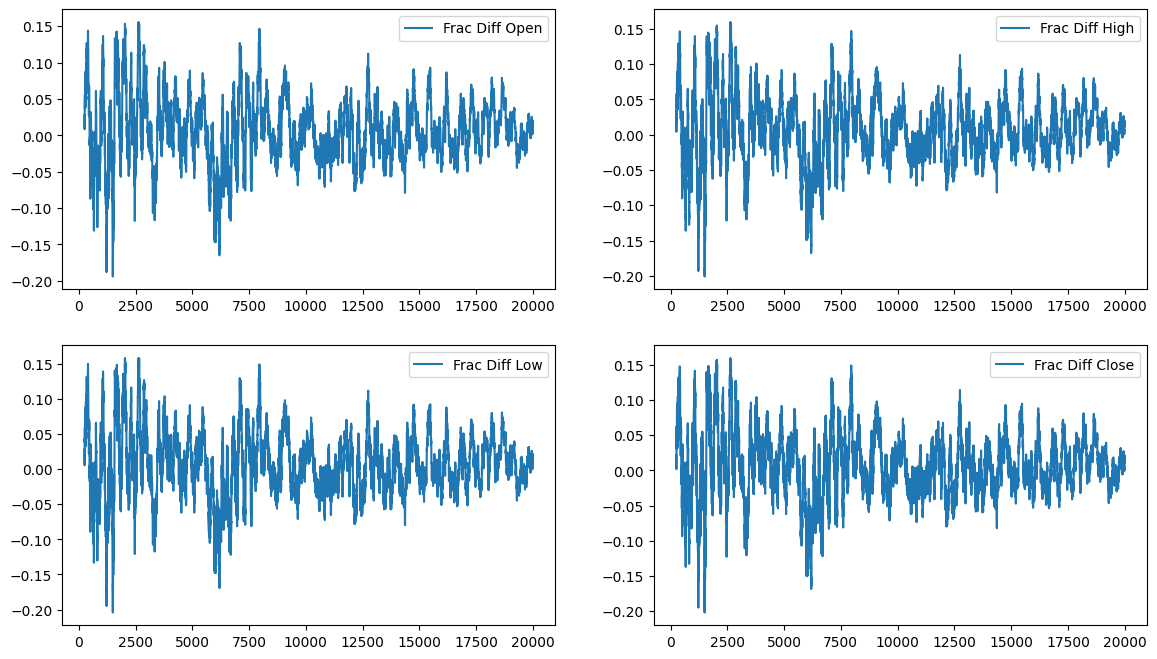

In [15]:
# Plotar gráfico das séries fracionárias
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 8))
plt.subplot(2, 2, 1)
plt.plot(df['frac_open'], label='Frac Diff Open')
plt.legend()
plt.subplot(2, 2, 2)
plt.plot(df['frac_high'], label='Frac Diff High')
plt.legend()
plt.subplot(2, 2, 3)
plt.plot(df['frac_low'], label='Frac Diff Low')
plt.legend()
plt.subplot(2, 2, 4)
plt.plot(df['frac_close'], label='Frac Diff Close')
plt.legend()
plt.show()

# 4. Construção do Alvo Principal: Pavio em Excursão Contrária

Neste bloco é construída a variável central do projeto. A lógica consiste em:

- calcular `mae_h1`, que representa a excursão contrária do Renko corrente;
- deslocar essa informação para o passo seguinte, obtendo `future_mae_h1`, que passa a ser o alvo principal do estudo.

Essa escolha é conceitualmente importante porque desloca o foco da simples previsão direcional para a **magnitude do movimento adverso esperado**. Em termos de análise de risco, `future_mae_h1` funciona como uma variável de interesse operacional: ela informa o tamanho potencial do pavio contrário que pode ser enfrentado em uma decisão de entrada.

Assim, o restante do notebook deve ser lido à luz dessa definição: as transformações, a seleção de features e os backtests buscam compreender e explorar a estrutura estatística de `future_mae_h1`.

In [16]:
df["mae_h1"] = renko_mae_contraria(df, open_col="Open", high_col="High", low_col="Low", close_col="Close")
df["future_mae_h1"] = future_mae(df, horizon=1, excursion_col="mae_h1")

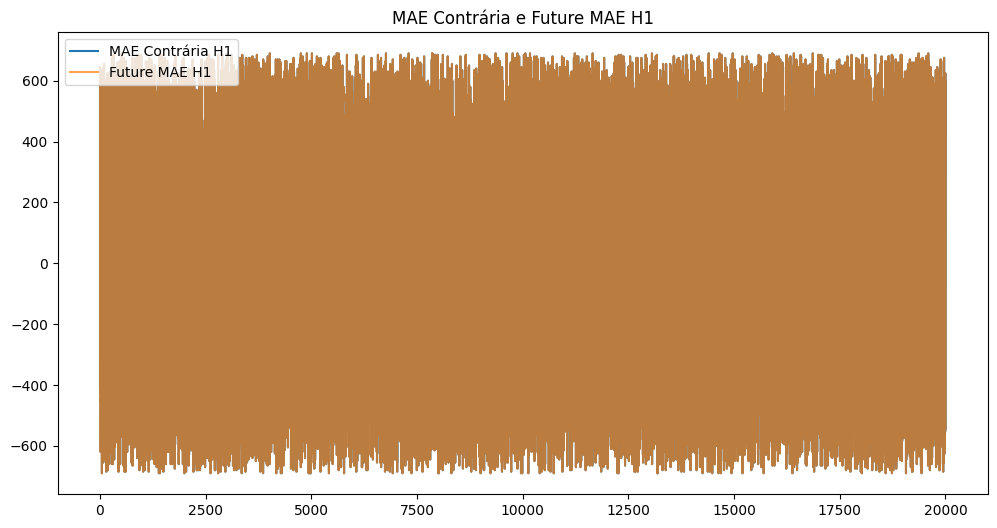

In [17]:
# Plotar gráfico do MAE contrário e do futuro MAE
plt.figure(figsize=(12, 6))
plt.plot(df['mae_h1'], label='MAE Contrária H1')
plt.plot(df['future_mae_h1'], label='Future MAE H1', alpha=0.7)
plt.legend()
plt.title('MAE Contrária e Future MAE H1')
plt.show()

In [18]:
# Diferenciação fracionária do MAE contrário
optimal_d_mae = find_optimal_d(
    df, 
    col='mae_h1', 
    d_range=(0.001, 1.0, 0.01), 
    thresh=1e-5, 
    pvalue_threshold=0.05, 
    max_lags=None, 
    max_size=56, 
    use_log=False, 
    center="rolling", 
    center_window=200, 
    min_n=500
)
print(f"Optimal d for fractional differencing for 'mae_h1': {optimal_d_mae}")

df['frac_mae_h1'] = fracdiff_series(
    df,
    col='mae_h1',
    d=optimal_d_mae,
    thresh=1e-5,
    max_size=56,
    use_log=True,
    center="rolling",
    center_window=200,
    standardize=False
)

Optimal d for fractional differencing for 'mae_h1': 0.001


In [19]:
#df["frac_mae_h1"] = renko_mae_contraria(df, "frac_open", "frac_high", "frac_low", "frac_close")
df["frac_future_mae_h1"] = future_mae(df, horizon=1, excursion_col="frac_mae_h1")

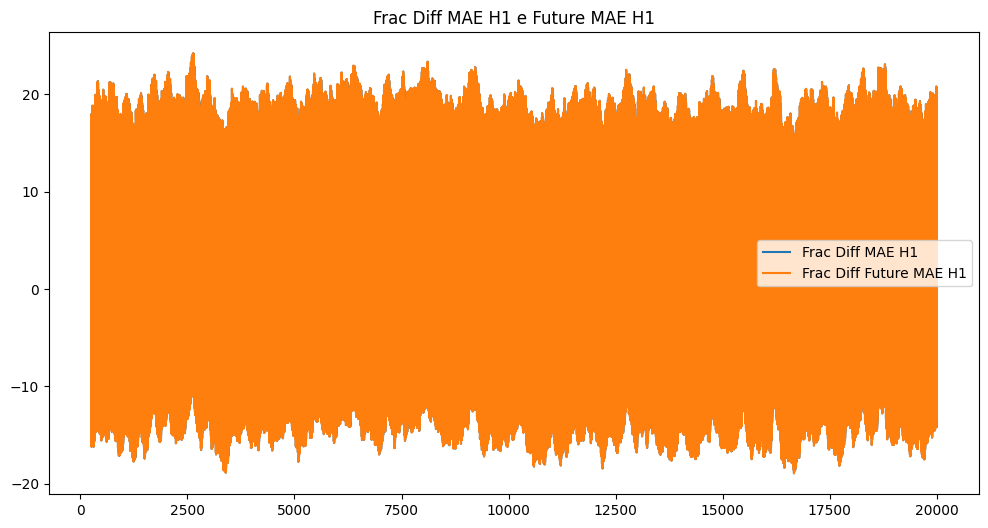

In [20]:
# Plotar gráfico de frac_mae_h1 e frac_future_mae_h1
plt.figure(figsize=(12, 6)) 
plt.plot(df['frac_mae_h1'], label='Frac Diff MAE H1')
plt.plot(df['frac_future_mae_h1'], label='Frac Diff Future MAE H1')
plt.legend()
plt.title('Frac Diff MAE H1 e Future MAE H1')
plt.show()

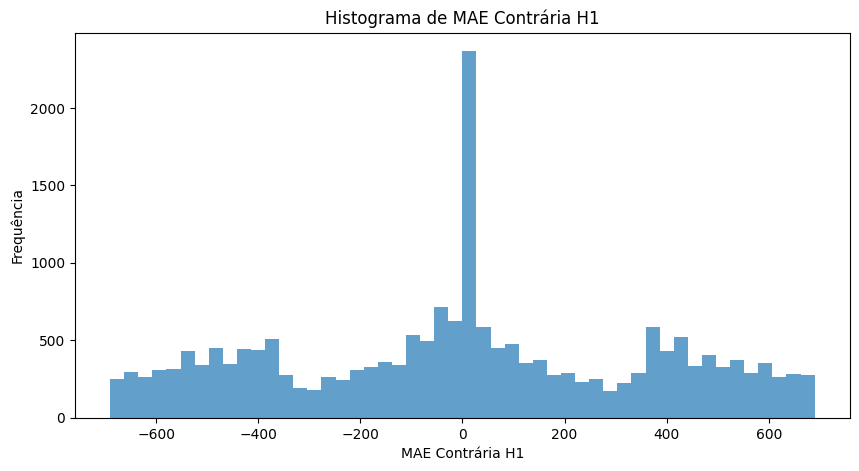

In [21]:
# Histograma de mae_h1
plt.figure(figsize=(10, 5))
plt.hist(df['mae_h1'].dropna(), bins=50, alpha=0.7)
plt.title('Histograma de MAE Contrária H1')
plt.xlabel('MAE Contrária H1')
plt.ylabel('Frequência')
plt.show()

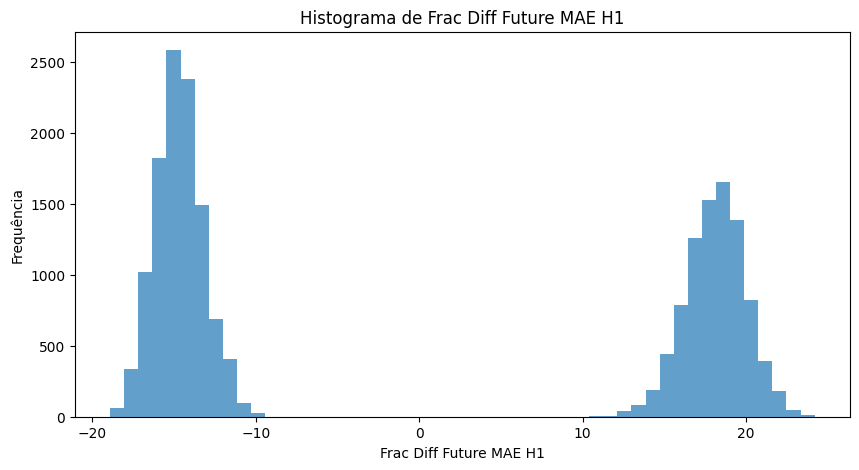

In [22]:
# Plotar histrograma de frac_future_mae_h1
plt.figure(figsize=(10, 5))
plt.hist(df['frac_future_mae_h1'].dropna(), bins=50, alpha=0.7)
plt.title('Histograma de Frac Diff Future MAE H1')
plt.xlabel('Frac Diff Future MAE H1')
plt.ylabel('Frequência')
plt.show()

In [23]:
# Colocar cada conjunto da distribuição bimodal em uma coluna separada

band1 = df['frac_future_mae_h1'].between(-18.89, -9.41)
band2 = df['frac_future_mae_h1'].between(12, 24.75)

df['frac_future_mae_h1_band1'] = df['frac_future_mae_h1'].where(band1)
df['frac_future_mae_h1_band2'] = df['frac_future_mae_h1'].where(band2)

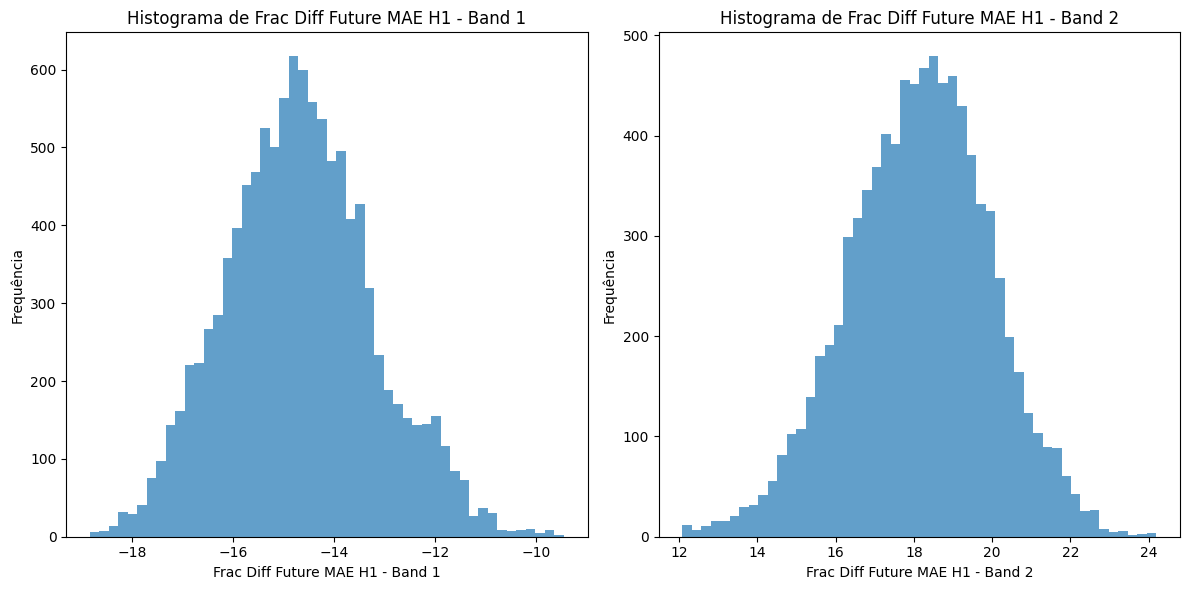

In [24]:
# Plotar os histogramas das bandas separadamente
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(df['frac_future_mae_h1_band1'].dropna(), bins=50, alpha=0.7)
plt.title('Histograma de Frac Diff Future MAE H1 - Band 1')
plt.xlabel('Frac Diff Future MAE H1 - Band 1')
plt.ylabel('Frequência')
plt.subplot(1, 2, 2)
plt.hist(df['frac_future_mae_h1_band2'].dropna(), bins=50, alpha=0.7)
plt.title('Histograma de Frac Diff Future MAE H1 - Band 2')
plt.xlabel('Frac Diff Future MAE H1 - Band 2')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

In [25]:
splitter = TimeSeriesSplit(n_splits=10, gap=4)



df_out, parts = build_train_then_transform_future(
    df,
    train_frac=0.70,
    train_mode="oof",
    purged_splitter=splitter,
    probability_backend="state",
    return_parts=True,
    
    parallel_state_periods=True,
    state_max_workers=4,     # ou None para automático
    estimator_n_jobs=-1,     # para backends supervisionados
    
    add_target=False,
    target_horizon=3,
    target_mixed_value=np.nan,
    target_name="target",
    
    brick_size=345.0,

    close_col="Close",
    open_col="Open",
    datetime_col="Date",
        
    lag_list=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20),
    lag_feature_cols="all",
    lag_exclude_cols=["Open", "High", "Low", "Close", "Date", "direction", "renko_dir", "ma20", "run_direction", 'future_mae_h1', 'frac_future_mae_h1', 'frac_future_mae_h1_band1', 'frac_future_mae_h1_band2'],


    ma_windows=(9, 20, 50, 200),
    dir_windows=(3, 5, 8),

    state_ma_type="sma",
    state_ma_period=(9, 20, 50, 200),   # várias médias
    
    add_state_features=True,
    add_episode_features=True,
    add_interactions=True,
    
    drop_ma_columns=True,
    
    
    state_include_ma_slope_state=True,
    state_ma_slope_lookback=5,
)

C:\Users\Edinho\AppData\Local\Temp\ipykernel_15560\2462288237.py:1030: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col] = np.nan
C:\Users\Edinho\AppData\Local\Temp\ipykernel_15560\2462288237.py:1030: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col] = np.nan
C:\Users\Edinho\AppData\Local\Temp\ipykernel_15560\2462288237.py:1030: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.

In [26]:
# Verificando se há NaNs no meio do dataset
cols_com_nan_no_miolo = []

for col in df_out.columns:
    s = df_out[col]
    first = s.first_valid_index()
    last = s.last_valid_index()
    
    if first is not None and last is not None:
        miolo = s.loc[first:last]
        if miolo.isna().any():
            cols_com_nan_no_miolo.append(col)

print(cols_com_nan_no_miolo)

['frac_future_mae_h1_band1', 'frac_future_mae_h1_band2']


In [27]:
# Preencher os NaNs restantes com 0.0 nas colunas 'frac_future_mae_h1_band1' e 'frac_future_mae_h1_band2'
df_out[['frac_future_mae_h1_band1', 'frac_future_mae_h1_band2']] = df_out[['frac_future_mae_h1_band1', 'frac_future_mae_h1_band2']].fillna(0.0)

In [28]:
print(df_out[['frac_future_mae_h1_band1', 'frac_future_mae_h1_band2']].to_markdown())

|       |   frac_future_mae_h1_band1 |   frac_future_mae_h1_band2 |
|------:|---------------------------:|---------------------------:|
|     0 |                    0       |                     0      |
|     1 |                    0       |                     0      |
|     2 |                    0       |                     0      |
|     3 |                    0       |                     0      |
|     4 |                    0       |                     0      |
|     5 |                    0       |                     0      |
|     6 |                    0       |                     0      |
|     7 |                    0       |                     0      |
|     8 |                    0       |                     0      |
|     9 |                    0       |                     0      |
|    10 |                    0       |                     0      |
|    11 |                    0       |                     0      |
|    12 |                    0       |          

In [29]:
# Dropar  a coluna run_direction pois já há uma coluna que indica direção: dir_1
df_out.drop(columns=['run_direction'], inplace=True)

In [30]:
df_out.dropna(inplace=True)

In [31]:
print(df_out.shape)

(18699, 7683)


In [32]:
# Binarizar algumas variáveis usando bin discretizer do sklearn

features = [
    "above_ma_9",
    "bullish_horizons_ma200",
    "classe_score_ma200",
    "dir_1",
    "dir_atual_h1_ma200",
    "dir_atual_h2_ma200",
    "dir_atual_h2_ma9",
    "dir_atual_h3_ma200",
    "dir_atual_h3_ma9",
    "dir_atual_h5_ma200",
    "dir_atual_h5_ma9",
    "dir_mean_3",
    "dir_sum_3",
    "dir_sum_3_x_abs_dist_ma_20",
    "dist_bricks_ma9",
    "dist_ma_9_bricks",
    "lift_prob_down_h1_ma200",
    "lift_prob_down_h2_ma200",
]

from sklearn.preprocessing import KBinsDiscretizer
kbins = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile")
df_out[["dir_sum_3_x_abs_dist_ma_20_binned", "dist_bricks_ma9_binned", "dist_ma_9_bricks_binned", "lift_prob_down_h1_ma200_binned", "lift_prob_down_h2_ma200_binned"]] = kbins.fit_transform(df_out[["dir_sum_3_x_abs_dist_ma_20", "dist_bricks_ma9", "dist_ma_9_bricks", "lift_prob_down_h1_ma200", "lift_prob_down_h2_ma200"]])
features.append("dir_sum_3_x_abs_dist_ma_20_binned")
features.append("dist_bricks_ma9_binned")
features.append("dist_ma_9_bricks_binned")
features.append("lift_prob_down_h1_ma200_binned")
features.append("lift_prob_down_h2_ma200_binned")

## 5.1 Nota de organização do notebook

O notebook preserva alguns experimentos intermediários para garantir transparência metodológica. Entretanto, a interpretação acadêmica do trabalho deve priorizar:

1. a definição do alvo `future_mae_h1`;
2. a comparação entre representações transformadas do alvo;
3. o impacto dessa comparação na seleção de features;
4. a tradução dos resultados para modelagem e avaliação operacional.

Experimentos laterais ou tentativas que não foram adotadas como solução final permanecem documentados como parte do processo de investigação, mas não devem ser confundidos com a proposta metodológica principal.

# 6. Explorações Metodológicas do Alvo Transformado e Tentativas de Inversão

A seção seguinte reúne experimentos voltados a responder uma questão prática: até que ponto as versões transformadas de `future_mae_h1` podem ser trazidas de volta para a escala original sem perda excessiva de informação?

Esses testes incluem:

- regressões sobre bandas de `frac_future_mae_h1`;
- tentativas de inversão de transformações;
- comparação entre escala transformada e escala original;
- avaliação da utilidade prática das representações transformadas.

No contexto do trabalho, essa parte deve ser lida como uma **exploração metodológica sobre representabilidade**. Seu valor principal não está em estabelecer uma solução definitiva de inversão, mas em demonstrar que diferentes transformações preservam ou destroem diferentes aspectos da informação original — o que, por sua vez, afeta a seleção de features e a interpretação dos resultados.

Há que se registrar que não foram registradas as tentativas de "normalizar" as transformações logarítimicas e de diferenciação fracionária. Essas tentativas foram pífias, algumas até chegaram perto do resultado esperado, mas a um custo computacional elevado que torna impossível a aplicação prática num cenário real que não admite atrasos.

A solução encontrada, ao se constatar que o alvo diferenciado conseguiu performar melhor no teste de regresão, foi trazer à baila aquelas features mais correlacionadas com esse alvo transformado e utilizá-las num modelo de probabilidades condicionais, como se verá mais adiante.

In [33]:
# Diminuir a dimensionalidade usando correlação de Spearman e dropando features altamente correlacionadas (threshold=0.9). Essas features reduzidas serão utilizadas no treinamento abaixo

df_reduzido, cols_excluidas, relatorio, corr = drop_high_spearman_features(
    df_out[features],
    threshold=0.9,
    exclude_cols=None,   # se quiser preservar alguma coluna
    use_abs=True,
    verbose=True
)

Threshold de correlação de Spearman: 0.9
Total de colunas numéricas avaliadas: 23
Total de colunas excluídas: 18

Colunas excluídas:
 - classe_score_ma200
 - dir_1
 - dir_atual_h1_ma200
 - dir_atual_h2_ma200
 - dir_atual_h2_ma9
 - dir_atual_h3_ma200
 - dir_atual_h3_ma9
 - dir_atual_h5_ma200
 - dir_atual_h5_ma9
 - dir_mean_3
 - dir_sum_3
 - dir_sum_3_x_abs_dist_ma_20
 - dist_bricks_ma9
 - dist_bricks_ma9_binned
 - dist_ma_9_bricks
 - lift_prob_down_h1_ma200
 - lift_prob_down_h2_ma200
 - lift_prob_down_h2_ma200_binned

Detalhamento das exclusões:
                  feature_excluida                    feature_mantida  \
15          dist_bricks_ma9_binned            dist_ma_9_bricks_binned   
9                       dir_mean_3                          dir_sum_3   
16         lift_prob_down_h1_ma200     lift_prob_down_h1_ma200_binned   
14      dir_sum_3_x_abs_dist_ma_20  dir_sum_3_x_abs_dist_ma_20_binned   
13         lift_prob_down_h2_ma200            lift_prob_down_h1_ma200   
2          

In [34]:
# Lista das features finais após redução por correlação de Spearman
print(df_reduzido.columns.tolist())

['above_ma_9', 'bullish_horizons_ma200', 'dir_sum_3_x_abs_dist_ma_20_binned', 'dist_ma_9_bricks_binned', 'lift_prob_down_h1_ma200_binned']


## TESTE DE REGRESSÃO COM UM ALVO COM TRANSFORMAÇÃO LOGARÍTMICA E FRACIONÁRIA E COM UM ALVO SEM TRANSFORMAÇÃO ALGUMA


########################################################################################################################
OTIMIZANDO COM OPTUNA + TIME SERIES CV: frac_future_mae_h1
########################################################################################################################

Target: frac_future_mae_h1
Shape final do dataframe: (18699, 7688)
Quantidade de features: 59
Development (CV): (15894, 7688)
Teste           : (2805, 7688)



  0%|          | 0/150 [00:00<?, ?it/s]


MELHOR CONFIGURAÇÃO CV - frac_future_mae_h1
{
    "TARGET_COL": "frac_future_mae_h1",
    "USE_LOG_TARGET": false,
    "USE_SAMPLE_WEIGHTS": true,
    "WEIGHT_BY_ABS_TARGET": true,
    "N_SPLITS": 5,
    "CV_GAP": 5,
    "OPTUNA_N_JOBS": 4,
    "LGBM_N_JOBS": 2,
    "EXTREME_Q25_WEIGHT": 2.00251709441939,
    "EXTREME_Q50_WEIGHT": 2.0955645600385977,
    "N_ESTIMATORS": 483,
    "LEARNING_RATE": 0.005530356477666254,
    "NUM_LEAVES": 240,
    "MAX_DEPTH": 8,
    "MIN_CHILD_SAMPLES": 45,
    "MIN_CHILD_WEIGHT": 0.0480282830162752,
    "SUBSAMPLE": 0.6168925553567574,
    "SUBSAMPLE_FREQ": 3,
    "COLSAMPLE_BYTREE": 0.8364017149296498,
    "REG_ALPHA": 1.807768789438918,
    "REG_LAMBDA": 6.085736133231617e-07,
    "MIN_SPLIT_GAIN": 1.7040952550537185,
    "MAX_BIN": 399,
    "VERBOSITY": -1
}

Tabela dos folds da melhor configuração:
 fold        r2       mae      rmse  best_iteration
    1  0.006127 15.996367 16.246849             106
    2 -0.001294 16.005781 16.316611             2

  0%|          | 0/150 [00:00<?, ?it/s]


MELHOR CONFIGURAÇÃO CV - future_mae_h1
{
    "TARGET_COL": "future_mae_h1",
    "USE_LOG_TARGET": false,
    "USE_SAMPLE_WEIGHTS": true,
    "WEIGHT_BY_ABS_TARGET": true,
    "N_SPLITS": 5,
    "CV_GAP": 5,
    "OPTUNA_N_JOBS": 4,
    "LGBM_N_JOBS": 2,
    "EXTREME_Q25_WEIGHT": 2.663346404943333,
    "EXTREME_Q50_WEIGHT": 2.8107297223403114,
    "N_ESTIMATORS": 23,
    "LEARNING_RATE": 0.017747095560192744,
    "NUM_LEAVES": 194,
    "MAX_DEPTH": 3,
    "MIN_CHILD_SAMPLES": 94,
    "MIN_CHILD_WEIGHT": 0.0019656335896671645,
    "SUBSAMPLE": 0.5132757724901271,
    "SUBSAMPLE_FREQ": 7,
    "COLSAMPLE_BYTREE": 0.5624137952762474,
    "REG_ALPHA": 0.004672760519180869,
    "REG_LAMBDA": 5.527391918106945e-07,
    "MIN_SPLIT_GAIN": 0.9203801319905316,
    "MAX_BIN": 142,
    "VERBOSITY": -1
}

Tabela dos folds da melhor configuração:
 fold       r2        mae       rmse  best_iteration
    1 0.001819 278.461359 350.967211              49
    2 0.001168 292.610562 364.369751              2

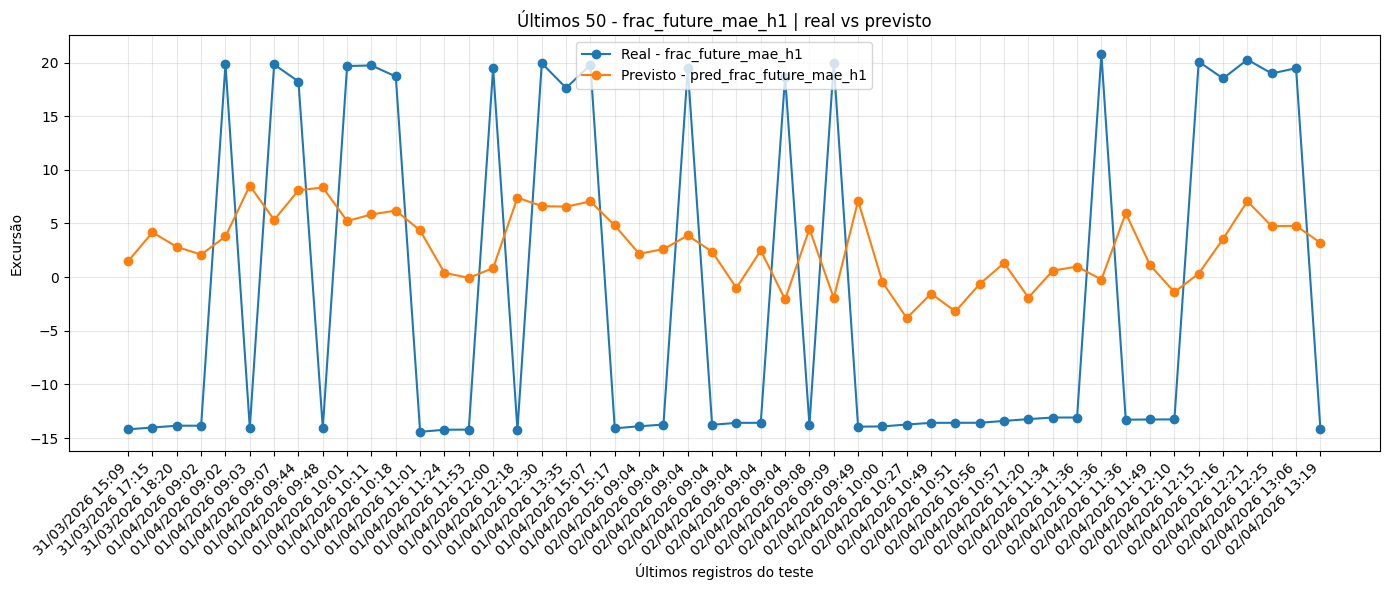


BEST_CONFIG_FUTURE_MAE_H1 =
{
    "TARGET_COL": "future_mae_h1",
    "USE_LOG_TARGET": false,
    "USE_SAMPLE_WEIGHTS": true,
    "WEIGHT_BY_ABS_TARGET": true,
    "N_SPLITS": 5,
    "CV_GAP": 5,
    "OPTUNA_N_JOBS": 4,
    "LGBM_N_JOBS": 2,
    "EXTREME_Q25_WEIGHT": 2.663346404943333,
    "EXTREME_Q50_WEIGHT": 2.8107297223403114,
    "N_ESTIMATORS": 23,
    "LEARNING_RATE": 0.017747095560192744,
    "NUM_LEAVES": 194,
    "MAX_DEPTH": 3,
    "MIN_CHILD_SAMPLES": 94,
    "MIN_CHILD_WEIGHT": 0.0019656335896671645,
    "SUBSAMPLE": 0.5132757724901271,
    "SUBSAMPLE_FREQ": 7,
    "COLSAMPLE_BYTREE": 0.5624137952762474,
    "REG_ALPHA": 0.004672760519180869,
    "REG_LAMBDA": 5.527391918106945e-07,
    "MIN_SPLIT_GAIN": 0.9203801319905316,
    "MAX_BIN": 142,
    "VERBOSITY": -1
}

TOP_SHAP_FUTURE_MAE_H1 =
                                           feature  mean_abs_shap
      pos_rate_since_cross_above_ma_200_x_abs_dist       3.485770
pos_rate_since_cross_above_ma_200_x_abs_dist_lag_5  

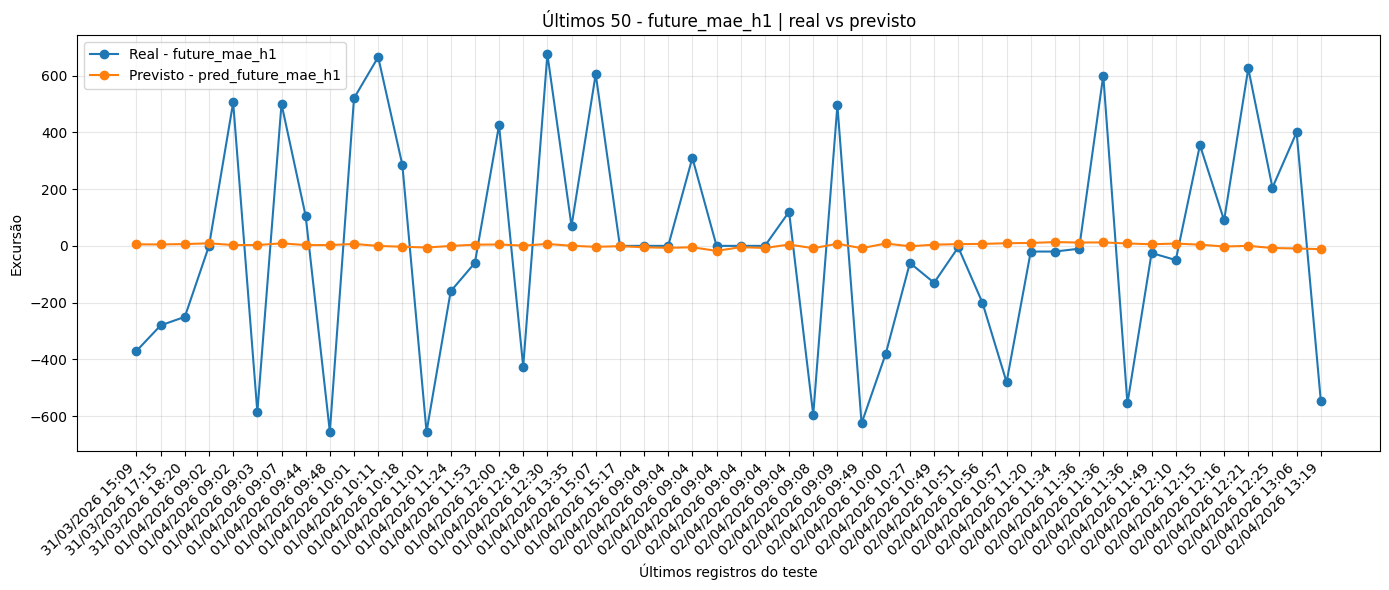

In [35]:
import json
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import optuna

from numba import njit
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)


# Criando alvo
#df_out["future_mae_h1"] = future_mae(df_out, horizon=1, excursion_col="mae_h1")

# Features
features = [
"dist_ma_200_z",
"dist_bricks_ma200",
"dist_ma_200_bricks",
"pos_rate_since_cross_above_ma_200_x_abs_dist",
"dir_balance_since_cross_above_ma_200",
"neg_rate_since_cross_above_ma_200_x_abs_dist",
"dist_bricks_ma200_lag_1",
"dir_balance_since_cross_above_ma_200_lag_1",
"dist_ma_200_z_lag_1",
"dist_ma_200_bricks_lag_1",
"pos_rate_since_cross_above_ma_200_x_abs_dist_lag_1",
"dir_balance_since_cross_above_ma_200_lag_2",
"dir_balance_since_cross_above_ma_200_x_dist",
"dir_balance_since_cross_above_ma_200_lag_3",
"frac_close",
"dist_bricks_ma200_lag_2",
"dir_balance_since_cross_above_ma_200_lag_4",
"dir_balance_since_cross_above_ma_200_lag_5",
"pos_rate_since_cross_above_ma_200_x_abs_dist_lag_2",
"neg_rate_since_cross_above_ma_200_x_abs_dist_lag_1",
"dir_balance_since_cross_above_ma_200_lag_6",
"dist_ma_200_bricks_lag_2",
"dist_ma_200_z_lag_2",
"dir_balance_since_cross_above_ma_200_lag_7",
"dist_bricks_ma200_lag_3",
"pos_rate_since_cross_above_ma_200_x_abs_dist_lag_3",
"dir_balance_since_cross_above_ma_200_lag_8",
"dist_bricks_ma200_lag_4",
"pos_rate_since_cross_above_ma_200_x_abs_dist_lag_4",
"dist_ma_200_bricks_lag_3",
"pos_rate_since_cross_above_ma_200_x_abs_dist_lag_5",
"dir_balance_since_cross_above_ma_200_lag_9",
"dist_ma_200_z_lag_3",
"dist_bricks_ma200_lag_5",
"pos_rate_since_cross_above_ma_200_x_abs_dist_lag_6",
"neg_rate_since_cross_above_ma_200_x_abs_dist_lag_2",
"pos_rate_since_cross_above_ma_200_x_abs_dist_lag_7",
"dir_balance_since_cross_above_ma_200_x_dist_lag_1",
"dist_ma_200_bricks_lag_4",
"dist_bricks_ma200_lag_6",
"dir_balance_since_cross_above_ma_200_lag_10",
"dist_ma_200_z_lag_4",
"neg_rate_since_cross_above_ma_200_x_abs_dist_lag_3",
"dist_ma_200_bricks_lag_5",
"dist_bricks_ma200_lag_7",
"neg_rate_since_cross_above_ma_200_x_abs_dist_lag_4",
"pos_rate_since_cross_above_ma_200_x_abs_dist_lag_8",
"dir_balance_since_cross_above_ma_200_lag_15",
"neg_rate_since_cross_above_ma_200_x_abs_dist_lag_10",
"neg_rate_since_cross_above_ma_200_x_abs_dist_lag_8",
"neg_rate_since_cross_above_ma_200_x_abs_dist_lag_9",
"neg_rate_since_cross_above_ma_200_x_abs_dist_lag_5",
"neg_rate_since_cross_above_ma_200_x_abs_dist_lag_7",
"neg_rate_since_cross_above_ma_200_x_abs_dist_lag_6",
"pos_rate_since_cross_above_ma_200_x_abs_dist_lag_9",
"pos_rate_since_cross_above_ma_200_x_abs_dist_lag_10",
"dist_ma_200_z_lag_5",
"dir_balance_since_cross_above_ma_200_x_dist_lag_2",
"dist_ma_200_z_lag_6",
]

# =========================================================
# CONFIG
# =========================================================
USE_ALL_FEATURES = False

# IMPORTANTE:
# Como o target mae_h1 agora pode ser negativo e positivo,
# o log1p pode gerar NaN para valores < -1.
# Portanto, por padrão, deixe False.
USE_LOG_TARGET = False

# Pesos opcionais:
# Primeiro rode sem pesos. Depois, se quiser, mude para True.
USE_SAMPLE_WEIGHTS = True

# Se usar pesos, pondera extremos pelo módulo do target (abs),
# o que faz mais sentido para target assinado.
WEIGHT_BY_ABS_TARGET = True

LAST_N_TO_COMPARE = 50
SHAP_TOP_N = 10
SHAP_MAX_SAMPLES = 3000
SHAP_ON = "test"   # "dev" ou "test"

N_SPLITS = 5
CV_GAP = 5
N_TRIALS = 150
OPTUNA_TIMEOUT = None
RANDOM_STATE = 42

# paralelismo
OPTUNA_N_JOBS = 4
LGBM_N_JOBS = 2


TARGET_COLS = ["frac_future_mae_h1", "future_mae_h1"]
DROP_COLS = ["Date", "Open", "High", "Low", "Close"] + TARGET_COLS


# =========================================================
# PREP
# =========================================================
if USE_ALL_FEATURES:
    feature_cols = [col for col in df_out.columns if col not in DROP_COLS]
else:
    feature_cols = [col for col in features if col in df_out.columns and col not in DROP_COLS]
    

def build_model_frames_for_target(df_source, target_col, feature_cols):
    required_cols = [target_col]

    if "Date" in df_source.columns:
        required_cols.append("Date")
    if "Close" in df_source.columns:
        required_cols.append("Close")

    required_cols = list(dict.fromkeys(required_cols + feature_cols))

    df_model = df_source.dropna(subset=required_cols).reset_index(drop=True).copy()

    if "Date" in df_model.columns:
        df_model["Date"] = pd.to_datetime(df_model["Date"], errors="coerce")

    if len(df_model) == 0:
        missing_info = df_source[required_cols].isna().sum().sort_values(ascending=False)
        raise ValueError(
            f"Após dropna para o target '{target_col}', o dataframe ficou vazio.\n\n"
            f"Top colunas com NaN:\n{missing_info.head(20)}"
        )

    devel_end = int(len(df_model) * 0.85)
    dev_df = df_model.iloc[:devel_end].reset_index(drop=True).copy()
    test_df = df_model.iloc[devel_end:].reset_index(drop=True).copy()

    print(f"\nTarget: {target_col}")
    print("Shape final do dataframe:", df_model.shape)
    print("Quantidade de features:", len(feature_cols))
    print("Development (CV):", dev_df.shape)
    print("Teste           :", test_df.shape)
    print()

    return df_model, dev_df, test_df


# =========================================================
# UTILS NUMPY / NUMBA
# =========================================================
def inverse_target_transform(y, use_log_target=True):
    y = np.asarray(y, dtype=np.float64)
    if use_log_target:
        y = np.expm1(y)
    return y


@njit(cache=True)
def build_weights_numba(target_to_weight, q25, q50, q25_weight, q50_weight):
    n = target_to_weight.shape[0]
    out = np.empty(n, dtype=np.float32)

    for i in range(n):
        v = target_to_weight[i]

        # threshold maior recebe peso maior
        if v >= q50:
            out[i] = q50_weight
        elif v >= q25:
            out[i] = q25_weight
        else:
            out[i] = 1.0

    return out


def build_extreme_weights_from_train_fast(
    train_target,
    other_target=None,
    q25_weight=2.0,
    q50_weight=5.0,
    weight_by_abs_target=True,
):
    train_target = np.asarray(train_target, dtype=np.float32)
    target_to_weight = train_target if other_target is None else np.asarray(other_target, dtype=np.float32)

    base_train = np.abs(train_target) if weight_by_abs_target else train_target
    base_other = np.abs(target_to_weight) if weight_by_abs_target else target_to_weight

    q25 = float(np.quantile(base_train, 0.25))
    q50 = float(np.quantile(base_train, 0.50))

    weights = build_weights_numba(
        base_other.astype(np.float32),
        np.float32(q25),
        np.float32(q50),
        np.float32(q25_weight),
        np.float32(q50_weight),
    )

    return weights, q25, q50


def prepare_numpy_data(df_in, feature_cols, target_col, use_log_target=False):
    X = np.ascontiguousarray(df_in[feature_cols].to_numpy(dtype=np.float32))
    y_raw = np.ascontiguousarray(df_in[target_col].to_numpy(dtype=np.float32))

    if np.isnan(y_raw).any():
        bad_idx = np.where(np.isnan(y_raw))[0][:10]
        raise ValueError(f"{target_col}: y_raw contém NaN. Exemplos de índices: {bad_idx}")

    if use_log_target:
        if np.any(y_raw <= -1.0):
            bad_vals = y_raw[y_raw <= -1.0][:10]
            raise ValueError(
                f"{target_col}: USE_LOG_TARGET=True é incompatível com valores <= -1. "
                f"Exemplos: {bad_vals}"
            )
        y_trans = np.log1p(y_raw)
    else:
        y_trans = y_raw.copy()

    if np.isnan(y_trans).any():
        bad_idx = np.where(np.isnan(y_trans))[0][:10]
        raise ValueError(f"{target_col}: y transformado contém NaN. Exemplos de índices: {bad_idx}")

    return X, y_raw, y_trans


# =========================================================
# DATA CLASS
# =========================================================
@dataclass
class FoldMetrics:
    fold: int
    r2: float
    mae: float
    rmse: float
    best_iteration: int


# =========================================================
# OPTUNA SEARCH SPACE
# =========================================================
def get_optuna_search_space(trial, use_sample_weights=False):
    params = {
        "objective": "regression",
        "boosting_type": "gbdt",
        "n_estimators": trial.suggest_int("n_estimators", 500, 5000),
        "learning_rate": trial.suggest_float("learning_rate", 0.003, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 255),
        "max_depth": trial.suggest_categorical("max_depth", [-1, 3, 4, 5, 6, 7, 8, 10, 12]),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 120),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-4, 50.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.50, 1.00),
        "subsample_freq": trial.suggest_int("subsample_freq", 0, 7),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.50, 1.00),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 50.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 50.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 2.0),
        "max_bin": trial.suggest_int("max_bin", 63, 511),
        "random_state": RANDOM_STATE,
        "n_jobs": LGBM_N_JOBS,
        "verbosity": -1,
    }

    if use_sample_weights:
        weights_cfg = {
            "q25_weight": trial.suggest_float("q25_weight", 2.0, 3.0),
            "q50_weight": trial.suggest_float("q50_weight", 2.0, 5.0),
        }

        # só garante que o threshold maior não tenha peso menor
        weights_cfg["q50_weight"] = max(weights_cfg["q50_weight"], weights_cfg["q25_weight"])
    else:
        weights_cfg = {
            "q25_weight": 1.0,
            "q50_weight": 1.0,
        }

    return params, weights_cfg


# =========================================================
# CV FAST
# =========================================================
def run_cv_for_params_fast(
    X,
    y_raw,
    y_trans,
    splits,
    params,
    weights_cfg,
    use_log_target=False,
    use_sample_weights=False,
    weight_by_abs_target=True,
):
    fold_metrics = []

    for fold_idx, (tr_idx, va_idx) in enumerate(splits, start=1):
        X_tr = X[tr_idx]
        X_va = X[va_idx]

        y_tr_raw = y_raw[tr_idx]
        y_va_raw = y_raw[va_idx]

        y_tr = y_trans[tr_idx] if use_log_target else y_tr_raw
        y_va = y_trans[va_idx] if use_log_target else y_va_raw

        if np.isnan(y_tr).any():
            raise ValueError(f"Fold {fold_idx}: y_tr contém NaN.")
        if np.isnan(y_va).any():
            raise ValueError(f"Fold {fold_idx}: y_va contém NaN.")

        model = LGBMRegressor(**params)

        if use_sample_weights:
            w_tr, _, _ = build_extreme_weights_from_train_fast(
                y_tr_raw,
                ##q75_weight=weights_cfg["q75_weight"],
                #q90_weight=weights_cfg["q90_weight"],
                #q97_weight=weights_cfg["q97_weight"],
                q25_weight=weights_cfg["q25_weight"],
                q50_weight=weights_cfg["q50_weight"],
                weight_by_abs_target=weight_by_abs_target,
            )

            w_va, _, _ = build_extreme_weights_from_train_fast(
            y_tr_raw,
            other_target=y_va_raw,
            q25_weight=weights_cfg["q25_weight"],
            q50_weight=weights_cfg["q50_weight"],
            weight_by_abs_target=weight_by_abs_target,
        )

            model.fit(
                X_tr,
                y_tr,
                sample_weight=w_tr,
                eval_set=[(X_va, y_va)],
                eval_sample_weight=[w_va],
                eval_metric="rmse",
                callbacks=[
                    early_stopping(stopping_rounds=200, verbose=False),
                    log_evaluation(period=0),
                ],
            )
        else:
            model.fit(
                X_tr,
                y_tr,
                eval_set=[(X_va, y_va)],
                eval_metric="rmse",
                callbacks=[
                    early_stopping(stopping_rounds=200, verbose=False),
                    log_evaluation(period=0),
                ],
            )

        pred_va = inverse_target_transform(
            model.predict(X_va),
            use_log_target=use_log_target
        )
        y_va_real = inverse_target_transform(
            y_va,
            use_log_target=use_log_target
        )

        fold_metrics.append(
            FoldMetrics(
                fold=fold_idx,
                r2=float(r2_score(y_va_real, pred_va)),
                mae=float(mean_absolute_error(y_va_real, pred_va)),
                rmse=float(np.sqrt(mean_squared_error(y_va_real, pred_va))),
                best_iteration=int(getattr(model, "best_iteration_", params["n_estimators"])),
            )
        )

    return fold_metrics


def summarize_cv_metrics(fold_metrics):
    r2s = np.array([fm.r2 for fm in fold_metrics], dtype=np.float64)
    maes = np.array([fm.mae for fm in fold_metrics], dtype=np.float64)
    rmses = np.array([fm.rmse for fm in fold_metrics], dtype=np.float64)
    best_iters = np.array([fm.best_iteration for fm in fold_metrics], dtype=np.int32)

    fold_table = pd.DataFrame([fm.__dict__ for fm in fold_metrics])

    return {
        "mean_r2": float(r2s.mean()),
        "std_r2": float(r2s.std(ddof=1)) if len(r2s) > 1 else 0.0,
        "mean_mae": float(maes.mean()),
        "mean_rmse": float(rmses.mean()),
        "median_best_iteration": int(np.median(best_iters)),
        "fold_table": fold_table,
    }


# =========================================================
# SHAP
# =========================================================
def get_top_features_via_shap_regressor(model, X_explain, feature_names, top_n=10, max_samples=3000):
    if len(X_explain) > max_samples:
        rng = np.random.default_rng(RANDOM_STATE)
        idx = rng.choice(len(X_explain), size=max_samples, replace=False)
        X_used = X_explain[idx]
    else:
        X_used = X_explain

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_used)
    shap_arr = np.asarray(shap_values)

    if shap_arr.ndim != 2:
        raise ValueError(f"Formato inesperado de shap_values em regressão: {shap_arr.shape}")

    mean_abs_shap = np.abs(shap_arr).mean(axis=0)

    shap_importance_df = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    return shap_importance_df.head(top_n)


# =========================================================
# OPTIMIZER
# =========================================================
def optimize_lgbm_with_optuna_cv_fast(
    X_dev,
    y_dev_raw,
    y_dev_trans,
    splits,
    target_col,
    n_trials=80,
    timeout=None,
    use_log_target=False,
    use_sample_weights=False,
    weight_by_abs_target=True,
):
    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=10)

    study = optuna.create_study(
        direction="maximize",
        sampler=sampler,
        pruner=pruner
    )

    def objective(trial):
        params, weights_cfg = get_optuna_search_space(
            trial,
            use_sample_weights=use_sample_weights
        )

        fold_metrics = run_cv_for_params_fast(
            X=X_dev,
            y_raw=y_dev_raw,
            y_trans=y_dev_trans,
            splits=splits,
            params=params,
            weights_cfg=weights_cfg,
            use_log_target=use_log_target,
            use_sample_weights=use_sample_weights,
            weight_by_abs_target=weight_by_abs_target,
        )
        summary = summarize_cv_metrics(fold_metrics)

        trial.set_user_attr("mean_r2", summary["mean_r2"])
        trial.set_user_attr("std_r2", summary["std_r2"])
        trial.set_user_attr("median_best_iteration", summary["median_best_iteration"])

        return summary["mean_r2"]

    study.optimize(
        objective,
        n_trials=n_trials,
        timeout=timeout,
        n_jobs=OPTUNA_N_JOBS,
        show_progress_bar=True,
    )

    best_params_raw = study.best_params.copy()

    if use_sample_weights:
        best_weights_cfg = {
            #"q75_weight": float(best_params_raw.pop("q75_weight")),
            #"q90_weight": float(best_params_raw.pop("q90_weight")),
            #"q97_weight": float(best_params_raw.pop("q97_weight")),
            "q25_weight": float(best_params_raw.pop("q25_weight")),
            "q50_weight": float(best_params_raw.pop("q50_weight")),
        }
    else:
        best_weights_cfg = {
            #"q75_weight": 1.0,
            #"q90_weight": 1.0,
            #"q97_weight": 1.0,
            "q25_weight": 1.0,
            "q50_weight": 1.0,
        }

    best_model_params = {
        "objective": "regression",
        "boosting_type": "gbdt",
        "random_state": RANDOM_STATE,
        "n_jobs": LGBM_N_JOBS,
        "verbosity": -1,
        **best_params_raw,
    }

    best_fold_metrics = run_cv_for_params_fast(
        X=X_dev,
        y_raw=y_dev_raw,
        y_trans=y_dev_trans,
        splits=splits,
        params=best_model_params,
        weights_cfg=best_weights_cfg,
        use_log_target=use_log_target,
        use_sample_weights=use_sample_weights,
        weight_by_abs_target=weight_by_abs_target,
    )

    best_summary = summarize_cv_metrics(best_fold_metrics)

    final_training_config = {
        "TARGET_COL": target_col,
        "USE_LOG_TARGET": use_log_target,
        "USE_SAMPLE_WEIGHTS": use_sample_weights,
        "WEIGHT_BY_ABS_TARGET": weight_by_abs_target,
        "N_SPLITS": N_SPLITS,
        "CV_GAP": CV_GAP,
        "OPTUNA_N_JOBS": OPTUNA_N_JOBS,
        "LGBM_N_JOBS": LGBM_N_JOBS,
        #"EXTREME_Q75_WEIGHT": float(best_weights_cfg["q75_weight"]),
        #"EXTREME_Q90_WEIGHT": float(best_weights_cfg["q90_weight"]),
        #"EXTREME_Q97_WEIGHT": float(best_weights_cfg["q97_weight"]),
        "EXTREME_Q25_WEIGHT": float(best_weights_cfg["q25_weight"]),
        "EXTREME_Q50_WEIGHT": float(best_weights_cfg["q50_weight"]),
        "N_ESTIMATORS": int(best_summary["median_best_iteration"]),
        "LEARNING_RATE": float(best_model_params["learning_rate"]),
        "NUM_LEAVES": int(best_model_params["num_leaves"]),
        "MAX_DEPTH": int(best_model_params["max_depth"]),
        "MIN_CHILD_SAMPLES": int(best_model_params["min_child_samples"]),
        "MIN_CHILD_WEIGHT": float(best_model_params["min_child_weight"]),
        "SUBSAMPLE": float(best_model_params["subsample"]),
        "SUBSAMPLE_FREQ": int(best_model_params["subsample_freq"]),
        "COLSAMPLE_BYTREE": float(best_model_params["colsample_bytree"]),
        "REG_ALPHA": float(best_model_params["reg_alpha"]),
        "REG_LAMBDA": float(best_model_params["reg_lambda"]),
        "MIN_SPLIT_GAIN": float(best_model_params["min_split_gain"]),
        "MAX_BIN": int(best_model_params["max_bin"]),
        "VERBOSITY": -1,
    }

    return {
        "study": study,
        "best_model_params": best_model_params,
        "best_weights_cfg": best_weights_cfg,
        "best_summary": best_summary,
        "best_fold_table": best_summary["fold_table"],
        "final_training_config": final_training_config,
    }


# =========================================================
# FINAL FIT
# =========================================================
def fit_final_model_from_config_fast(
    X_dev,
    y_dev_raw,
    y_dev_trans,
    X_test,
    y_test_raw,
    training_config
):
    y_dev = y_dev_trans if training_config["USE_LOG_TARGET"] else y_dev_raw
    y_test = np.log1p(y_test_raw) if training_config["USE_LOG_TARGET"] else y_test_raw.copy()

    model = LGBMRegressor(
        objective="regression",
        boosting_type="gbdt",
        n_estimators=training_config["N_ESTIMATORS"],
        learning_rate=training_config["LEARNING_RATE"],
        num_leaves=training_config["NUM_LEAVES"],
        max_depth=training_config["MAX_DEPTH"],
        min_child_samples=training_config["MIN_CHILD_SAMPLES"],
        min_child_weight=training_config["MIN_CHILD_WEIGHT"],
        subsample=training_config["SUBSAMPLE"],
        subsample_freq=training_config["SUBSAMPLE_FREQ"],
        colsample_bytree=training_config["COLSAMPLE_BYTREE"],
        reg_alpha=training_config["REG_ALPHA"],
        reg_lambda=training_config["REG_LAMBDA"],
        min_split_gain=training_config["MIN_SPLIT_GAIN"],
        max_bin=training_config["MAX_BIN"],
        random_state=RANDOM_STATE,
        n_jobs=LGBM_N_JOBS,
        verbosity=-1,
    )

    if training_config["USE_SAMPLE_WEIGHTS"]:
        dev_weights, _, _ = build_extreme_weights_from_train_fast(
        y_dev_raw,
        q25_weight=training_config["EXTREME_Q25_WEIGHT"],
        q50_weight=training_config["EXTREME_Q50_WEIGHT"],
        weight_by_abs_target=training_config["WEIGHT_BY_ABS_TARGET"],
    )
        model.fit(X_dev, y_dev, sample_weight=dev_weights)
    else:
        model.fit(X_dev, y_dev)

    pred_test = inverse_target_transform(
        model.predict(X_test),
        use_log_target=training_config["USE_LOG_TARGET"]
    )
    y_test_real = inverse_target_transform(
        y_test,
        use_log_target=training_config["USE_LOG_TARGET"]
    )

    results_test = {
        "mae": float(mean_absolute_error(y_test_real, pred_test)),
        "rmse": float(np.sqrt(mean_squared_error(y_test_real, pred_test))),
        "r2": float(r2_score(y_test_real, pred_test)),
        "y_real": y_test_real,
        "y_pred": pred_test,
    }

    return model, results_test


# =========================================================
# PLOT
# =========================================================
def plot_last_n_predictions(df_compare, actual_col, pred_col, title):
    plt.figure(figsize=(14, 6))
    x = np.arange(len(df_compare))
    plt.plot(x, df_compare[actual_col].values, marker="o", label=f"Real - {actual_col}")
    plt.plot(x, df_compare[pred_col].values, marker="o", label=f"Previsto - {pred_col}")

    if "Date" in df_compare.columns:
        date_series = pd.to_datetime(df_compare["Date"], errors="coerce")
        labels = [
            d.strftime("%d/%m/%Y %H:%M") if pd.notna(d) else str(idx)
            for d, idx in zip(date_series, df_compare.index)
        ]
    else:
        labels = [str(idx) for idx in df_compare.index]

    plt.xticks(x, labels, rotation=45, ha="right")
    plt.title(title)
    plt.xlabel("Últimos registros do teste")
    plt.ylabel("Excursão")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# PIPELINE POR TARGET
# =========================================================
def run_pipeline_for_target(target_col):
    print("\n" + "#" * 120)
    print(f"OTIMIZANDO COM OPTUNA + TIME SERIES CV: {target_col}")
    print("#" * 120)

    df_model, dev_df, test_df = build_model_frames_for_target(
        df_source=df_out,
        target_col=target_col,
        feature_cols=feature_cols
    )

    X_dev, y_dev_raw, y_dev_trans = prepare_numpy_data(
        dev_df,
        feature_cols,
        target_col,
        use_log_target=USE_LOG_TARGET
    )
    X_test, y_test_raw, _ = prepare_numpy_data(
        test_df,
        feature_cols,
        target_col,
        use_log_target=USE_LOG_TARGET
    )

    if len(X_dev) == 0:
        raise ValueError(f"X_dev ficou vazio para o target '{target_col}'.")
    if len(X_test) == 0:
        raise ValueError(f"X_test ficou vazio para o target '{target_col}'.")

    tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=CV_GAP)
    splits = list(tscv.split(X_dev))

    opt_res = optimize_lgbm_with_optuna_cv_fast(
        X_dev=X_dev,
        y_dev_raw=y_dev_raw,
        y_dev_trans=y_dev_trans,
        splits=splits,
        target_col=target_col,
        n_trials=N_TRIALS,
        timeout=OPTUNA_TIMEOUT,
        use_log_target=USE_LOG_TARGET,
        use_sample_weights=USE_SAMPLE_WEIGHTS,
        weight_by_abs_target=WEIGHT_BY_ABS_TARGET,
    )

    print("\n" + "=" * 100)
    print(f"MELHOR CONFIGURAÇÃO CV - {target_col}")
    print("=" * 100)
    print(json.dumps(opt_res["final_training_config"], indent=4, ensure_ascii=False))
    print()

    print("Tabela dos folds da melhor configuração:")
    print(opt_res["best_fold_table"].to_string(index=False))
    print()
    print(f"Média CV R²   : {opt_res['best_summary']['mean_r2']:.6f}")
    print(f"Desvio CV R²  : {opt_res['best_summary']['std_r2']:.6f}")
    print(f"Média CV MAE  : {opt_res['best_summary']['mean_mae']:.6f}")
    print(f"Média CV RMSE : {opt_res['best_summary']['mean_rmse']:.6f}")
    print(f"Median best_iteration: {opt_res['best_summary']['median_best_iteration']}\n")

    final_model, final_results_test = fit_final_model_from_config_fast(
        X_dev=X_dev,
        y_dev_raw=y_dev_raw,
        y_dev_trans=y_dev_trans,
        X_test=X_test,
        y_test_raw=y_test_raw,
        training_config=opt_res["final_training_config"],
    )

    X_shap = X_dev if SHAP_ON == "dev" else X_test

    shap_top = get_top_features_via_shap_regressor(
        model=final_model,
        X_explain=X_shap,
        feature_names=feature_cols,
        top_n=SHAP_TOP_N,
        max_samples=SHAP_MAX_SAMPLES,
    )

    print(f"R² teste final  ({target_col}): {final_results_test['r2']:.6f}")
    print(f"MAE teste final ({target_col}): {final_results_test['mae']:.6f}")
    print(f"RMSE teste final({target_col}): {final_results_test['rmse']:.6f}\n")

    print("=" * 100)
    print(f"TOP {SHAP_TOP_N} FEATURES VIA SHAP - {target_col}")
    print("=" * 100)
    print(shap_top.to_string(index=False))
    print()

    return {
        "optimization": opt_res,
        "final_model": final_model,
        "final_results_test": final_results_test,
        "shap_top": shap_top,
        "df_model": df_model,
        "dev_df": dev_df,
        "test_df": test_df,
    }


# =========================================================
# EXECUÇÃO
# =========================================================
frac_bundle = run_pipeline_for_target(TARGET_COLS[0])
non_frac_bundle = run_pipeline_for_target(TARGET_COLS[1])

compare_cols = []
if "Date" in frac_bundle["test_df"].columns:
    compare_cols.append("Date")
if "Close" in frac_bundle["test_df"].columns:
    compare_cols.append("Close")

# -----------------------------
# BAND 1
# -----------------------------
compare_df_frac = frac_bundle["test_df"][compare_cols + [TARGET_COLS[0]]].copy()
compare_df_frac["pred_frac_future_mae_h1"] = frac_bundle["final_results_test"]["y_pred"]
compare_df_frac["erro_abs_frac"] = np.abs(
    compare_df_frac[TARGET_COLS[0]].values - compare_df_frac["pred_frac_future_mae_h1"].values
)

last_n_compare_frac = compare_df_frac.tail(LAST_N_TO_COMPARE).copy()

print("\nBEST_CONFIG_FRAC_FUTURE_MAE_H1 =")
print(json.dumps(frac_bundle["optimization"]["final_training_config"], indent=4, ensure_ascii=False))

print("\nTOP_SHAP_FRAC_FUTURE_MAE_H1 =")
print(frac_bundle["shap_top"].to_string(index=False))

print("\n" + "=" * 120)
print(f"ÚLTIMOS {LAST_N_TO_COMPARE} REGISTROS DO TESTE - FRAC_FUTURE_MAE_H1 - COMPARAÇÃO REAL VS PREVISTO")
print("=" * 120)
print(last_n_compare_frac.to_string(index=True))
print()

plot_last_n_predictions(
    last_n_compare_frac,
    TARGET_COLS[0],
    "pred_frac_future_mae_h1",
    f"Últimos {LAST_N_TO_COMPARE} - {TARGET_COLS[0]} | real vs previsto",
)

# -----------------------------
# BAND 2
# -----------------------------
compare_cols_sell = []
if "Date" in non_frac_bundle["test_df"].columns:
    compare_cols_sell.append("Date")
if "Close" in non_frac_bundle["test_df"].columns:
    compare_cols_sell.append("Close")

compare_df_sell = non_frac_bundle["test_df"][compare_cols_sell + [TARGET_COLS[1]]].copy()
compare_df_sell["pred_future_mae_h1"] = non_frac_bundle["final_results_test"]["y_pred"]
compare_df_sell["erro_abs_sell"] = np.abs(
    compare_df_sell[TARGET_COLS[1]].values - compare_df_sell["pred_future_mae_h1"].values
)

last_n_compare_non_frac = compare_df_sell.tail(LAST_N_TO_COMPARE).copy()

print("\nBEST_CONFIG_FUTURE_MAE_H1 =")
print(json.dumps(non_frac_bundle["optimization"]["final_training_config"], indent=4, ensure_ascii=False))

print("\nTOP_SHAP_FUTURE_MAE_H1 =")
print(non_frac_bundle["shap_top"].to_string(index=False))

print("\n" + "=" * 120)
print(f"ÚLTIMOS {LAST_N_TO_COMPARE} REGISTROS DO TESTE - FUTURE_MAE_H1 - COMPARAÇÃO REAL VS PREVISTO")
print("=" * 120)
print(last_n_compare_non_frac.to_string(index=True))
print()

plot_last_n_predictions(
    last_n_compare_non_frac,
    TARGET_COLS[1],
    "pred_future_mae_h1",
    f"Últimos {LAST_N_TO_COMPARE} - {TARGET_COLS[1]} | real vs previsto",
)

## TESTE DE REGRESSÃO COM AS BANDAS DA DISTRIBUIÇÃO BIMODAL DO TARGET SEPARADAS


########################################################################################################################
OTIMIZANDO COM OPTUNA + TIME SERIES CV: frac_future_mae_h1_band1
########################################################################################################################

Target: frac_future_mae_h1_band1
Shape final do dataframe: (18699, 7688)
Quantidade de features: 18
Development (CV): (15894, 7688)
Teste           : (2805, 7688)



  0%|          | 0/150 [00:00<?, ?it/s]


MELHOR CONFIGURAÇÃO CV - frac_future_mae_h1_band1
{
    "TARGET_COL": "frac_future_mae_h1_band1",
    "USE_LOG_TARGET": false,
    "USE_SAMPLE_WEIGHTS": true,
    "WEIGHT_BY_ABS_TARGET": true,
    "N_SPLITS": 5,
    "CV_GAP": 5,
    "OPTUNA_N_JOBS": 4,
    "LGBM_N_JOBS": 2,
    "EXTREME_Q25_WEIGHT": 2.939123344247254,
    "EXTREME_Q50_WEIGHT": 2.3177056266701404,
    "N_ESTIMATORS": 279,
    "LEARNING_RATE": 0.01449211047923678,
    "NUM_LEAVES": 232,
    "MAX_DEPTH": 3,
    "MIN_CHILD_SAMPLES": 24,
    "MIN_CHILD_WEIGHT": 6.164241272289219,
    "SUBSAMPLE": 0.9165861165573274,
    "SUBSAMPLE_FREQ": 3,
    "COLSAMPLE_BYTREE": 0.6511243903026152,
    "REG_ALPHA": 1.340662535199186e-06,
    "REG_LAMBDA": 1.8444130103070211e-06,
    "MIN_SPLIT_GAIN": 0.3816832735995012,
    "MAX_BIN": 403,
    "VERBOSITY": -1
}

Tabela dos folds da melhor configuração:
 fold       r2      mae     rmse  best_iteration
    1 0.062288 6.474078 6.818098              93
    2 0.074070 6.294881 6.685981       

  0%|          | 0/150 [00:00<?, ?it/s]


MELHOR CONFIGURAÇÃO CV - frac_future_mae_h1_band2
{
    "TARGET_COL": "frac_future_mae_h1_band2",
    "USE_LOG_TARGET": false,
    "USE_SAMPLE_WEIGHTS": true,
    "WEIGHT_BY_ABS_TARGET": true,
    "N_SPLITS": 5,
    "CV_GAP": 5,
    "OPTUNA_N_JOBS": 4,
    "LGBM_N_JOBS": 2,
    "EXTREME_Q25_WEIGHT": 2.4323331131517256,
    "EXTREME_Q50_WEIGHT": 3.6263019757969635,
    "N_ESTIMATORS": 170,
    "LEARNING_RATE": 0.013988713948376476,
    "NUM_LEAVES": 104,
    "MAX_DEPTH": 3,
    "MIN_CHILD_SAMPLES": 12,
    "MIN_CHILD_WEIGHT": 0.0007139856865809449,
    "SUBSAMPLE": 0.9781227016356479,
    "SUBSAMPLE_FREQ": 2,
    "COLSAMPLE_BYTREE": 0.7465742175421787,
    "REG_ALPHA": 0.0007011732063505432,
    "REG_LAMBDA": 0.6489924803315681,
    "MIN_SPLIT_GAIN": 1.4067870239307374,
    "MAX_BIN": 118,
    "VERBOSITY": -1
}

Tabela dos folds da melhor configuração:
 fold       r2      mae     rmse  best_iteration
    1 0.069362 8.494488 8.988970             112
    2 0.073912 8.538646 9.070983     

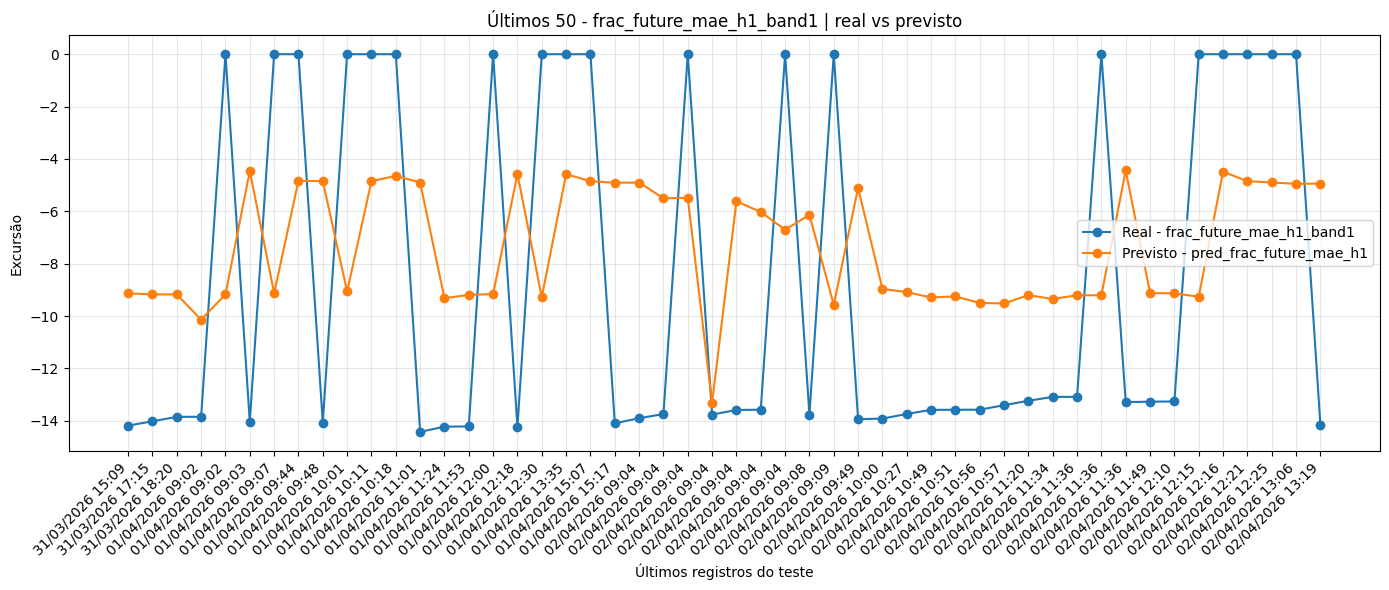


BEST_CONFIG_FUTURE_MAE_H1 =
{
    "TARGET_COL": "frac_future_mae_h1_band2",
    "USE_LOG_TARGET": false,
    "USE_SAMPLE_WEIGHTS": true,
    "WEIGHT_BY_ABS_TARGET": true,
    "N_SPLITS": 5,
    "CV_GAP": 5,
    "OPTUNA_N_JOBS": 4,
    "LGBM_N_JOBS": 2,
    "EXTREME_Q25_WEIGHT": 2.4323331131517256,
    "EXTREME_Q50_WEIGHT": 3.6263019757969635,
    "N_ESTIMATORS": 170,
    "LEARNING_RATE": 0.013988713948376476,
    "NUM_LEAVES": 104,
    "MAX_DEPTH": 3,
    "MIN_CHILD_SAMPLES": 12,
    "MIN_CHILD_WEIGHT": 0.0007139856865809449,
    "SUBSAMPLE": 0.9781227016356479,
    "SUBSAMPLE_FREQ": 2,
    "COLSAMPLE_BYTREE": 0.7465742175421787,
    "REG_ALPHA": 0.0007011732063505432,
    "REG_LAMBDA": 0.6489924803315681,
    "MIN_SPLIT_GAIN": 1.4067870239307374,
    "MAX_BIN": 118,
    "VERBOSITY": -1
}

TOP_SHAP_FUTURE_MAE_H1 =
                   feature  mean_abs_shap
                     dir_1       1.743810
          dir_atual_h2_ma9       0.316662
dir_sum_3_x_abs_dist_ma_20       0.240010
     

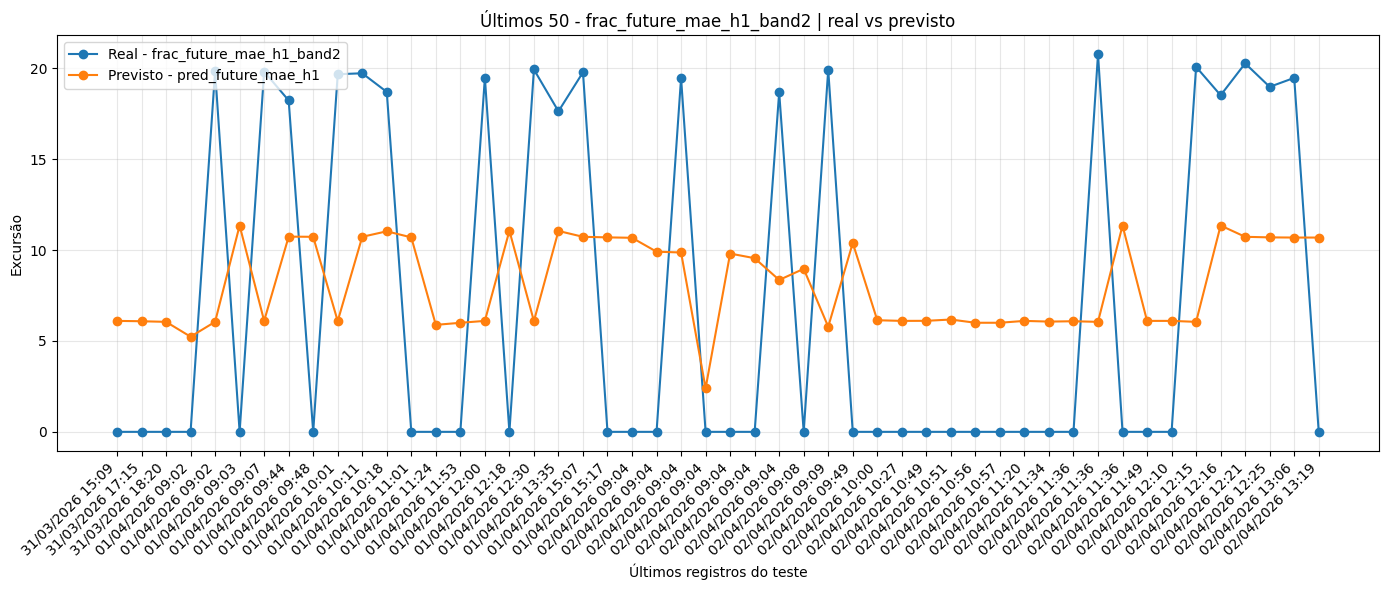

In [36]:
import json
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import optuna

from numba import njit
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)


# Criando alvo
#df_out["future_mae_h1"] = future_mae(df_out, horizon=1, excursion_col="mae_h1")

# Features
features = [
    "above_ma_9",
    "bullish_horizons_ma200",
    "classe_score_ma200",
    "dir_1",
    "dir_atual_h1_ma200",
    "dir_atual_h2_ma200",
    "dir_atual_h2_ma9",
    "dir_atual_h3_ma200",
    "dir_atual_h3_ma9",
    "dir_atual_h5_ma200",
    "dir_atual_h5_ma9",
    "dir_mean_3",
    "dir_sum_3",
    "dir_sum_3_x_abs_dist_ma_20",
    "dist_bricks_ma9",
    "dist_ma_9_bricks",
    "lift_prob_down_h1_ma200",
    "lift_prob_down_h2_ma200",
]

# =========================================================
# CONFIG
# =========================================================
USE_ALL_FEATURES = False

# IMPORTANTE:
# Como o target mae_h1 agora pode ser negativo e positivo,
# o log1p pode gerar NaN para valores < -1.
# Portanto, por padrão, deixe False.
USE_LOG_TARGET = False

# Pesos opcionais:
# Primeiro rode sem pesos. Depois, se quiser, mude para True.
USE_SAMPLE_WEIGHTS = True

# Se usar pesos, pondera extremos pelo módulo do target (abs),
# o que faz mais sentido para target assinado.
WEIGHT_BY_ABS_TARGET = True

LAST_N_TO_COMPARE = 50
SHAP_TOP_N = 10
SHAP_MAX_SAMPLES = 3000
SHAP_ON = "test"   # "dev" ou "test"

N_SPLITS = 5
CV_GAP = 5
N_TRIALS = 150
OPTUNA_TIMEOUT = None
RANDOM_STATE = 42

# paralelismo
OPTUNA_N_JOBS = 4
LGBM_N_JOBS = 2


TARGET_COLS = ["frac_future_mae_h1_band1", "frac_future_mae_h1_band2"]
DROP_COLS = ["Date", "Open", "High", "Low", "Close"] + TARGET_COLS


# =========================================================
# PREP
# =========================================================
if USE_ALL_FEATURES:
    feature_cols = [col for col in df_out.columns if col not in DROP_COLS]
else:
    feature_cols = [col for col in features if col in df_out.columns and col not in DROP_COLS]
    

def build_model_frames_for_target(df_source, target_col, feature_cols):
    required_cols = [target_col]

    if "Date" in df_source.columns:
        required_cols.append("Date")
    if "Close" in df_source.columns:
        required_cols.append("Close")

    required_cols = list(dict.fromkeys(required_cols + feature_cols))

    df_model = df_source.dropna(subset=required_cols).reset_index(drop=True).copy()

    if "Date" in df_model.columns:
        df_model["Date"] = pd.to_datetime(df_model["Date"], errors="coerce")

    if len(df_model) == 0:
        missing_info = df_source[required_cols].isna().sum().sort_values(ascending=False)
        raise ValueError(
            f"Após dropna para o target '{target_col}', o dataframe ficou vazio.\n\n"
            f"Top colunas com NaN:\n{missing_info.head(20)}"
        )

    devel_end = int(len(df_model) * 0.85)
    dev_df = df_model.iloc[:devel_end].reset_index(drop=True).copy()
    test_df = df_model.iloc[devel_end:].reset_index(drop=True).copy()

    print(f"\nTarget: {target_col}")
    print("Shape final do dataframe:", df_model.shape)
    print("Quantidade de features:", len(feature_cols))
    print("Development (CV):", dev_df.shape)
    print("Teste           :", test_df.shape)
    print()

    return df_model, dev_df, test_df


# =========================================================
# UTILS NUMPY / NUMBA
# =========================================================
def inverse_target_transform(y, use_log_target=True):
    y = np.asarray(y, dtype=np.float64)
    if use_log_target:
        y = np.expm1(y)
    return y


@njit(cache=True)
def build_weights_numba(target_to_weight, q25, q50, q25_weight, q50_weight):
    n = target_to_weight.shape[0]
    out = np.empty(n, dtype=np.float32)

    for i in range(n):
        v = target_to_weight[i]

        # threshold maior recebe peso maior
        if v >= q50:
            out[i] = q50_weight
        elif v >= q25:
            out[i] = q25_weight
        else:
            out[i] = 1.0

    return out


def build_extreme_weights_from_train_fast(
    train_target,
    other_target=None,
    q25_weight=2.0,
    q50_weight=5.0,
    weight_by_abs_target=True,
):
    train_target = np.asarray(train_target, dtype=np.float32)
    target_to_weight = train_target if other_target is None else np.asarray(other_target, dtype=np.float32)

    base_train = np.abs(train_target) if weight_by_abs_target else train_target
    base_other = np.abs(target_to_weight) if weight_by_abs_target else target_to_weight

    q25 = float(np.quantile(base_train, 0.25))
    q50 = float(np.quantile(base_train, 0.50))

    weights = build_weights_numba(
        base_other.astype(np.float32),
        np.float32(q25),
        np.float32(q50),
        np.float32(q25_weight),
        np.float32(q50_weight),
    )

    return weights, q25, q50


def prepare_numpy_data(df_in, feature_cols, target_col, use_log_target=False):
    X = np.ascontiguousarray(df_in[feature_cols].to_numpy(dtype=np.float32))
    y_raw = np.ascontiguousarray(df_in[target_col].to_numpy(dtype=np.float32))

    if np.isnan(y_raw).any():
        bad_idx = np.where(np.isnan(y_raw))[0][:10]
        raise ValueError(f"{target_col}: y_raw contém NaN. Exemplos de índices: {bad_idx}")

    if use_log_target:
        if np.any(y_raw <= -1.0):
            bad_vals = y_raw[y_raw <= -1.0][:10]
            raise ValueError(
                f"{target_col}: USE_LOG_TARGET=True é incompatível com valores <= -1. "
                f"Exemplos: {bad_vals}"
            )
        y_trans = np.log1p(y_raw)
    else:
        y_trans = y_raw.copy()

    if np.isnan(y_trans).any():
        bad_idx = np.where(np.isnan(y_trans))[0][:10]
        raise ValueError(f"{target_col}: y transformado contém NaN. Exemplos de índices: {bad_idx}")

    return X, y_raw, y_trans


# =========================================================
# DATA CLASS
# =========================================================
@dataclass
class FoldMetrics:
    fold: int
    r2: float
    mae: float
    rmse: float
    best_iteration: int


# =========================================================
# OPTUNA SEARCH SPACE
# =========================================================
def get_optuna_search_space(trial, use_sample_weights=False):
    params = {
        "objective": "regression",
        "boosting_type": "gbdt",
        "n_estimators": trial.suggest_int("n_estimators", 500, 5000),
        "learning_rate": trial.suggest_float("learning_rate", 0.003, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 255),
        "max_depth": trial.suggest_categorical("max_depth", [-1, 3, 4, 5, 6, 7, 8, 10, 12]),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 120),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-4, 50.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.50, 1.00),
        "subsample_freq": trial.suggest_int("subsample_freq", 0, 7),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.50, 1.00),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 50.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 50.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 2.0),
        "max_bin": trial.suggest_int("max_bin", 63, 511),
        "random_state": RANDOM_STATE,
        "n_jobs": LGBM_N_JOBS,
        "verbosity": -1,
    }

    if use_sample_weights:
        weights_cfg = {
            "q25_weight": trial.suggest_float("q25_weight", 2.0, 3.0),
            "q50_weight": trial.suggest_float("q50_weight", 2.0, 5.0),
        }

        # só garante que o threshold maior não tenha peso menor
        weights_cfg["q50_weight"] = max(weights_cfg["q50_weight"], weights_cfg["q25_weight"])
    else:
        weights_cfg = {
            "q25_weight": 1.0,
            "q50_weight": 1.0,
        }

    return params, weights_cfg


# =========================================================
# CV FAST
# =========================================================
def run_cv_for_params_fast(
    X,
    y_raw,
    y_trans,
    splits,
    params,
    weights_cfg,
    use_log_target=False,
    use_sample_weights=False,
    weight_by_abs_target=True,
):
    fold_metrics = []

    for fold_idx, (tr_idx, va_idx) in enumerate(splits, start=1):
        X_tr = X[tr_idx]
        X_va = X[va_idx]

        y_tr_raw = y_raw[tr_idx]
        y_va_raw = y_raw[va_idx]

        y_tr = y_trans[tr_idx] if use_log_target else y_tr_raw
        y_va = y_trans[va_idx] if use_log_target else y_va_raw

        if np.isnan(y_tr).any():
            raise ValueError(f"Fold {fold_idx}: y_tr contém NaN.")
        if np.isnan(y_va).any():
            raise ValueError(f"Fold {fold_idx}: y_va contém NaN.")

        model = LGBMRegressor(**params)

        if use_sample_weights:
            w_tr, _, _ = build_extreme_weights_from_train_fast(
                y_tr_raw,
                ##q75_weight=weights_cfg["q75_weight"],
                #q90_weight=weights_cfg["q90_weight"],
                #q97_weight=weights_cfg["q97_weight"],
                q25_weight=weights_cfg["q25_weight"],
                q50_weight=weights_cfg["q50_weight"],
                weight_by_abs_target=weight_by_abs_target,
            )

            w_va, _, _ = build_extreme_weights_from_train_fast(
            y_tr_raw,
            other_target=y_va_raw,
            q25_weight=weights_cfg["q25_weight"],
            q50_weight=weights_cfg["q50_weight"],
            weight_by_abs_target=weight_by_abs_target,
        )

            model.fit(
                X_tr,
                y_tr,
                sample_weight=w_tr,
                eval_set=[(X_va, y_va)],
                eval_sample_weight=[w_va],
                eval_metric="rmse",
                callbacks=[
                    early_stopping(stopping_rounds=200, verbose=False),
                    log_evaluation(period=0),
                ],
            )
        else:
            model.fit(
                X_tr,
                y_tr,
                eval_set=[(X_va, y_va)],
                eval_metric="rmse",
                callbacks=[
                    early_stopping(stopping_rounds=200, verbose=False),
                    log_evaluation(period=0),
                ],
            )

        pred_va = inverse_target_transform(
            model.predict(X_va),
            use_log_target=use_log_target
        )
        y_va_real = inverse_target_transform(
            y_va,
            use_log_target=use_log_target
        )

        fold_metrics.append(
            FoldMetrics(
                fold=fold_idx,
                r2=float(r2_score(y_va_real, pred_va)),
                mae=float(mean_absolute_error(y_va_real, pred_va)),
                rmse=float(np.sqrt(mean_squared_error(y_va_real, pred_va))),
                best_iteration=int(getattr(model, "best_iteration_", params["n_estimators"])),
            )
        )

    return fold_metrics


def summarize_cv_metrics(fold_metrics):
    r2s = np.array([fm.r2 for fm in fold_metrics], dtype=np.float64)
    maes = np.array([fm.mae for fm in fold_metrics], dtype=np.float64)
    rmses = np.array([fm.rmse for fm in fold_metrics], dtype=np.float64)
    best_iters = np.array([fm.best_iteration for fm in fold_metrics], dtype=np.int32)

    fold_table = pd.DataFrame([fm.__dict__ for fm in fold_metrics])

    return {
        "mean_r2": float(r2s.mean()),
        "std_r2": float(r2s.std(ddof=1)) if len(r2s) > 1 else 0.0,
        "mean_mae": float(maes.mean()),
        "mean_rmse": float(rmses.mean()),
        "median_best_iteration": int(np.median(best_iters)),
        "fold_table": fold_table,
    }


# =========================================================
# SHAP
# =========================================================
def get_top_features_via_shap_regressor(model, X_explain, feature_names, top_n=10, max_samples=3000):
    if len(X_explain) > max_samples:
        rng = np.random.default_rng(RANDOM_STATE)
        idx = rng.choice(len(X_explain), size=max_samples, replace=False)
        X_used = X_explain[idx]
    else:
        X_used = X_explain

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_used)
    shap_arr = np.asarray(shap_values)

    if shap_arr.ndim != 2:
        raise ValueError(f"Formato inesperado de shap_values em regressão: {shap_arr.shape}")

    mean_abs_shap = np.abs(shap_arr).mean(axis=0)

    shap_importance_df = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    return shap_importance_df.head(top_n)


# =========================================================
# OPTIMIZER
# =========================================================
def optimize_lgbm_with_optuna_cv_fast(
    X_dev,
    y_dev_raw,
    y_dev_trans,
    splits,
    target_col,
    n_trials=80,
    timeout=None,
    use_log_target=False,
    use_sample_weights=False,
    weight_by_abs_target=True,
):
    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=10)

    study = optuna.create_study(
        direction="maximize",
        sampler=sampler,
        pruner=pruner
    )

    def objective(trial):
        params, weights_cfg = get_optuna_search_space(
            trial,
            use_sample_weights=use_sample_weights
        )

        fold_metrics = run_cv_for_params_fast(
            X=X_dev,
            y_raw=y_dev_raw,
            y_trans=y_dev_trans,
            splits=splits,
            params=params,
            weights_cfg=weights_cfg,
            use_log_target=use_log_target,
            use_sample_weights=use_sample_weights,
            weight_by_abs_target=weight_by_abs_target,
        )
        summary = summarize_cv_metrics(fold_metrics)

        trial.set_user_attr("mean_r2", summary["mean_r2"])
        trial.set_user_attr("std_r2", summary["std_r2"])
        trial.set_user_attr("median_best_iteration", summary["median_best_iteration"])

        return summary["mean_r2"]

    study.optimize(
        objective,
        n_trials=n_trials,
        timeout=timeout,
        n_jobs=OPTUNA_N_JOBS,
        show_progress_bar=True,
    )

    best_params_raw = study.best_params.copy()

    if use_sample_weights:
        best_weights_cfg = {
            #"q75_weight": float(best_params_raw.pop("q75_weight")),
            #"q90_weight": float(best_params_raw.pop("q90_weight")),
            #"q97_weight": float(best_params_raw.pop("q97_weight")),
            "q25_weight": float(best_params_raw.pop("q25_weight")),
            "q50_weight": float(best_params_raw.pop("q50_weight")),
        }
    else:
        best_weights_cfg = {
            #"q75_weight": 1.0,
            #"q90_weight": 1.0,
            #"q97_weight": 1.0,
            "q25_weight": 1.0,
            "q50_weight": 1.0,
        }

    best_model_params = {
        "objective": "regression",
        "boosting_type": "gbdt",
        "random_state": RANDOM_STATE,
        "n_jobs": LGBM_N_JOBS,
        "verbosity": -1,
        **best_params_raw,
    }

    best_fold_metrics = run_cv_for_params_fast(
        X=X_dev,
        y_raw=y_dev_raw,
        y_trans=y_dev_trans,
        splits=splits,
        params=best_model_params,
        weights_cfg=best_weights_cfg,
        use_log_target=use_log_target,
        use_sample_weights=use_sample_weights,
        weight_by_abs_target=weight_by_abs_target,
    )

    best_summary = summarize_cv_metrics(best_fold_metrics)

    final_training_config = {
        "TARGET_COL": target_col,
        "USE_LOG_TARGET": use_log_target,
        "USE_SAMPLE_WEIGHTS": use_sample_weights,
        "WEIGHT_BY_ABS_TARGET": weight_by_abs_target,
        "N_SPLITS": N_SPLITS,
        "CV_GAP": CV_GAP,
        "OPTUNA_N_JOBS": OPTUNA_N_JOBS,
        "LGBM_N_JOBS": LGBM_N_JOBS,
        #"EXTREME_Q75_WEIGHT": float(best_weights_cfg["q75_weight"]),
        #"EXTREME_Q90_WEIGHT": float(best_weights_cfg["q90_weight"]),
        #"EXTREME_Q97_WEIGHT": float(best_weights_cfg["q97_weight"]),
        "EXTREME_Q25_WEIGHT": float(best_weights_cfg["q25_weight"]),
        "EXTREME_Q50_WEIGHT": float(best_weights_cfg["q50_weight"]),
        "N_ESTIMATORS": int(best_summary["median_best_iteration"]),
        "LEARNING_RATE": float(best_model_params["learning_rate"]),
        "NUM_LEAVES": int(best_model_params["num_leaves"]),
        "MAX_DEPTH": int(best_model_params["max_depth"]),
        "MIN_CHILD_SAMPLES": int(best_model_params["min_child_samples"]),
        "MIN_CHILD_WEIGHT": float(best_model_params["min_child_weight"]),
        "SUBSAMPLE": float(best_model_params["subsample"]),
        "SUBSAMPLE_FREQ": int(best_model_params["subsample_freq"]),
        "COLSAMPLE_BYTREE": float(best_model_params["colsample_bytree"]),
        "REG_ALPHA": float(best_model_params["reg_alpha"]),
        "REG_LAMBDA": float(best_model_params["reg_lambda"]),
        "MIN_SPLIT_GAIN": float(best_model_params["min_split_gain"]),
        "MAX_BIN": int(best_model_params["max_bin"]),
        "VERBOSITY": -1,
    }

    return {
        "study": study,
        "best_model_params": best_model_params,
        "best_weights_cfg": best_weights_cfg,
        "best_summary": best_summary,
        "best_fold_table": best_summary["fold_table"],
        "final_training_config": final_training_config,
    }


# =========================================================
# FINAL FIT
# =========================================================
def fit_final_model_from_config_fast(
    X_dev,
    y_dev_raw,
    y_dev_trans,
    X_test,
    y_test_raw,
    training_config
):
    y_dev = y_dev_trans if training_config["USE_LOG_TARGET"] else y_dev_raw
    y_test = np.log1p(y_test_raw) if training_config["USE_LOG_TARGET"] else y_test_raw.copy()

    model = LGBMRegressor(
        objective="regression",
        boosting_type="gbdt",
        n_estimators=training_config["N_ESTIMATORS"],
        learning_rate=training_config["LEARNING_RATE"],
        num_leaves=training_config["NUM_LEAVES"],
        max_depth=training_config["MAX_DEPTH"],
        min_child_samples=training_config["MIN_CHILD_SAMPLES"],
        min_child_weight=training_config["MIN_CHILD_WEIGHT"],
        subsample=training_config["SUBSAMPLE"],
        subsample_freq=training_config["SUBSAMPLE_FREQ"],
        colsample_bytree=training_config["COLSAMPLE_BYTREE"],
        reg_alpha=training_config["REG_ALPHA"],
        reg_lambda=training_config["REG_LAMBDA"],
        min_split_gain=training_config["MIN_SPLIT_GAIN"],
        max_bin=training_config["MAX_BIN"],
        random_state=RANDOM_STATE,
        n_jobs=LGBM_N_JOBS,
        verbosity=-1,
    )

    if training_config["USE_SAMPLE_WEIGHTS"]:
        dev_weights, _, _ = build_extreme_weights_from_train_fast(
        y_dev_raw,
        q25_weight=training_config["EXTREME_Q25_WEIGHT"],
        q50_weight=training_config["EXTREME_Q50_WEIGHT"],
        weight_by_abs_target=training_config["WEIGHT_BY_ABS_TARGET"],
    )
        model.fit(X_dev, y_dev, sample_weight=dev_weights)
    else:
        model.fit(X_dev, y_dev)

    pred_test = inverse_target_transform(
        model.predict(X_test),
        use_log_target=training_config["USE_LOG_TARGET"]
    )
    y_test_real = inverse_target_transform(
        y_test,
        use_log_target=training_config["USE_LOG_TARGET"]
    )

    results_test = {
        "mae": float(mean_absolute_error(y_test_real, pred_test)),
        "rmse": float(np.sqrt(mean_squared_error(y_test_real, pred_test))),
        "r2": float(r2_score(y_test_real, pred_test)),
        "y_real": y_test_real,
        "y_pred": pred_test,
    }

    return model, results_test


# =========================================================
# PLOT
# =========================================================
def plot_last_n_predictions(df_compare, actual_col, pred_col, title):
    plt.figure(figsize=(14, 6))
    x = np.arange(len(df_compare))
    plt.plot(x, df_compare[actual_col].values, marker="o", label=f"Real - {actual_col}")
    plt.plot(x, df_compare[pred_col].values, marker="o", label=f"Previsto - {pred_col}")

    if "Date" in df_compare.columns:
        date_series = pd.to_datetime(df_compare["Date"], errors="coerce")
        labels = [
            d.strftime("%d/%m/%Y %H:%M") if pd.notna(d) else str(idx)
            for d, idx in zip(date_series, df_compare.index)
        ]
    else:
        labels = [str(idx) for idx in df_compare.index]

    plt.xticks(x, labels, rotation=45, ha="right")
    plt.title(title)
    plt.xlabel("Últimos registros do teste")
    plt.ylabel("Excursão")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# PIPELINE POR TARGET
# =========================================================
def run_pipeline_for_target(target_col):
    print("\n" + "#" * 120)
    print(f"OTIMIZANDO COM OPTUNA + TIME SERIES CV: {target_col}")
    print("#" * 120)

    df_model, dev_df, test_df = build_model_frames_for_target(
        df_source=df_out,
        target_col=target_col,
        feature_cols=feature_cols
    )

    X_dev, y_dev_raw, y_dev_trans = prepare_numpy_data(
        dev_df,
        feature_cols,
        target_col,
        use_log_target=USE_LOG_TARGET
    )
    X_test, y_test_raw, _ = prepare_numpy_data(
        test_df,
        feature_cols,
        target_col,
        use_log_target=USE_LOG_TARGET
    )

    if len(X_dev) == 0:
        raise ValueError(f"X_dev ficou vazio para o target '{target_col}'.")
    if len(X_test) == 0:
        raise ValueError(f"X_test ficou vazio para o target '{target_col}'.")

    tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=CV_GAP)
    splits = list(tscv.split(X_dev))

    opt_res = optimize_lgbm_with_optuna_cv_fast(
        X_dev=X_dev,
        y_dev_raw=y_dev_raw,
        y_dev_trans=y_dev_trans,
        splits=splits,
        target_col=target_col,
        n_trials=N_TRIALS,
        timeout=OPTUNA_TIMEOUT,
        use_log_target=USE_LOG_TARGET,
        use_sample_weights=USE_SAMPLE_WEIGHTS,
        weight_by_abs_target=WEIGHT_BY_ABS_TARGET,
    )

    print("\n" + "=" * 100)
    print(f"MELHOR CONFIGURAÇÃO CV - {target_col}")
    print("=" * 100)
    print(json.dumps(opt_res["final_training_config"], indent=4, ensure_ascii=False))
    print()

    print("Tabela dos folds da melhor configuração:")
    print(opt_res["best_fold_table"].to_string(index=False))
    print()
    print(f"Média CV R²   : {opt_res['best_summary']['mean_r2']:.6f}")
    print(f"Desvio CV R²  : {opt_res['best_summary']['std_r2']:.6f}")
    print(f"Média CV MAE  : {opt_res['best_summary']['mean_mae']:.6f}")
    print(f"Média CV RMSE : {opt_res['best_summary']['mean_rmse']:.6f}")
    print(f"Median best_iteration: {opt_res['best_summary']['median_best_iteration']}\n")

    final_model, final_results_test = fit_final_model_from_config_fast(
        X_dev=X_dev,
        y_dev_raw=y_dev_raw,
        y_dev_trans=y_dev_trans,
        X_test=X_test,
        y_test_raw=y_test_raw,
        training_config=opt_res["final_training_config"],
    )

    X_shap = X_dev if SHAP_ON == "dev" else X_test

    shap_top = get_top_features_via_shap_regressor(
        model=final_model,
        X_explain=X_shap,
        feature_names=feature_cols,
        top_n=SHAP_TOP_N,
        max_samples=SHAP_MAX_SAMPLES,
    )

    print(f"R² teste final  ({target_col}): {final_results_test['r2']:.6f}")
    print(f"MAE teste final ({target_col}): {final_results_test['mae']:.6f}")
    print(f"RMSE teste final({target_col}): {final_results_test['rmse']:.6f}\n")

    print("=" * 100)
    print(f"TOP {SHAP_TOP_N} FEATURES VIA SHAP - {target_col}")
    print("=" * 100)
    print(shap_top.to_string(index=False))
    print()

    return {
        "optimization": opt_res,
        "final_model": final_model,
        "final_results_test": final_results_test,
        "shap_top": shap_top,
        "df_model": df_model,
        "dev_df": dev_df,
        "test_df": test_df,
    }


# =========================================================
# EXECUÇÃO
# =========================================================
frac_bundle = run_pipeline_for_target(TARGET_COLS[0])
non_frac_bundle = run_pipeline_for_target(TARGET_COLS[1])

compare_cols = []
if "Date" in frac_bundle["test_df"].columns:
    compare_cols.append("Date")
if "Close" in frac_bundle["test_df"].columns:
    compare_cols.append("Close")

# -----------------------------
# BAND 1
# -----------------------------
compare_df_frac = frac_bundle["test_df"][compare_cols + [TARGET_COLS[0]]].copy()
compare_df_frac["pred_frac_future_mae_h1"] = frac_bundle["final_results_test"]["y_pred"]
compare_df_frac["erro_abs_frac"] = np.abs(
    compare_df_frac[TARGET_COLS[0]].values - compare_df_frac["pred_frac_future_mae_h1"].values
)

last_n_compare_frac = compare_df_frac.tail(LAST_N_TO_COMPARE).copy()

print("\nBEST_CONFIG_FRAC_FUTURE_MAE_H1 =")
print(json.dumps(frac_bundle["optimization"]["final_training_config"], indent=4, ensure_ascii=False))

print("\nTOP_SHAP_FRAC_FUTURE_MAE_H1 =")
print(frac_bundle["shap_top"].to_string(index=False))

print("\n" + "=" * 120)
print(f"ÚLTIMOS {LAST_N_TO_COMPARE} REGISTROS DO TESTE - FRAC_FUTURE_MAE_H1 - COMPARAÇÃO REAL VS PREVISTO")
print("=" * 120)
print(last_n_compare_frac.to_string(index=True))
print()

plot_last_n_predictions(
    last_n_compare_frac,
    TARGET_COLS[0],
    "pred_frac_future_mae_h1",
    f"Últimos {LAST_N_TO_COMPARE} - {TARGET_COLS[0]} | real vs previsto",
)

# -----------------------------
# BAND 2
# -----------------------------
compare_cols_sell = []
if "Date" in non_frac_bundle["test_df"].columns:
    compare_cols_sell.append("Date")
if "Close" in non_frac_bundle["test_df"].columns:
    compare_cols_sell.append("Close")

compare_df_sell = non_frac_bundle["test_df"][compare_cols_sell + [TARGET_COLS[1]]].copy()
compare_df_sell["pred_future_mae_h1"] = non_frac_bundle["final_results_test"]["y_pred"]
compare_df_sell["erro_abs_sell"] = np.abs(
    compare_df_sell[TARGET_COLS[1]].values - compare_df_sell["pred_future_mae_h1"].values
)

last_n_compare_non_frac = compare_df_sell.tail(LAST_N_TO_COMPARE).copy()

print("\nBEST_CONFIG_FUTURE_MAE_H1 =")
print(json.dumps(non_frac_bundle["optimization"]["final_training_config"], indent=4, ensure_ascii=False))

print("\nTOP_SHAP_FUTURE_MAE_H1 =")
print(non_frac_bundle["shap_top"].to_string(index=False))

print("\n" + "=" * 120)
print(f"ÚLTIMOS {LAST_N_TO_COMPARE} REGISTROS DO TESTE - FUTURE_MAE_H1 - COMPARAÇÃO REAL VS PREVISTO")
print("=" * 120)
print(last_n_compare_non_frac.to_string(index=True))
print()

plot_last_n_predictions(
    last_n_compare_non_frac,
    TARGET_COLS[1],
    "pred_future_mae_h1",
    f"Últimos {LAST_N_TO_COMPARE} - {TARGET_COLS[1]} | real vs previsto",
    
)

In [37]:
print(df_out[["Date", "Close", "frac_future_mae_h1_band1", "frac_future_mae_h1_band2"]].tail(10).to_string(index=False))

                   Date  Close  frac_future_mae_h1_band1  frac_future_mae_h1_band2
2026-04-02 11:36:23.674 189405                  0.000000                 20.775350
2026-04-02 11:36:39.836 188715                -13.285576                  0.000000
2026-04-02 11:49:08.575 189405                -13.267059                  0.000000
2026-04-02 12:10:55.496 189750                -13.260022                  0.000000
2026-04-02 12:15:27.227 190095                  0.000000                 20.079688
2026-04-02 12:16:53.107 189405                  0.000000                 18.516268
2026-04-02 12:21:24.539 189060                  0.000000                 20.270431
2026-04-02 12:25:50.738 188715                  0.000000                 18.980137
2026-04-02 13:06:13.097 188370                  0.000000                 19.474140
2026-04-02 13:19:43.664 188025                -14.154163                  0.000000


# 8. Transformadores Probabilísticos e Construção de Probabilidades Futuras

A próxima etapa introduz transformadores que produzem probabilidades futuras a partir de estados de mercado, com foco em evitar vazamento temporal e respeitar a ordem cronológica dos dados.

Esse bloco serve como ponte entre:
- a engenharia de atributos;
- os estudos de probabilidade condicional;
- e a futura construção de regras operacionais.


# 9. Análise de Correlação e Seleção de Features

Nesta etapa, o notebook passa da construção do alvo para a análise explícita de associação entre o alvo (em diferentes representações) e o conjunto de features disponível. Este é o bloco que materializa empiricamente a hipótese central do trabalho.

A comparação relevante aqui não é apenas “quais features têm correlação maior”, mas **como o perfil das features mais associadas muda quando o alvo é transformado**. Em especial, observou-se que:

- a representação **log-transformada + fracionariamente diferenciada** tende a se alinhar mais fortemente a variáveis categóricas/discretas de estado e regime;
- a representação **sem log**, ainda que diferenciada, tende a manter maior associação com variáveis contínuas ligadas à magnitude do movimento.

Essa leitura é metodologicamente importante porque mostra que a transformação do alvo altera o tipo de estrutura estatística que se torna visível. Assim, a seleção de features deixa de ser uma etapa neutra e passa a depender da representação escolhida para a variável-resposta.

## 9.1 Interpretação metodológica dos resultados de correlação

O achado mais relevante desta etapa é que o padrão de associação observado depende da **representação do alvo**. Quando `future_mae_h1` foi submetido à transformação logarítmica antes da diferenciação fracionária, as associações mais fortes tenderam a aparecer em variáveis categóricas ou discretas de regime. Já quando a transformação logarítmica foi retirada, a estrutura de associação deslocou-se com maior intensidade para variáveis contínuas.

Esse resultado pode ser interpretado da seguinte forma:

- o **logaritmo** comprime extremos e reduz a dominância da magnitude bruta;
- a **diferenciação fracionária** altera a persistência da série e evidencia componentes locais;
- em conjunto, essas operações podem aproximar o alvo de descrições estruturais de estado;
- sem o logaritmo, a amplitude original do fenômeno permanece mais visível, favorecendo associação com variáveis contínuas.

Portanto, a diferença observada nas correlações não deve ser lida como simples curiosidade empírica, mas como evidência de que diferentes transformações respondem a diferentes perguntas analíticas sobre o mesmo fenômeno.

## HOUVE UMA APRESENTAÇÃO DE OUTRO TIPO DE FEATURES COM APENAS UMA BANDA DA DISTRIBUIÇÃO BIMODAL DO TARGET

In [38]:
# Analisar quais features de df_out estão mais correlacionadas com df_out['frac_future_mae_h1_band1']
correlations = df_out.corrwith(df_out['frac_future_mae_h1_band1']).abs().sort_values(ascending=False)
print("Top 150 features mais correlacionadas com frac_future_mae_h1_band1:")
print(correlations.head(50).to_markdown())

Top 150 features mais correlacionadas com frac_future_mae_h1_band1:
|                          |        0 |
|:-------------------------|---------:|
| frac_future_mae_h1_band1 | 1        |
| frac_future_mae_h1       | 0.993583 |
| frac_future_mae_h1_band2 | 0.97891  |
| future_mae_h1            | 0.799533 |
| frac_mae_h1              | 0.318027 |
| dir_1                    | 0.285149 |
| renko_dir_ma50           | 0.285149 |
| renko_dir_ma9            | 0.285149 |
| renko_dir_ma200          | 0.285149 |
| renko_dir_ma20           | 0.285149 |
| med_points_h1_ma9        | 0.279388 |
| dir_atual_h1_ma9         | 0.278501 |
| dir_atual_h3_ma9         | 0.278501 |
| dir_atual_h5_ma9         | 0.278501 |
| dir_atual_h2_ma9         | 0.278501 |
| dir_atual_h2_ma20        | 0.274913 |
| dir_atual_h5_ma20        | 0.274913 |
| dir_atual_h3_ma20        | 0.274913 |
| dir_atual_h1_ma20        | 0.274913 |
| dir_atual_h1_ma50        | 0.274484 |
| dir_atual_h2_ma50        | 0.274484 |
| dir_atual_

In [39]:
# Analisar quais features de df_out estão mais correlacionadas com df_out['frac_future_mae_h1_band2']
correlations = df_out.corrwith(df_out['frac_future_mae_h1_band2']).abs().sort_values(ascending=False)
print("Top 50 features mais correlacionadas com frac_future_mae_h1_band2:")
print(correlations.head(50).to_markdown())

Top 50 features mais correlacionadas com frac_future_mae_h1_band2:
|                          |        0 |
|:-------------------------|---------:|
| frac_future_mae_h1_band2 | 1        |
| frac_future_mae_h1       | 0.995498 |
| frac_future_mae_h1_band1 | 0.97891  |
| future_mae_h1            | 0.826026 |
| frac_mae_h1              | 0.293085 |
| renko_dir_ma9            | 0.260759 |
| renko_dir_ma200          | 0.260759 |
| dir_1                    | 0.260759 |
| renko_dir_ma20           | 0.260759 |
| renko_dir_ma50           | 0.260759 |
| med_points_h1_ma9        | 0.254549 |
| dir_atual_h3_ma9         | 0.253828 |
| dir_atual_h2_ma9         | 0.253828 |
| dir_atual_h1_ma9         | 0.253828 |
| dir_atual_h5_ma9         | 0.253828 |
| dir_atual_h3_ma20        | 0.251004 |
| dir_atual_h2_ma20        | 0.251004 |
| dir_atual_h1_ma20        | 0.251004 |
| dir_atual_h5_ma20        | 0.251004 |
| dir_atual_h1_ma50        | 0.249477 |
| dir_atual_h3_ma50        | 0.249477 |
| dir_atual_h

## CORRELAÇÃO MAIOR COM O ALVO DIFERENCIADO FRACIONARIAMENTE (EFEITO DA ESTACIONARIEDADE)

In [40]:
# Analisar quais features de df_out estão mais correlacionadas com df_out['frac_future_mae_h1_band2']
correlations = df_out.corrwith(df_out['frac_future_mae_h1_band2']).abs().sort_values(ascending=False)
print("Top 50 features mais correlacionadas com frac_future_mae_h1_band2:")
print(correlations.head(50))

Top 50 features mais correlacionadas com frac_future_mae_h1_band2:
frac_future_mae_h1_band2    1.000000
frac_future_mae_h1          0.995498
frac_future_mae_h1_band1    0.978910
future_mae_h1               0.826026
frac_mae_h1                 0.293085
renko_dir_ma9               0.260759
renko_dir_ma200             0.260759
dir_1                       0.260759
renko_dir_ma20              0.260759
renko_dir_ma50              0.260759
med_points_h1_ma9           0.254549
dir_atual_h3_ma9            0.253828
dir_atual_h2_ma9            0.253828
dir_atual_h1_ma9            0.253828
dir_atual_h5_ma9            0.253828
dir_atual_h3_ma20           0.251004
dir_atual_h2_ma20           0.251004
dir_atual_h1_ma20           0.251004
dir_atual_h5_ma20           0.251004
dir_atual_h1_ma50           0.249477
dir_atual_h3_ma50           0.249477
dir_atual_h2_ma50           0.249477
dir_atual_h5_ma50           0.249152
med_points_h1_ma50          0.248927
dir_atual_h3_ma200          0.248776
dir_atua

## CORRELAÇÃO MENOR ENTRE AS FEATURES E O ALVO NÃO TRANSFORMADO (NÃO ESTACIONÁRIO)

In [41]:
# Analisar quais features de df_out estão mais correlacionadas com df['future_mae_h1']
correlations = df_out.corrwith(df['future_mae_h1']).abs().sort_values(ascending=False)
print("Top 50 features mais correlacionadas com future_mae_h1:")
print(correlations.head(50).to_markdown())

Top 50 features mais correlacionadas com future_mae_h1:
|                                   |         0 |
|:----------------------------------|----------:|
| future_mae_h1                     | 1         |
| frac_future_mae_h1_band2          | 0.826026  |
| frac_future_mae_h1                | 0.818424  |
| frac_future_mae_h1_band1          | 0.799533  |
| regiao_ma_h2_ma9                  | 0.0551341 |
| regiao_ma_h3_ma9                  | 0.0551341 |
| regiao_ma_h1_ma9                  | 0.0551341 |
| regiao_ma_h5_ma9                  | 0.0551341 |
| classe_score_ma200                | 0.054183  |
| dir_atual_h2_ma200                | 0.0537484 |
| dir_atual_h1_ma200                | 0.0537484 |
| dir_atual_h5_ma200                | 0.0537484 |
| dir_atual_h3_ma200                | 0.0537484 |
| bullish_horizons_ma200            | 0.0534774 |
| med_points_h1_ma200               | 0.0534437 |
| neg_rate_since_cross_below_ma_9   | 0.0530958 |
| next_bias_h1_ma200                | 0.0530

## ESTUDO DAS PROBABILIDADES DO TAMANHO DO PAVIO NOS MAIS VARIADOS PERCENTIS

In [47]:
# ESTUDO - Construir estudo de probabilidades condicionais para future_mae_h1 usando as features mais correlacionadas

res_disc = build_discrete_probability_study(
    df=df_out,
    y="future_mae_h1",
    discrete_vars=[
        "dir_1",
        "renko_dir_ma200",
        "renko_dir_ma20",
        "renko_dir_ma9",
        "renko_dir_ma50",
        "classe_score_ma20",
        "classe_score_ma9",
        "classe_score_ma50",
        "classe_score_ma200",
        "dir_sum_3_x_abs_dist_ma_20_binned",
        "dist_bricks_ma9_binned",
        "dist_ma_9_bricks_binned",
        "lift_prob_down_h1_ma200_binned",
        "lift_prob_down_h2_ma200_binned",
    ],
    train_frac=0.70,
    min_count=1,
    event_mode="between",
    lower=0,
    upper=690,
    mode_round_step=25,
    sort_by="prob_event",
)

In [48]:
# RESULTADOS DO ESTUDO

print("Baseline:", res_disc["baseline_prob"])

cols_show = (
    res_disc["discrete_vars"]
    + [
        "n",
        "baseline_prob",
        "prob_event",
        "lift",
        "delta_prob",
        "train_prob_event",
        "train_lift",
        "delta_train_prob",
        "mean_y",
        "median_y",
        "mode_y_rounded",
        "p10_y",
        "p25_y",
        "p50_y",
        "p75_y",
        "p90_y",
    ]
)

print(
    res_disc["grouped"][cols_show].to_markdown(index=False)
)

Baseline: 0.5222816399286988
|   dir_1 |   renko_dir_ma200 |   renko_dir_ma20 |   renko_dir_ma9 |   renko_dir_ma50 |   classe_score_ma20 |   classe_score_ma9 |   classe_score_ma50 |   classe_score_ma200 |   dir_sum_3_x_abs_dist_ma_20_binned |   dist_bricks_ma9_binned |   dist_ma_9_bricks_binned |   lift_prob_down_h1_ma200_binned |   lift_prob_down_h2_ma200_binned |   n |   baseline_prob |   prob_event |     lift |   delta_prob |   train_prob_event |   train_lift |   delta_train_prob |      mean_y |   median_y |   mode_y_rounded |   p10_y |   p25_y |   p50_y |   p75_y |   p90_y |
|--------:|------------------:|-----------------:|----------------:|-----------------:|--------------------:|-------------------:|--------------------:|---------------------:|------------------------------------:|-------------------------:|--------------------------:|---------------------------------:|---------------------------------:|----:|----------------:|-------------:|---------:|-------------:|-----------

In [44]:
# CONSTRUÇÃO DO TARGET

df_out = build_renko_4class_target_pandas(
    df_out,
    dir_col="dir_1",
    horizon=3,
    target_col="target",
    sum_col="soma_dir_futura_3",
    neutral_value=np.nan
)

df_out["target_bin"] = (df_out["target"] > 0).astype("int64")

Distribuição do target binário puro (0/1):
target_bin
0    9124
1    9575
Name: count, dtype: int64

Distribuição percentual do target binário puro:
target_bin
0    0.487941
1    0.512059
Name: proportion, dtype: float64

Quantidade total de linhas após filtrar casos puros:
18699

Shape final após dropna: (18699, 22)

Distribuição do alvo final:
target_bin
0    9124
1    9575
Name: count, dtype: int64

Distribuição percentual do alvo final:
target_bin
0    0.487941
1    0.512059
Name: proportion, dtype: float64

Tamanhos dos conjuntos:
Treino:    13089
Validação: 2805
Teste:     2805

Distribuição do alvo por conjunto:

Treino:
target_bin
0    6440
1    6649
Name: count, dtype: int64
target_bin
0    0.492016
1    0.507984
Name: proportion, dtype: float64

Validação:
target_bin
0    1377
1    1428
Name: count, dtype: int64
target_bin
0    0.490909
1    0.509091
Name: proportion, dtype: float64

Teste:
target_bin
0    1307
1    1498
Name: count, dtype: int64
target_bin
0    0.465954
1   

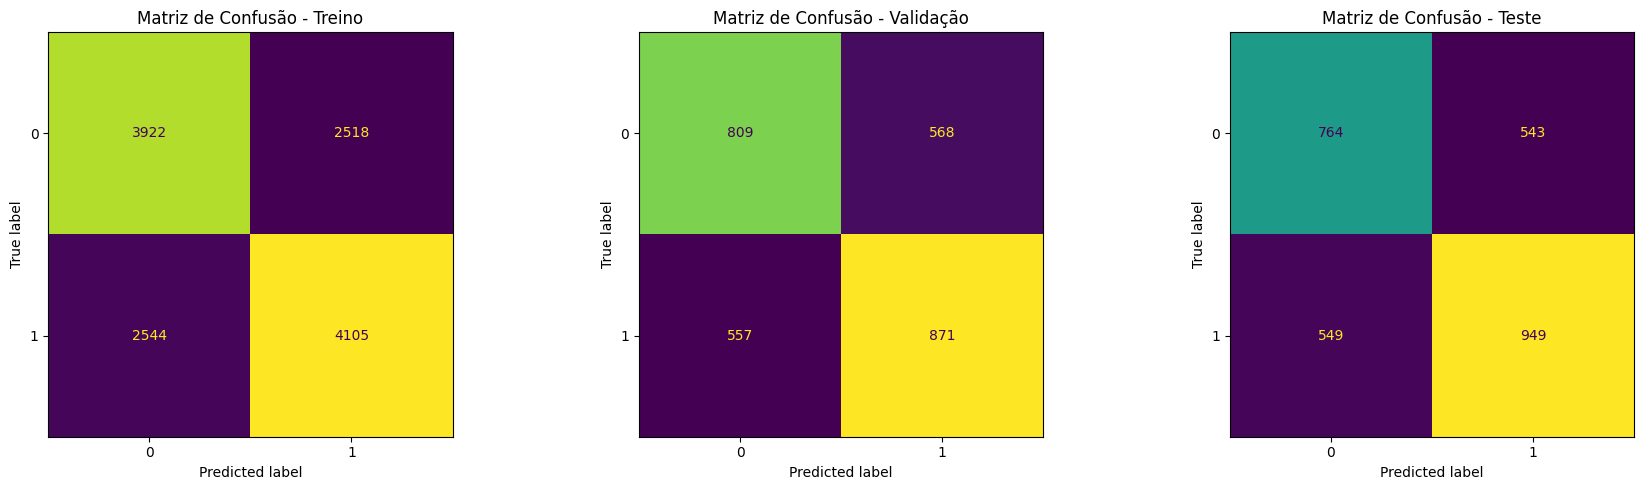


CLASSIFICATION REPORT - Treino
              precision    recall  f1-score   support

           0     0.6066    0.6090    0.6078      6440
           1     0.6198    0.6174    0.6186      6649

    accuracy                         0.6133     13089
   macro avg     0.6132    0.6132    0.6132     13089
weighted avg     0.6133    0.6133    0.6133     13089


CLASSIFICATION REPORT - Validação
              precision    recall  f1-score   support

           0     0.5922    0.5875    0.5899      1377
           1     0.6053    0.6099    0.6076      1428

    accuracy                         0.5989      2805
   macro avg     0.5988    0.5987    0.5987      2805
weighted avg     0.5989    0.5989    0.5989      2805


CLASSIFICATION REPORT - Teste
              precision    recall  f1-score   support

           0     0.5819    0.5845    0.5832      1307
           1     0.6361    0.6335    0.6348      1498

    accuracy                         0.6107      2805
   macro avg     0.6090    0.6

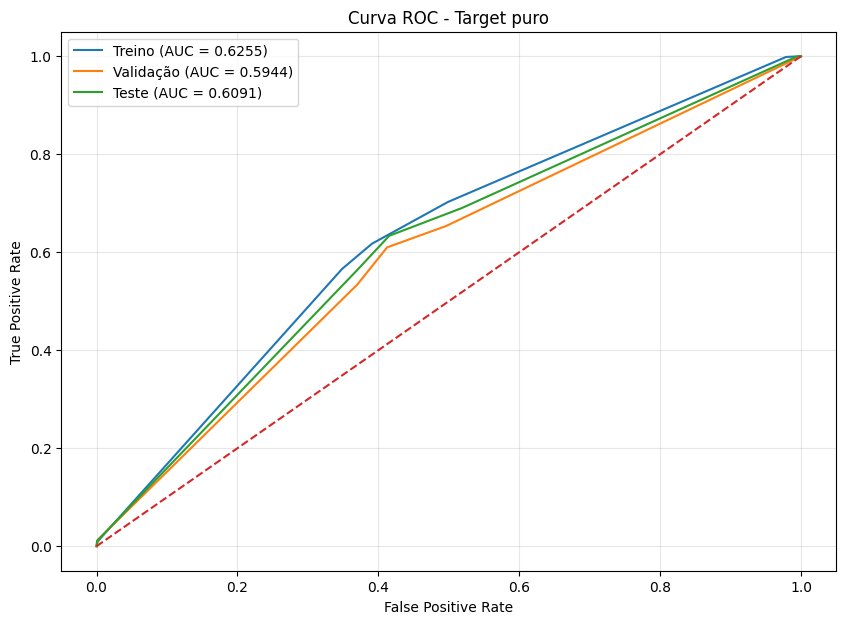

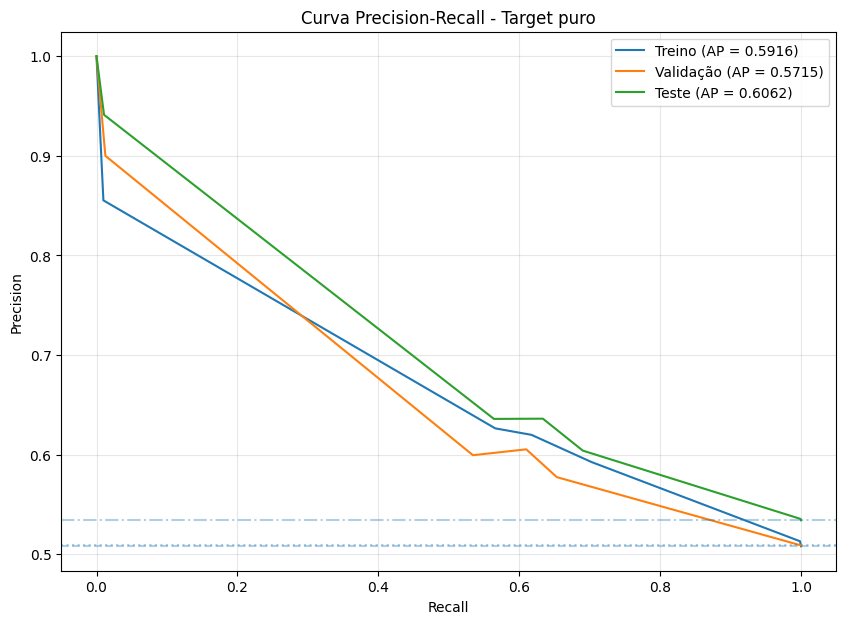


Top features por gain:
                       feature  importance_gain  importance_split
0                        dir_1       670.312988                 1
1              dist_bricks_ma9        84.510199                 3
2      lift_prob_down_h1_ma200        14.342600                 1
3                   above_ma_9         0.000000                 0
4       bullish_horizons_ma200         0.000000                 0
5           classe_score_ma200         0.000000                 0
6             dir_atual_h2_ma9         0.000000                 0
7           dir_atual_h3_ma200         0.000000                 0
8           dir_atual_h1_ma200         0.000000                 0
9           dir_atual_h2_ma200         0.000000                 0
10          dir_atual_h5_ma200         0.000000                 0
11            dir_atual_h3_ma9         0.000000                 0
12            dir_atual_h5_ma9         0.000000                 0
13                  dir_mean_3         0.000000     

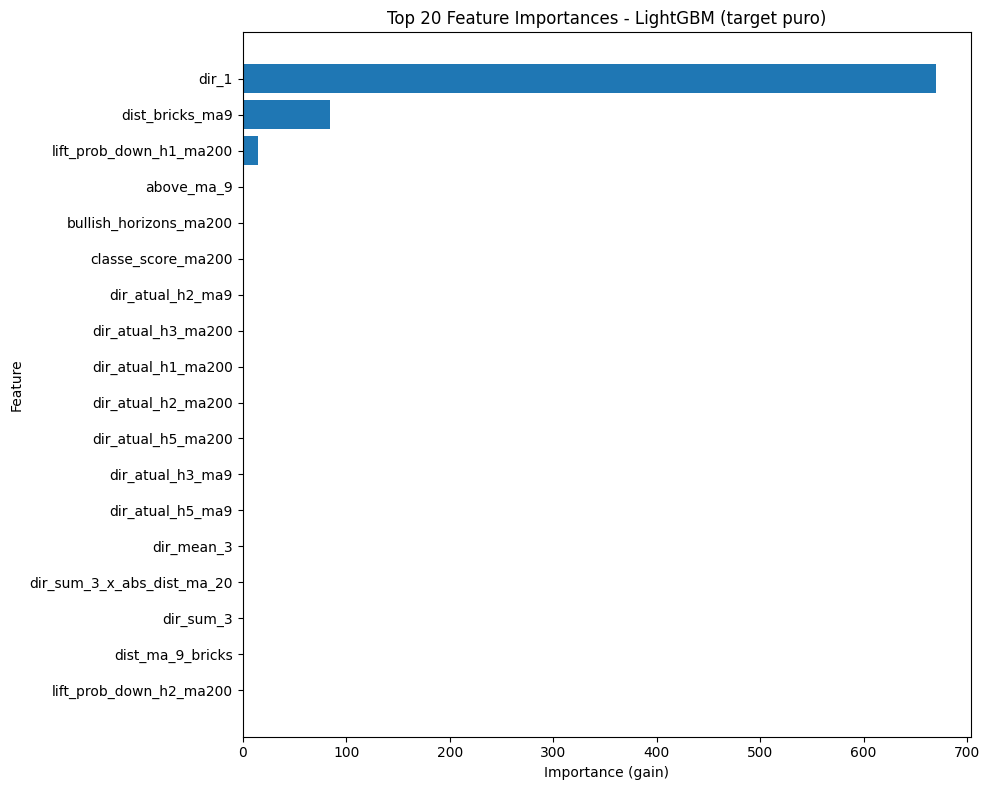

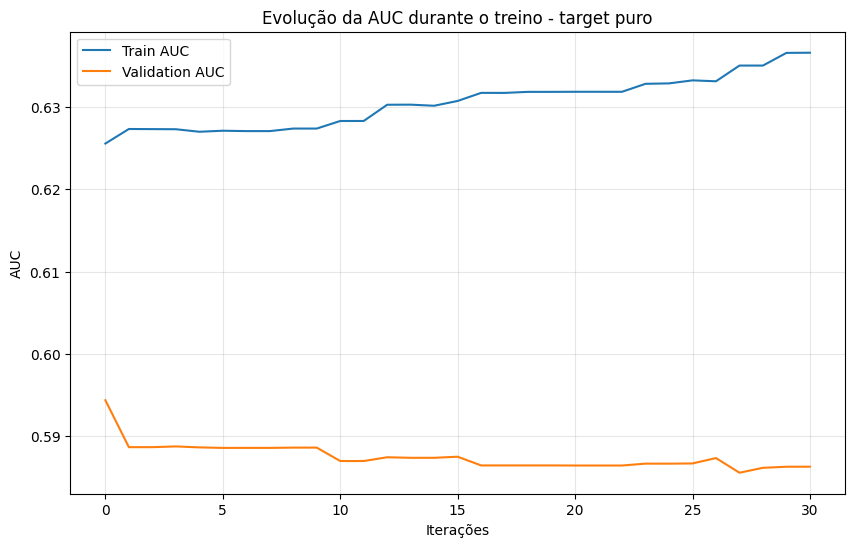

In [45]:
# TREINAMENTO DO MODELO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    classification_report
)

# =========================================================
# 0) CONFIGURAÇÕES INICIAIS
# =========================================================

#FEATURES = [col for col in df_final.columns if col not in ["target_bin", "soma_dir_futura_3", "Open", "Close", "High", "Low"]]

'''top_n = 2
selected_features = importance_df["feature"].head(top_n).tolist()
print(selected_features)'''

TARGET_COL = "target_bin"
#TARGET_INV_COL = "target_inv"

RANDOM_STATE = 42
#FEATURES = features  # precisa existir previamente
#FEATURES =  features_lista #selected_features  #features #feats2
#FEATURES =  features_lista4 #selected_features  #features #feats2
#FEATURES =  feats2
FEATURES =  features

# =========================================================
# 1) CRIAÇÃO DO TARGET BINÁRIO "PURO"
# =========================================================
# 1 = próximos 3 bricks todos de alta
# 0 = próximos 3 bricks todos de baixa
# Casos mistos são descartados

df_model = df_out.copy()

'''# direção do brick atual
df_model["dir_brick"] = np.where(df_model["Close"] > df_model["Open"], 1, -1)

# soma dos próximos 3 bricks, sem contar o atual
df_model["soma_dir_futura_3"] = (
    df_model["dir_brick"][::-1]
    .rolling(window=3, min_periods=3)
    .sum()[::-1]
    .shift(-1)
)

# mantém apenas os casos "puros": +3 ou -3
df_model = df_model[df_model["soma_dir_futura_3"].isin([3, -3])].copy()

# target binário puro
df_model[TARGET_COL] = np.where(df_model["soma_dir_futura_3"] == 3, 1, 0)

# limpa NaN / inf
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna().copy()'''

# =========================================================
# 2) DIAGNÓSTICO DO TARGET
# =========================================================

print("Distribuição do target binário puro (0/1):")
print(df_model[TARGET_COL].value_counts(dropna=False).sort_index())

print("\nDistribuição percentual do target binário puro:")
print(df_model[TARGET_COL].value_counts(normalize=True, dropna=False).sort_index())

print("\nQuantidade total de linhas após filtrar casos puros:")
print(len(df_model))

if df_model[TARGET_COL].nunique() < 2:
    raise ValueError(
        "O target possui menos de 2 classes no dataset inteiro. "
        "Revise a regra de criação do target."
    )

# =========================================================
# 3) CHECAGEM DE COLUNAS
# =========================================================

missing_cols = [c for c in FEATURES + [TARGET_COL] if c not in df_model.columns]
if missing_cols:
    raise ValueError(f"As seguintes colunas não existem em df_model: {missing_cols}")

# =========================================================
# 4) PREPARAÇÃO DOS DADOS
# =========================================================

data = df_model[FEATURES + [TARGET_COL, "Close", "High", "Low"]].copy()
data = data.replace([np.inf, -np.inf], np.nan).dropna().copy()

unique_targets = sorted(data[TARGET_COL].unique())
if not set(unique_targets).issubset({0, 1}):
    raise ValueError(
        f"O alvo precisa conter apenas 0 e 1. Valores encontrados: {unique_targets}"
    )

X = data[FEATURES].copy()
y = data[TARGET_COL].astype(int).copy()
close_all = data["Close"].copy() if "Close" in data.columns else None
high_all = data["High"].copy() if "High" in data.columns else None
low_all = data["Low"].copy() if "Low" in data.columns else None

print("\nShape final após dropna:", data.shape)
print("\nDistribuição do alvo final:")
print(y.value_counts(dropna=False).sort_index())

print("\nDistribuição percentual do alvo final:")
print(y.value_counts(normalize=True, dropna=False).sort_index())

# =========================================================
# 5) SPLIT TEMPORAL: 70% treino, 15% validação, 15% teste
# =========================================================

n = len(data)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end].copy()
y_train = y.iloc[:train_end].copy()
close_train = close_all.iloc[:train_end].copy() if close_all is not None else None
high_train = high_all.iloc[:train_end].copy() if high_all is not None else None
low_train = low_all.iloc[:train_end].copy() if low_all is not None else None

X_val = X.iloc[train_end:val_end].copy()
y_val = y.iloc[train_end:val_end].copy()
close_val = close_all.iloc[train_end:val_end].copy() if close_all is not None else None
high_val = high_all.iloc[train_end:val_end].copy() if high_all is not None else None
low_val = low_all.iloc[train_end:val_end].copy() if low_all is not None else None

X_test = X.iloc[val_end:].copy()
y_test = y.iloc[val_end:].copy()
close_test = close_all.iloc[val_end:].copy() if close_all is not None else None
high_test = high_all.iloc[val_end:].copy() if high_all is not None else None
low_test = low_all.iloc[val_end:].copy() if low_all is not None else None

print("\nTamanhos dos conjuntos:")
print(f"Treino:    {len(X_train)}")
print(f"Validação: {len(X_val)}")
print(f"Teste:     {len(X_test)}")

print("\nDistribuição do alvo por conjunto:")

print("\nTreino:")
print(y_train.value_counts(dropna=False).sort_index())
print(y_train.value_counts(normalize=True, dropna=False).sort_index())

print("\nValidação:")
print(y_val.value_counts(dropna=False).sort_index())
print(y_val.value_counts(normalize=True, dropna=False).sort_index())

print("\nTeste:")
print(y_test.value_counts(dropna=False).sort_index())
print(y_test.value_counts(normalize=True, dropna=False).sort_index())

if y_train.nunique() < 2:
    raise ValueError(
        "O conjunto de treino possui menos de 2 classes. "
        "Assim o modelo binário não terá aprendizado útil."
    )

# =========================================================
# 6) BALANCEAMENTO
# =========================================================

n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()

if n_pos == 0:
    raise ValueError("O conjunto de treino não possui classe positiva.")

scale_pos_weight = n_neg / n_pos
print(f"\nscale_pos_weight: {scale_pos_weight:.4f}")

# =========================================================
# 7) MODELO LIGHTGBM BINÁRIO
# =========================================================

'''model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=75,
    learning_rate=0.08,
    num_leaves=7,
    max_depth=3,
    min_child_samples=50,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)'''

model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=75,
    learning_rate=0.05,
    num_leaves=7,
    max_depth=3,
    min_child_samples=50,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=1.0,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
    
)

'''model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=75,
    learning_rate=0.1,
    num_leaves=7,
    max_depth=3,
    min_child_samples=50,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=1.0,
    class_weight="balanced",
    #scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1, 
    
)'''

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=["train", "valid"],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(stopping_rounds=30),
        lgb.log_evaluation(period=25)
    ]
)

best_iter = model.best_iteration_
print(f"\nMelhor iteração: {best_iter}")

# =========================================================
# 8) PROBABILIDADES
# =========================================================

train_proba = model.predict_proba(X_train, num_iteration=best_iter)[:, 1]
val_proba   = model.predict_proba(X_val,   num_iteration=best_iter)[:, 1]
test_proba  = model.predict_proba(X_test,  num_iteration=best_iter)[:, 1]

# =========================================================
# 9) ESCOLHA DE THRESHOLD PELA BALANCED ACCURACY
# =========================================================

thresholds = np.arange(0.05, 0.96, 0.01)

best_threshold = 0.50
best_score = -1

for thr in thresholds:
    y_val_pred_tmp = (val_proba >= thr).astype(int)
    score = balanced_accuracy_score(y_val, y_val_pred_tmp)
    if score > best_score:
        best_score = score
        best_threshold = thr

chosen_threshold = 0.50 #0.51

print(f"\nThreshold fixo escolhido: {chosen_threshold:.2f}")

'''print(f"\nMelhor threshold por balanced_accuracy: {best_threshold:.2f}")
print(f"Melhor balanced_accuracy na validação: {best_score:.4f}")'''

# =========================================================
# 10) PREDIÇÕES FINAIS
# =========================================================


y_train_pred = (train_proba >= chosen_threshold).astype(int)
y_val_pred   = (val_proba   >= chosen_threshold).astype(int)
y_test_pred  = (test_proba  >= chosen_threshold).astype(int)

'''y_train_pred = (train_proba >= best_threshold).astype(int)
y_val_pred   = (val_proba   >= best_threshold).astype(int)
y_test_pred  = (test_proba  >= best_threshold).astype(int)'''

# =========================================================
# 11) MÉTRICAS
# =========================================================

def safe_auc(y_true, y_proba):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_proba)

def safe_ap(y_true, y_proba):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, y_proba)

def compute_metrics(y_true, y_pred, y_proba, nome):
    return {
        "conjunto": nome,
        "threshold": best_threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "roc_auc": safe_auc(y_true, y_proba),
        "avg_precision": safe_ap(y_true, y_proba),
        "n_obs": len(y_true),
        "positivos_reais": int((y_true == 1).sum()),
        "negativos_reais": int((y_true == 0).sum()),
        "positivos_preditos": int((y_pred == 1).sum()),
        "negativos_preditos": int((y_pred == 0).sum()),
    }

metrics_df = pd.DataFrame([
    compute_metrics(y_train, y_train_pred, train_proba, "Treino"),
    compute_metrics(y_val,   y_val_pred,   val_proba,   "Validação"),
    compute_metrics(y_test,  y_test_pred,  test_proba,  "Teste"),
])

print("\nMÉTRICAS FINAIS")
print(metrics_df)

# =========================================================
# 12) MATRIZES DE CONFUSÃO
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    ("Treino", y_train, y_train_pred),
    ("Validação", y_val, y_val_pred),
    ("Teste", y_test, y_test_pred),
]

for ax, (nome, y_true, y_pred) in zip(axes, datasets):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Matriz de Confusão - {nome}")

plt.tight_layout()
plt.show()

# =========================================================
# 13) CLASSIFICATION REPORT
# =========================================================

for nome, y_true, y_pred in datasets:
    print(f"\n{'='*70}")
    print(f"CLASSIFICATION REPORT - {nome}")
    print(f"{'='*70}")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))

# =========================================================
# 14) CURVA ROC
# =========================================================

plt.figure(figsize=(10, 7))

if len(np.unique(y_train)) >= 2:
    fpr_train, tpr_train, _ = roc_curve(y_train, train_proba)
    auc_train = roc_auc_score(y_train, train_proba)
    plt.plot(fpr_train, tpr_train, label=f"Treino (AUC = {auc_train:.4f})")

if len(np.unique(y_val)) >= 2:
    fpr_val, tpr_val, _ = roc_curve(y_val, val_proba)
    auc_val = roc_auc_score(y_val, val_proba)
    plt.plot(fpr_val, tpr_val, label=f"Validação (AUC = {auc_val:.4f})")

if len(np.unique(y_test)) >= 2:
    fpr_test, tpr_test, _ = roc_curve(y_test, test_proba)
    auc_test = roc_auc_score(y_test, test_proba)
    plt.plot(fpr_test, tpr_test, label=f"Teste (AUC = {auc_test:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Target puro")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# 15) CURVA PRECISION-RECALL
# =========================================================

plt.figure(figsize=(10, 7))

if len(np.unique(y_train)) >= 2:
    prec_train, rec_train, _ = precision_recall_curve(y_train, train_proba)
    ap_train = average_precision_score(y_train, train_proba)
    plt.plot(rec_train, prec_train, label=f"Treino (AP = {ap_train:.4f})")
    plt.axhline(y_train.mean(), linestyle="--", alpha=0.35)

if len(np.unique(y_val)) >= 2:
    prec_val, rec_val, _ = precision_recall_curve(y_val, val_proba)
    ap_val = average_precision_score(y_val, val_proba)
    plt.plot(rec_val, prec_val, label=f"Validação (AP = {ap_val:.4f})")
    plt.axhline(y_val.mean(), linestyle=":", alpha=0.35)

if len(np.unique(y_test)) >= 2:
    prec_test, rec_test, _ = precision_recall_curve(y_test, test_proba)
    ap_test = average_precision_score(y_test, test_proba)
    plt.plot(rec_test, prec_test, label=f"Teste (AP = {ap_test:.4f})")
    plt.axhline(y_test.mean(), linestyle="-.", alpha=0.35)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Target puro")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# 16) FEATURE IMPORTANCE
# =========================================================

importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance_gain": model.booster_.feature_importance(importance_type="gain"),
    "importance_split": model.booster_.feature_importance(importance_type="split"),
})

importance_df = importance_df.sort_values("importance_gain", ascending=False).reset_index(drop=True)

print("\nTop features por gain:")
print(importance_df.head(20))

plt.figure(figsize=(10, 8))
plt.barh(
    importance_df["feature"].iloc[:20][::-1],
    importance_df["importance_gain"].iloc[:20][::-1]
)
plt.xlabel("Importance (gain)")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances - LightGBM (target puro)")
plt.tight_layout()
plt.show()

# =========================================================
# 17) EVOLUÇÃO DA AUC
# =========================================================

evals_result = model.evals_result_

plt.figure(figsize=(10, 6))
plt.plot(evals_result["train"]["auc"], label="Train AUC")
plt.plot(evals_result["valid"]["auc"], label="Validation AUC")
plt.xlabel("Iterações")
plt.ylabel("AUC")
plt.title("Evolução da AUC durante o treino - target puro")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## BACKTEST BASELINE - UTILIZA APENAS A PREVISÃO DIRECIONAL DO MODELO PRINCIPAL

📊 RESULTADO DO BACKTEST - ESTRATÉGIA APENAS DIRECIONAL
📈 Total de Trades: 11595
✅ Trades Vencedores: 6558 (56.6%)
❌ Trades Perdedores: 5037
💰 Lucro Total: R$ 9,407,425.00
📊 Retorno Total: 94074.25%
📊 Lucro Médio por Trade: R$ 811.33
💚 Lucro Médio (Winners): R$ 2,493.12
💔 Perda Média (Losers): R$ -1,378.29
⚖️  Risk/Reward: 1.81
📈 Sharpe Ratio: 5.121
📉 Máximo Drawdown: R$ -43,125.00 (-0.5%)
🏁 Capital Inicial: R$ 10,000.00
🏁 Capital Final: R$ 9,417,425.00

📋 Análise por Tipo de Saída:
                     count        sum     mean
motivo_saida                                  
Fechamento Daytrade   8688  9275325.0  1067.60
Reversão              2890    79350.0    27.46
Stop                    17    52750.0  3102.94


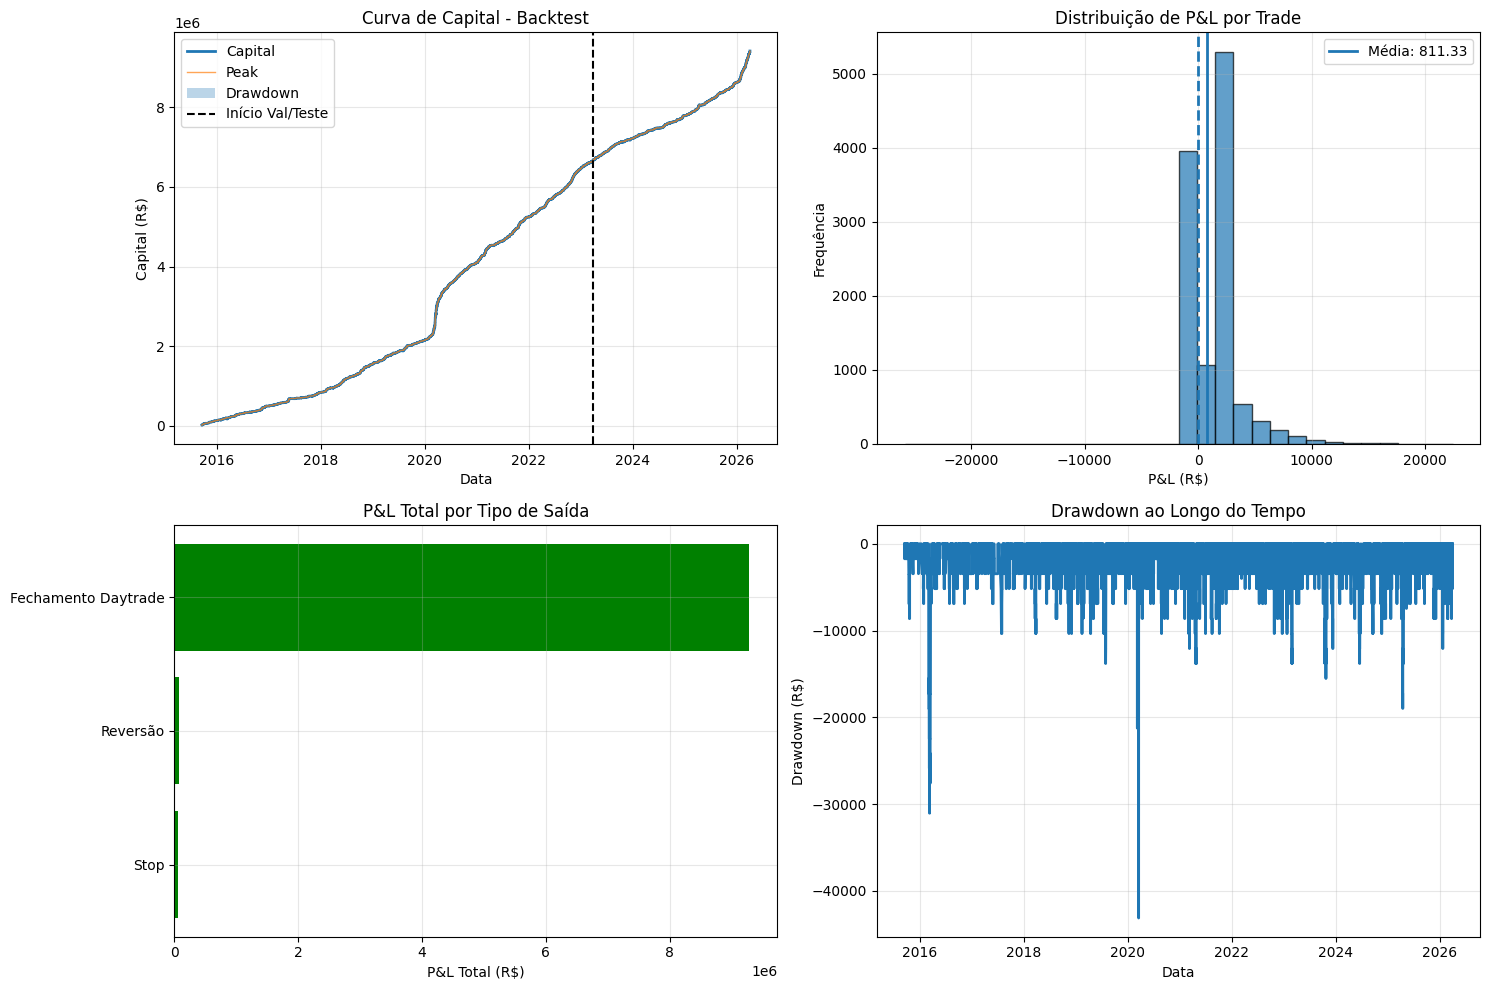


📊 Distribuição de Sinais:
prediction
0    9145
1    9553
Name: count, dtype: int64

📊 Distribuição de Posições:
posicao
-1    4802
 0    8705
 1    5191
Name: count, dtype: int64

🗓️ Dias negociados: 2506

📅 Dias (P&L consolidado por dia):
Dias positivos             Dias negativos
17/09/2015 R$ 1.725,00     16/09/2015 -R$ 1.725,00
18/09/2015 R$ 8.625,00     28/09/2015 -R$ 1.725,00
21/09/2015 R$ 1.725,00     15/10/2015 -R$ 1.725,00
22/09/2015 R$ 5.175,00     16/10/2015 -R$ 3.450,00
23/09/2015 R$ 3.450,00     20/10/2015 -R$ 1.725,00
24/09/2015 R$ 6.900,00     29/10/2015 -R$ 1.725,00
25/09/2015 R$ 3.450,00     11/11/2015 -R$ 1.725,00
01/10/2015 R$ 1.725,00     13/11/2015 -R$ 1.725,00
02/10/2015 R$ 6.900,00     24/11/2015 -R$ 1.725,00
05/10/2015 R$ 3.450,00     01/12/2015 -R$ 1.725,00
07/10/2015 R$ 3.450,00     14/12/2015 -R$ 1.725,00
13/10/2015 R$ 5.175,00     23/12/2015 -R$ 1.725,00
22/10/2015 R$ 5.175,00     14/01/2016 -R$ 1.725,00
23/10/2015 R$ 1.725,00     18/01/2016 -R$ 1.725,00
26/

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time

# =========================
# Parâmetros do backtest
# =========================
VALOR_POR_PONTO = 0.20     # R$ por ponto
STOP_PONTOS     = 800       # distância fixa do stop em pontos (ajuste aqui)
SLIPPAGE        = 0.0      # em pontos (aplicado na entrada/saída)
CUSTO_OPERACAO  = 0.0      # custo por operação (R$), debitado em cada fechamento de trade
CAPITAL_INICIAL = 10000.0  # ajuste conforme quiser
HORA_FECHAMENTO = time(12, 0)  # encerrar posição até as 18:00 (inclusive)
NUM_CONTRATOS   = 25        # número fixo de contratos (ajuste aqui)

# =========================
# Prep dos dados
# =========================
# Usa o mesmo dataset do treino (X/y) + OHLC de df_mkt

df_test = df_out.copy()

df_test["Date"] = pd.to_datetime(df_test["Date"])

df_test = df_test.sort_values("Date").reset_index(drop=True)

df_test["date_only"] = df_test["Date"].dt.date

df_test["time_only"] = df_test["Date"].dt.time


# Gera sinais a partir do modelo treinado

pred_class = model.predict(X)

df_test["prediction"] = pred_class


# Mapeamento das classes para direção do trade

classes_ = set(getattr(model, "classes_", []))

if classes_ >= {0, 1, 2}:

    sig_dir = np.where(pred_class == 1, 1, np.where(pred_class == 2, -1, 0))
    #sig_dir = np.where(pred_class == 1, -1, np.where(pred_class == 2, 1, 0))

else:

    # binário: 1 = long, 0 = short

    sig_dir = np.where(pred_class == 1, 1, -1)


df_test["sig_prev"] = pd.Series(sig_dir).shift(1)  # válido para o candle atual


# contratos fixos para todos os candles
size_series = pd.Series(NUM_CONTRATOS, index=df_test.index)

df_test["size_prev"] = size_series.shift(1)                   # contratos do candle do sinal

df_test["open_prev"] = df_test["Open"].shift(1)                     # abertura do candle do sinal (âncora do stop)

df_test["is_last_candle_day"] = df_test["date_only"] != df_test["date_only"].shift(-1)


# Marca o início da validação (treino termina aqui)

val_start_date = None

try:

    if "idx_val" in globals():

        val_start_idx = int(np.min(idx_val))

    elif "X_train" in globals():

        val_start_idx = int(len(X_train))

    else:

        val_start_idx = None

    if val_start_idx is not None and 0 <= val_start_idx < len(df_test):

        val_start_date = pd.to_datetime(df_test.loc[val_start_idx, "Date"])

except Exception:

    val_start_date = None


# tira primeira linha inválida por causa do shift

df_test = df_test.dropna(subset=["sig_prev", "size_prev", "open_prev"]).reset_index(drop=True)

# =========================
# Estado do backtest
# =========================
capital = CAPITAL_INICIAL
pos = 0                 # 0=flat, 1=long, -1=short
qty = 0                 # contratos
entry_price = np.nan
entry_time  = None
stop_level  = np.nan
entry_ref_open = np.nan # abertura do candle de sinal (para referência/checagem)

historico_trades = []

equity_curve = []
position_vec = []
entry_price_vec = []
stop_level_vec = []

# =========================
# Funções auxiliares
# =========================
def apply_slippage(price, side, slippage_points):
    # side:  1 = compra, -1 = venda  (slippage “contra” você)
    if slippage_points == 0:
        return price
    return price + (slippage_points if side == 1 else -slippage_points)

def trade_pl(exit_price, entry_price, side, contracts):
    # P&L em R$
    pontos = (exit_price - entry_price) * side
    return pontos * VALOR_POR_PONTO * contracts

# =========================
# Loop principal
# =========================
for i, row in df_test.iterrows():
    dt   = row["Date"]
    d    = row["date_only"]
    t    = row["time_only"]
    o    = float(row["Open"])
    h    = float(row["High"])
    l    = float(row["Low"])
    c    = float(row["Close"])

    sig  = int(row["sig_prev"])        # sinal válido para ESTE candle (veio do anterior)
    lot  = int(row["size_prev"])       # sizing do candle do sinal
    oref = float(row["open_prev"])     # abertura do candle do sinal (âncora do stop)

    # 1) Se há posição e o novo sinal reverte, fechar no Open e abrir no Open (mesmo candle)
    if pos != 0 and sig != pos:
        exit_price = apply_slippage(o, -pos, SLIPPAGE)
        pl = trade_pl(exit_price, entry_price, pos, qty) - CUSTO_OPERACAO
        capital += pl
        historico_trades.append({
            'data_entrada': entry_time,
            'data_saida': dt,
            'tipo': 'Compra' if pos == 1 else 'Venda',
            'contratos': qty,
            'preco_entrada': entry_price,
            'preco_saida': exit_price,
            'retorno_pontos': (exit_price - entry_price) * pos,
            'pl': pl,
            'motivo_saida': 'Reversão'
        })
        # abrir nova posição
        pos = sig
        qty = lot
        entry_price = apply_slippage(o, pos, SLIPPAGE)
        entry_time = dt
        entry_ref_open = oref
        stop_level = (oref - STOP_PONTOS) if pos == 1 else (oref + STOP_PONTOS)

    # 2) Se não há posição, abrir se houver sinal
    elif pos == 0 and sig in (1, -1):
        pos = sig
        qty = lot
        entry_price = apply_slippage(o, pos, SLIPPAGE)
        entry_time = dt
        entry_ref_open = oref
        stop_level = (oref - STOP_PONTOS) if pos == 1 else (oref + STOP_PONTOS)

    # 3) Se há posição, checar STOP intrabar via OHLC
    if pos != 0:
        # prioridade: stop intrabar
        if pos == 1 and l <= stop_level:
            exit_price = apply_slippage(stop_level, -pos, SLIPPAGE)
            pl = trade_pl(exit_price, entry_price, pos, qty) - CUSTO_OPERACAO
            capital += pl
            historico_trades.append({
                'data_entrada': entry_time,
                'data_saida': dt,
                'tipo': 'Compra',
                'contratos': qty,
                'preco_entrada': entry_price,
                'preco_saida': exit_price,
                'retorno_pontos': (exit_price - entry_price),
                'pl': pl,
                'motivo_saida': 'Stop'
            })
            pos = 0; qty = 0; entry_price = np.nan; entry_time = None; stop_level = np.nan

        elif pos == -1 and h >= stop_level:
            exit_price = apply_slippage(stop_level, -pos, SLIPPAGE)
            pl = trade_pl(exit_price, entry_price, pos, qty) - CUSTO_OPERACAO
            capital += pl
            historico_trades.append({
                'data_entrada': entry_time,
                'data_saida': dt,
                'tipo': 'Venda',
                'contratos': qty,
                'preco_entrada': entry_price,
                'preco_saida': exit_price,
                'retorno_pontos': (entry_price - exit_price),
                'pl': pl,
                'motivo_saida': 'Stop'
            })
            pos = 0; qty = 0; entry_price = np.nan; entry_time = None; stop_level = np.nan

    # 4) Fechamento obrigatório do dia (18:00) — se ainda em posição
    if pos != 0 and (t >= HORA_FECHAMENTO or row["is_last_candle_day"]):
        # fecha no Open do PRÓXIMO candle se existir; como estamos no último do dia,
        # fechamos no Close atual (ou no Open atual se preferir). Aqui optei pelo Close atual.
        # Se quiser forçar no Open desse candle, troque para apply_slippage(o, -pos, SLIPPAGE).
        exit_price = apply_slippage(c, -pos, SLIPPAGE)
        pl = trade_pl(exit_price, entry_price, pos, qty) - CUSTO_OPERACAO
        capital += pl
        historico_trades.append({
            'data_entrada': entry_time,
            'data_saida': dt,
            'tipo': 'Compra' if pos == 1 else 'Venda',
            'contratos': qty,
            'preco_entrada': entry_price,
            'preco_saida': exit_price,
            'retorno_pontos': (exit_price - entry_price) * pos,
            'pl': pl,
            'motivo_saida': 'Fechamento Daytrade'
        })
        pos = 0; qty = 0; entry_price = np.nan; entry_time = None; stop_level = np.nan

    # 5) salvar séries
    equity_curve.append(capital)
    position_vec.append(pos)
    entry_price_vec.append(entry_price if pos != 0 else np.nan)
    stop_level_vec.append(stop_level if pos != 0 else np.nan)

# Se sobrou posição aberta no final da série (não deve, mas por garantia), fecha a mercado no último Close
if pos != 0:
    last_close = float(df_test.iloc[-1]["Close"])
    last_dt    = df_test.iloc[-1]["Date"]
    exit_price = apply_slippage(last_close, -pos, SLIPPAGE)
    pl = trade_pl(exit_price, entry_price, pos, qty) - CUSTO_OPERACAO
    capital += pl
    historico_trades.append({
        'data_entrada': entry_time,
        'data_saida': last_dt,
        'tipo': 'Compra' if pos == 1 else 'Venda',
        'contratos': qty,
        'preco_entrada': entry_price,
        'preco_saida': exit_price,
        'retorno_pontos': (exit_price - entry_price) * pos,
        'pl': pl,
        'motivo_saida': 'Fechamento Série'
    })
    pos = 0; qty = 0; entry_price = np.nan; entry_time = None; stop_level = np.nan

# =========================
# Resultados e Métricas
# =========================
df_test["capital"] = equity_curve
df_test["posicao"] = position_vec
df_test["preco_entrada"] = entry_price_vec
df_test["stop_atual"] = stop_level_vec

df_historico = pd.DataFrame(historico_trades)

if len(df_historico) > 0:
    # Métricas básicas
    total_trades = len(df_historico)
    trades_vencedores = (df_historico['pl'] > 0).sum()
    trades_perdedores = (df_historico['pl'] <= 0).sum()
    win_rate = (trades_vencedores / total_trades * 100) if total_trades > 0 else 0.0

    # Performance
    total_pl = df_historico['pl'].sum()
    mean_pl  = df_historico['pl'].mean()
    std_pl   = df_historico['pl'].std(ddof=1)

    # Risco/Retorno
    lucro_medio = df_historico.loc[df_historico['pl'] > 0, 'pl'].mean() if trades_vencedores > 0 else 0.0
    perda_media = df_historico.loc[df_historico['pl'] <= 0, 'pl'].mean() if trades_perdedores > 0 else 0.0
    risk_reward = (abs(lucro_medio / perda_media) if perda_media < 0 else np.nan)

    # Sharpe por trade (anualizado por 252 pregões como proxy)
    sharpe = (mean_pl / std_pl * np.sqrt(252)) if std_pl and std_pl > 0 else np.nan

    # Drawdown em capital realizado
    df_test["peak"] = df_test["capital"].cummax()
    df_test["drawdown"] = df_test["capital"] - df_test["peak"]
    max_dd = df_test["drawdown"].min()
    max_dd_pct = (max_dd / df_test["peak"].max()) * 100 if df_test["peak"].max() else np.nan

    capital_inicial = CAPITAL_INICIAL
    capital_final = df_test["capital"].iloc[-1]
    retorno_total = ((capital_final - capital_inicial) / capital_inicial) * 100

    # Resumo por motivo de saída
    saidas_summary = (
        df_historico.groupby('motivo_saida')['pl']
        .agg(['count', 'sum', 'mean'])
        .round(2)
        .sort_values('sum', ascending=False)
    )

    # =========================
    # Relatório (formato que você mostrou)
    # =========================
    print("="*70)
    print("📊 RESULTADO DO BACKTEST - ESTRATÉGIA APENAS DIRECIONAL")
    print("="*70)
    print(f"📈 Total de Trades: {total_trades}")
    print(f"✅ Trades Vencedores: {trades_vencedores} ({win_rate:.1f}%)")
    print(f"❌ Trades Perdedores: {trades_perdedores}")
    print(f"💰 Lucro Total: R$ {total_pl:,.2f}")
    print(f"📊 Retorno Total: {retorno_total:.2f}%")
    print(f"📊 Lucro Médio por Trade: R$ {mean_pl:,.2f}")
    print(f"💚 Lucro Médio (Winners): R$ {lucro_medio:,.2f}")
    print(f"💔 Perda Média (Losers): R$ {perda_media:,.2f}")
    print(f"⚖️  Risk/Reward: {risk_reward:.2f}")
    print(f"📈 Sharpe Ratio: {sharpe:.3f}")
    print(f"📉 Máximo Drawdown: R$ {max_dd:,.2f} ({max_dd_pct:.1f}%)")
    print(f"🏁 Capital Inicial: R$ {capital_inicial:,.2f}")
    print(f"🏁 Capital Final: R$ {capital_final:,.2f}\n")

    print("📋 Análise por Tipo de Saída:")
    if not saidas_summary.empty:
        print(saidas_summary)
    else:
        print("Nenhum trade executado")

    # =========================
    # Gráficos
    # =========================
    plt.figure(figsize=(15, 10))

    # 1) Curva de Capital
    plt.subplot(2, 2, 1)
    plt.plot(df_test["Date"], df_test["capital"], label='Capital', linewidth=2)
    plt.plot(df_test["Date"], df_test["peak"], label='Peak', linewidth=1, alpha=0.7)
    plt.fill_between(df_test["Date"], df_test["peak"], df_test["capital"],
                     where=(df_test["capital"] < df_test["peak"]),
                     alpha=0.3, label='Drawdown')
    if val_start_date is not None:
        plt.axvline(val_start_date, color="black", linestyle="--", linewidth=1.5, label="Início Val/Teste")
        plt.title("Curva de Capital - Backtest")
        plt.xlabel("Data"); plt.ylabel("Capital (R$)")
        plt.grid(True, alpha=0.3); plt.legend()

    # 2) Distribuição de P&L dos trades
    plt.subplot(2, 2, 2)
    bins = max(10, min(30, len(df_historico)//2))
    plt.hist(df_historico['pl'], bins=bins, alpha=0.7, edgecolor='black')
    plt.axvline(x=0, linestyle='--', linewidth=2)
    plt.axvline(x=mean_pl, linestyle='-', linewidth=2, label=f'Média: {mean_pl:.2f}')
    plt.title("Distribuição de P&L por Trade")
    plt.xlabel("P&L (R$)"); plt.ylabel("Frequência")
    plt.grid(True, alpha=0.3); plt.legend()

    # 3) P&L por Motivo de Saída
    plt.subplot(2, 2, 3)
    motivos = df_historico.groupby('motivo_saida')['pl'].sum().sort_values()
    cores = ['red' if x < 0 else 'green' for x in motivos.values]
    plt.barh(motivos.index.astype(str), motivos.values, color=cores)
    plt.title("P&L Total por Tipo de Saída")
    plt.xlabel("P&L Total (R$)")
    plt.grid(True, alpha=0.3)

    # 4) Drawdown
    plt.subplot(2, 2, 4)
    plt.plot(df_test["Date"], df_test["drawdown"], linewidth=2)
    plt.fill_between(df_test["Date"], 0, df_test["drawdown"], alpha=0.3)
    plt.title("Drawdown ao Longo do Tempo")
    plt.xlabel("Data"); plt.ylabel("Drawdown (R$)")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    

# Extras: distribuição de sinais/posições
print(f"\n📊 Distribuição de Sinais:")
print(df_test['prediction'].value_counts().sort_index())
if 'posicao' in df_test.columns:
    print(f"\n📊 Distribuição de Posições:")
    print(pd.Series(df_test['posicao']).value_counts().sort_index())
    
    # =========================
    # NOVAS MÉTRICAS: visão por dia
    # =========================
    # Somar o P&L por dia (considera a data de saída do trade).
    df_historico['dia'] = pd.to_datetime(df_historico['data_saida']).dt.date
    pl_por_dia = (
        df_historico.groupby('dia')['pl']
        .sum()
        .sort_index()
    )

    dias_negociados = int(pl_por_dia.index.size)

    if dias_negociados > 0:
        # Melhor e pior dia (em R$)
        melhor_dia = pl_por_dia.idxmax()
        pior_dia   = pl_por_dia.idxmin()
        melhor_pl  = float(pl_por_dia.loc[melhor_dia])
        pior_pl    = float(pl_por_dia.loc[pior_dia])

       # =========================
    # LISTA DIÁRIA: positivos x negativos (lado a lado)
    # =========================
    # Consolidado por dia (usa a data de saída dos trades)
    df_historico['dia'] = pd.to_datetime(df_historico['data_saida']).dt.date
    pl_por_dia = (
        df_historico.groupby('dia')['pl']
        .sum()
        .sort_index()  # ordena por data; troque para sort_values() p/ ordenar por PL
    )

    dias_negociados = int(pl_por_dia.index.size)

    # Se quiser ignorar dias com PL=0 na listagem:
    pos_series = pl_por_dia[pl_por_dia > 0]
    neg_series = pl_por_dia[pl_por_dia < 0]

    def fmt_brl(v: float) -> str:
        # R$ com separadores pt-BR e sinal antes da moeda em caso de negativo
        s = f"R$ {abs(v):,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
        return s if v >= 0 else f"-{s}"

    pos_strs = [f"{d.strftime('%d/%m/%Y')} {fmt_brl(v)}" for d, v in pos_series.items()]
    neg_strs = [f"{d.strftime('%d/%m/%Y')} {fmt_brl(v)}" for d, v in neg_series.items()]

    colw = max([len("Dias positivos")] + [len(s) for s in pos_strs] + [20]) + 4

    print(f"\n🗓️ Dias negociados: {dias_negociados}")
    print("\n📅 Dias (P&L consolidado por dia):")
    print(f"{'Dias positivos'.ljust(colw)}Dias negativos")
    max_rows = max(len(pos_strs), len(neg_strs))
    for i in range(max_rows):
        left  = pos_strs[i] if i < len(pos_strs) else ""
        right = neg_strs[i] if i < len(neg_strs) else ""
        print(f"{left.ljust(colw)}{right}")
        
        
    # Melhor e pior dia (em R$)
    melhor_dia = pl_por_dia.idxmax()
    pior_dia   = pl_por_dia.idxmin()
    melhor_pl  = float(pl_por_dia.loc[melhor_dia])
    pior_pl    = float(pl_por_dia.loc[pior_dia])
    
    # Dar print com espaço
    print(f"\n{'Melhor Dia':<20}{'Valor (R$)':>15}    {'Pior Dia':<20}{'Valor (R$)':>15}")
    print(f"{str(melhor_dia):<20}{melhor_pl:>15,.2f}    {str(pior_dia):<20}{pior_pl:>15,.2f}")




## BACKTEST DO MODELO DIRECIONAL JUNTAMENTE COM O MODELO PROBABILÍSTICO DAS EXCURSÕES CONTRÁRIAS

📊 RESULTADO DO BACKTEST - MODELO DIRECIONAL + EXCURSÃO CONDICIONAL
📈 Total de Trades Fechados: 12194
✅ Trades Vencedores: 6677 (54.8%)
❌ Trades Perdedores: 5517
💰 Lucro Total: R$ 11,089,311.00
📊 Retorno Total: 110893.11%
📊 Lucro Médio por Trade: R$ 909.41
💚 Lucro Médio (Winners): R$ 2,549.08
💔 Perda Média (Losers): R$ -1,075.02
⚖️  Risk/Reward: 2.37
📈 Sharpe Ratio: 3.829
📉 Máximo Drawdown: R$ -33,505.65 (-0.3%)
🏁 Capital Inicial: R$ 10,000.00
🏁 Capital Final: R$ 11,099,311.00

📋 Análise por Tipo de Saída:
                     count         sum     mean
motivo_saida                                   
Fechamento Daytrade   7783  11266440.9  1447.57
Reversão              2268    489169.6   215.68
Stop                     1      -550.0  -550.00
Stop Percentil        2142   -665749.5  -310.81

📋 Resumo dos fills por camada:
  lado        motivo_fill  n_fills  contratos_total
Compra            Add p10     2824            36712
Compra            Add p25     5838            40866
Compra       

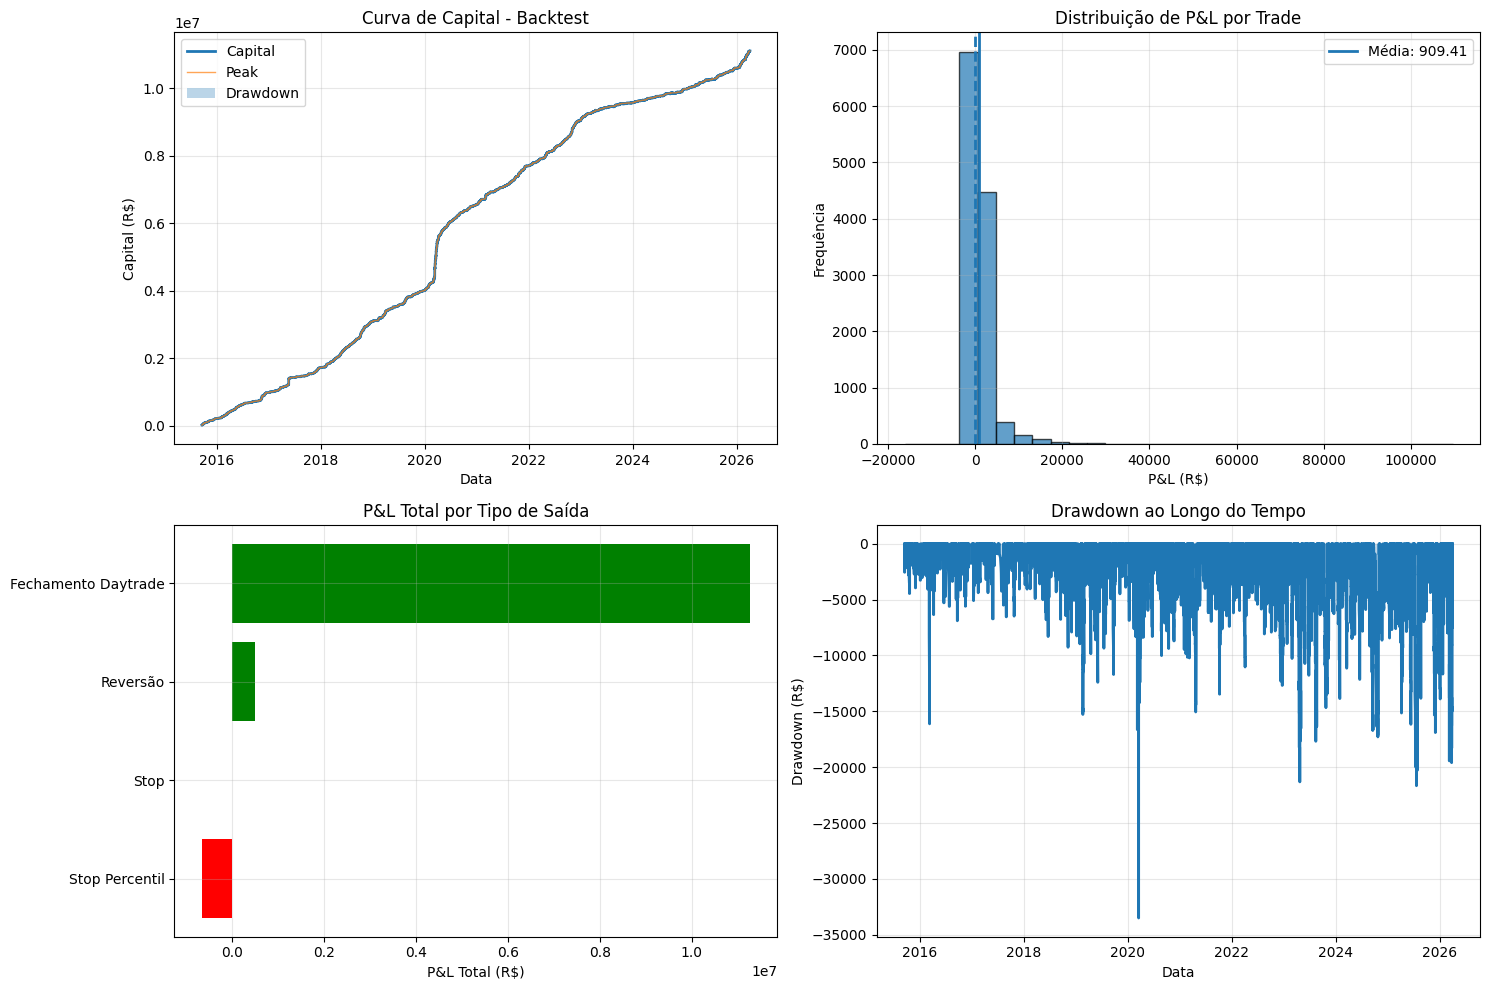


🗓️ Dias negociados: 2506

📅 Dias (P&L consolidado por dia):
Dias positivos              Dias negativos
17/09/2015 R$ 5.298,25      16/09/2015 -R$ 1.286,00
18/09/2015 R$ 8.483,75      05/10/2015 -R$ 1.600,60
21/09/2015 R$ 2.556,50      16/10/2015 -R$ 1.284,55
22/09/2015 R$ 469,60        20/10/2015 -R$ 2.090,75
23/09/2015 R$ 674,35        23/10/2015 -R$ 84,20
24/09/2015 R$ 12.172,30     29/10/2015 -R$ 592,20
25/09/2015 R$ 16.972,85     11/11/2015 -R$ 1.073,00
28/09/2015 R$ 2.820,00      13/11/2015 -R$ 604,65
30/09/2015 R$ 3.530,00      18/11/2015 -R$ 2.180,30
01/10/2015 R$ 5.395,00      23/11/2015 -R$ 332,85
02/10/2015 R$ 8.325,80      24/11/2015 -R$ 9,30
07/10/2015 R$ 6.041,15      30/11/2015 -R$ 2.244,30
09/10/2015 R$ 2.588,40      01/12/2015 -R$ 1.702,00
13/10/2015 R$ 9.441,00      08/12/2015 -R$ 1.671,20
14/10/2015 R$ 3.354,25      14/12/2015 -R$ 1.357,50
15/10/2015 R$ 1,75          21/12/2015 -R$ 1.581,20
22/10/2015 R$ 8.362,80      23/12/2015 -R$ 810,95
26/10/2015 R$ 3.829,00     

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import time


# =========================================================
# REFERÊNCIA CONDICIONAL DE EXCURSÃO
# =========================================================
def attach_conditional_excursion_levels(
    df,
    discrete_vars,
    y="future_mae_h1",
    train_frac=0.70,
    event_mode="between",
    threshold=None,
    lower=None,
    upper=None,
):
    """
    Aprende no treino os percentis condicionais de future_mae_h1
    por combinação exata das variáveis discretas e anexa ao dataframe
    inteiro as colunas:
      - exc_train_n
      - exc_train_prob_event
      - exc_p10_y
      - exc_p25_y
      - exc_p50_y
      - exc_p75_y
      - exc_p90_y
    """

    def make_event(series, mode="le", threshold=None, lower=None, upper=None):
        s = pd.to_numeric(series, errors="coerce")

        if mode == "le":
            if threshold is None:
                raise ValueError("Para mode='le', informe threshold.")
            return s <= threshold

        elif mode == "ge":
            if threshold is None:
                raise ValueError("Para mode='ge', informe threshold.")
            return s >= threshold

        elif mode == "between":
            if lower is None or upper is None:
                raise ValueError("Para mode='between', informe lower e upper.")
            return (s >= lower) & (s <= upper)

        elif mode == "abs_ge":
            if threshold is None:
                raise ValueError("Para mode='abs_ge', informe threshold.")
            return s.abs() >= threshold

        else:
            raise ValueError(f"Modo inválido: {mode}")

    needed_cols = list(dict.fromkeys(discrete_vars + [y, "Date", "Open", "High", "Low", "Close"]))
    data = df[needed_cols].copy()

    data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
    for c in [col for col in needed_cols if col != "Date"]:
        data[c] = pd.to_numeric(data[c], errors="coerce")

    data = data.dropna().sort_values("Date").reset_index(drop=True)

    split_idx = int(len(data) * train_frac)
    train = data.iloc[:split_idx].copy()
    test = data.iloc[split_idx:].copy()

    train["event"] = make_event(train[y], mode=event_mode, threshold=threshold, lower=lower, upper=upper).astype(int)

    combo_stats_train = (
        train.groupby(discrete_vars, dropna=False, observed=True)
        .agg(
            exc_train_n=(y, "size"),
            exc_train_prob_event=("event", "mean"),
            exc_p10_y=(y, lambda s: float(pd.Series(s).quantile(0.10))),
            exc_p25_y=(y, lambda s: float(pd.Series(s).quantile(0.25))),
            exc_p50_y=(y, lambda s: float(pd.Series(s).quantile(0.50))),
            exc_p75_y=(y, lambda s: float(pd.Series(s).quantile(0.75))),
            exc_p90_y=(y, lambda s: float(pd.Series(s).quantile(0.90))),
        )
        .reset_index()
    )

    out = data.merge(combo_stats_train, on=discrete_vars, how="left")

    return out, combo_stats_train


# =========================================================
# CONFIGURAÇÃO DO ESTUDO / BACKTEST
# =========================================================
CONTRATOS = [5, 7, 13] # o primeiro deve ser sempre 5
BUFFER = 150.0  # pontos de buffer para o stop baseado em percentil (ajuste conforme necessário)
STOP_MODE = "replace"  # "combine" ou "replace" (ajuste conforme necessário) 
STOP_GERAL = 800  # stop fixo em pontos (ajuste conforme necessário) 

'''"combine": usa o stop mais conservador entre: stop fixo e stop por centil / "replace": usa só o stop por centil quando houver referência'''


discrete_vars = [
    "dir_1",
    "renko_dir_ma200",
    "renko_dir_ma20",
    "renko_dir_ma9",
    "renko_dir_ma50",
    "classe_score_ma20",
    "classe_score_ma9",
    "classe_score_ma50",
    "classe_score_ma200",
    "dir_sum_3_x_abs_dist_ma_20_binned",
    "dist_bricks_ma9_binned",
    "dist_ma_9_bricks_binned",
    "lift_prob_down_h1_ma200_binned",
    "lift_prob_down_h2_ma200_binned",
]

df_bt, exc_ref = attach_conditional_excursion_levels(
    df=df_out,
    discrete_vars=discrete_vars,
    y="future_mae_h1",
    train_frac=0.70,
    event_mode="between",
    lower=0,
    upper=690,
)


# =========================================================
# BACKTEST
# =========================================================
def run_backtest_with_direction_model_and_conditional_excursions(
    df,
    model,
    X,
    discrete_vars,
    y_excursion="future_mae_h1",
    train_frac=0.70,
    event_mode="between",
    lower=0,
    upper=690,
    valor_por_ponto=0.20,
    stop_pontos=STOP_GERAL,
    slippage=0.0,
    custo_operacao=0.0,
    capital_inicial=10000.0,
    hora_fechamento=time(12, 0),
    min_train_count_exc=1,
    # =========================
    # NOVO STOP POR CENTIL PREVISTO
    # =========================
    use_percentile_stop=False,
    percentile_stop_buffer=BUFFER,
    percentile_stop_ref_buy="p10",   # "p10", "p25" ou "p50"
    percentile_stop_ref_sell="p90",  # "p90", "p75" ou "p50"
    percentile_stop_mode=STOP_MODE,  # "combine" ou "replace"
):
    # ---------------------------------
    # Funções auxiliares
    # ---------------------------------
    def apply_slippage(price, side, slippage_points):
        if slippage_points == 0:
            return float(price)
        return float(price + (slippage_points if side == 1 else -slippage_points))

    def trade_pl(exit_price, entry_price, side, contracts):
        pontos = (exit_price - entry_price) * side
        return float(pontos * valor_por_ponto * contracts)

    def add_to_position(current_pos, current_qty, current_avg, side, add_qty, fill_price):
        if add_qty <= 0:
            return current_pos, current_qty, current_avg

        if current_pos == 0:
            return side, add_qty, float(fill_price)

        if current_pos != side:
            raise ValueError("Tentativa de adicionar posição em lado oposto sem zerar antes.")

        new_qty = current_qty + add_qty
        new_avg = ((current_avg * current_qty) + (float(fill_price) * add_qty)) / new_qty
        return current_pos, new_qty, float(new_avg)

    def get_ref_value_for_percentile_stop(sig, p10, p25, p50, p75, p90,
                                          buy_ref="p10", sell_ref="p90"):
        refs = {
            "p10": p10,
            "p25": p25,
            "p50": p50,
            "p75": p75,
            "p90": p90,
        }

        if sig == 1:
            return refs.get(buy_ref, np.nan)
        elif sig == -1:
            return refs.get(sell_ref, np.nan)
        return np.nan

    def compute_percentile_stop_level(open_price, sig, ref_value, buffer_pts):
        """
        Compra:
            stop = abertura + centil_ref - buffer
        Venda:
            stop = abertura + centil_ref + buffer
        """
        if pd.isna(ref_value):
            return np.nan

        if sig == 1:
            return float(open_price + ref_value - buffer_pts)
        elif sig == -1:
            return float(open_price + ref_value + buffer_pts)

        return np.nan

    def choose_effective_stop(pos, fixed_stop, percentile_stop, mode="combine"):
        """
        replace -> usa só o stop por centil quando disponível
        combine -> usa o mais conservador entre fixo e percentil
        """
        fixed_valid = pd.notna(fixed_stop)
        perc_valid = pd.notna(percentile_stop)

        if mode == "replace":
            return percentile_stop if perc_valid else fixed_stop

        # combine
        if pos == 1:
            vals = [v for v in [fixed_stop, percentile_stop] if pd.notna(v)]
            return max(vals) if vals else np.nan
        elif pos == -1:
            vals = [v for v in [fixed_stop, percentile_stop] if pd.notna(v)]
            return min(vals) if vals else np.nan
        return np.nan

    # ---------------------------------
    # Dados base
    # ---------------------------------
    df_test = df.copy()
    df_test["Date"] = pd.to_datetime(df_test["Date"])
    df_test = df_test.sort_values("Date").reset_index(drop=True)
    df_test["date_only"] = df_test["Date"].dt.date
    df_test["time_only"] = df_test["Date"].dt.time

    # ---------------------------------
    # Anexa percentis condicionais da excursão
    # ---------------------------------
    df_test, exc_ref = attach_conditional_excursion_levels(
        df=df_test,
        discrete_vars=discrete_vars,
        y=y_excursion,
        train_frac=train_frac,
        event_mode=event_mode,
        lower=lower,
        upper=upper,
    )

    # recria colunas auxiliares porque o retorno sobrescreveu df_test
    df_test["date_only"] = pd.to_datetime(df_test["Date"]).dt.date
    df_test["time_only"] = pd.to_datetime(df_test["Date"]).dt.time

    # ---------------------------------
    # Modelo direcional principal
    # ---------------------------------
    pred_class = model.predict(X)
    df_test["prediction"] = pred_class

    classes_ = set(getattr(model, "classes_", []))
    if classes_ >= {0, 1, 2}:
        sig_dir = np.where(pred_class == 1, 1, np.where(pred_class == 2, -1, 0))
    else:
        sig_dir = np.where(pred_class == 1, 1, -1)

    df_test["sig_prev"] = pd.Series(sig_dir).shift(1)

    # shift das colunas da excursão para o candle atual
    for col in ["exc_train_n", "exc_train_prob_event", "exc_p10_y", "exc_p25_y", "exc_p50_y", "exc_p75_y", "exc_p90_y"]:
        df_test[f"{col}_prev"] = df_test[col].shift(1)

    df_test["open_prev"] = df_test["Open"].shift(1)
    df_test["is_last_candle_day"] = df_test["date_only"] != df_test["date_only"].shift(-1)

    df_test = df_test.dropna(subset=["sig_prev", "open_prev"]).reset_index(drop=True)

    # ---------------------------------
    # Estado do backtest
    # ---------------------------------
    capital = capital_inicial
    pos = 0
    qty = 0
    entry_price = np.nan
    entry_time = None
    stop_level = np.nan
    stop_level_percentile = np.nan
    stop_level_effective = np.nan

    historico_trades = []
    historico_fills = []

    equity_curve = []
    position_vec = []
    qty_vec = []
    entry_price_vec = []
    stop_level_vec = []
    stop_level_percentile_vec = []
    stop_level_effective_vec = []

    # ---------------------------------
    # Loop
    # ---------------------------------
    for i, row in df_test.iterrows():
        dt = row["Date"]
        t  = row["time_only"]
        o  = float(row["Open"])
        h  = float(row["High"])
        l  = float(row["Low"])
        c  = float(row["Close"])

        sig  = int(row["sig_prev"])
        oref = float(row["open_prev"])

        train_n = row["exc_train_n_prev"] if pd.notna(row["exc_train_n_prev"]) else 0

        p10 = row["exc_p10_y_prev"] if pd.notna(row["exc_p10_y_prev"]) else np.nan
        p25 = row["exc_p25_y_prev"] if pd.notna(row["exc_p25_y_prev"]) else np.nan
        p50 = row["exc_p50_y_prev"] if pd.notna(row["exc_p50_y_prev"]) else np.nan
        p75 = row["exc_p75_y_prev"] if pd.notna(row["exc_p75_y_prev"]) else np.nan
        p90 = row["exc_p90_y_prev"] if pd.notna(row["exc_p90_y_prev"]) else np.nan

        # referência do stop por centil
        ref_stop_value = get_ref_value_for_percentile_stop(
            sig=sig,
            p10=p10, p25=p25, p50=p50, p75=p75, p90=p90,
            buy_ref=percentile_stop_ref_buy,
            sell_ref=percentile_stop_ref_sell,
        )

        # -----------------------------
        # reversão: fecha no open
        # -----------------------------
        if pos != 0 and sig in (1, -1) and sig != pos:
            exit_price = apply_slippage(o, -pos, slippage)
            pl = trade_pl(exit_price, entry_price, pos, qty) - custo_operacao
            capital += pl

            historico_trades.append({
                "data_entrada": entry_time,
                "data_saida": dt,
                "tipo": "Compra" if pos == 1 else "Venda",
                "contratos": qty,
                "preco_entrada_medio": entry_price,
                "preco_saida": exit_price,
                "retorno_pontos": (exit_price - entry_price) * pos,
                "pl": pl,
                "motivo_saida": "Reversão"
            })

            pos = 0
            qty = 0
            entry_price = np.nan
            entry_time = None
            stop_level = np.nan
            stop_level_percentile = np.nan
            stop_level_effective = np.nan

        # -----------------------------
        # novas ordens com base no sinal
        # -----------------------------
        if sig in (1, -1):
            stop_level = (oref - stop_pontos) if sig == 1 else (oref + stop_pontos)

            # novo stop por centil previsto
            if use_percentile_stop:
                new_stop_percentile = compute_percentile_stop_level(
                    open_price=o,
                    sig=sig,
                    ref_value=ref_stop_value,
                    buffer_pts=percentile_stop_buffer
                )

                if pd.notna(new_stop_percentile):
                    if pos == sig and pd.notna(stop_level_percentile):
                        if sig == 1:
                            stop_level_percentile = max(stop_level_percentile, new_stop_percentile)
                        else:
                            stop_level_percentile = min(stop_level_percentile, new_stop_percentile)
                    else:
                        stop_level_percentile = new_stop_percentile
                else:
                    stop_level_percentile = np.nan
            else:
                stop_level_percentile = np.nan

            stop_level_effective = choose_effective_stop(
                pos=sig if pos == 0 else pos,
                fixed_stop=stop_level,
                percentile_stop=stop_level_percentile,
                mode=percentile_stop_mode
            )

            # entrada obrigatória de 5 contratos
            fill_open = apply_slippage(o, sig, slippage)
            pos, qty, entry_price = add_to_position(pos, qty, entry_price, sig, 5, fill_open)
            if entry_time is None:
                entry_time = dt

            historico_fills.append({
                "data": dt,
                "lado": "Compra" if sig == 1 else "Venda",
                "contratos": 5,
                "preco": fill_open,
                "motivo_fill": "Open obrigatório 5"
            })

            # só faz as camadas se houver base histórica suficiente
            if train_n >= min_train_count_exc:
                if sig == 1:
                    # compra: usa p50, p25, p10
                    if pd.notna(p50):
                        lvl = o + float(p50)
                        if l <= lvl:
                            fill = apply_slippage(lvl, sig, slippage)
                            pos, qty, entry_price = add_to_position(pos, qty, entry_price, sig, CONTRATOS[0], fill)
                            historico_fills.append({"data": dt, "lado": "Compra", "contratos": CONTRATOS[0], "preco": fill, "motivo_fill": "Add p50"})

                    if pd.notna(p25):
                        lvl = o + float(p25)
                        if l <= lvl:
                            fill = apply_slippage(lvl, sig, slippage)
                            pos, qty, entry_price = add_to_position(pos, qty, entry_price, sig, CONTRATOS[1], fill)
                            historico_fills.append({"data": dt, "lado": "Compra", "contratos": CONTRATOS[1], "preco": fill, "motivo_fill": "Add p25"})

                    if pd.notna(p10):
                        lvl = o + float(p10)
                        if l <= lvl:
                            fill = apply_slippage(lvl, sig, slippage)
                            pos, qty, entry_price = add_to_position(pos, qty, entry_price, sig, CONTRATOS[2], fill)
                            historico_fills.append({"data": dt, "lado": "Compra", "contratos": CONTRATOS[2], "preco": fill, "motivo_fill": "Add p10"})

                else:
                    # venda: usa p50, p75, p90
                    if pd.notna(p50):
                        lvl = o + float(p50)
                        if h >= lvl:
                            fill = apply_slippage(lvl, sig, slippage)
                            pos, qty, entry_price = add_to_position(pos, qty, entry_price, sig, CONTRATOS[0], fill)
                            historico_fills.append({"data": dt, "lado": "Venda", "contratos": CONTRATOS[0], "preco": fill, "motivo_fill": "Add p50"})

                    if pd.notna(p75):
                        lvl = o + float(p75)
                        if h >= lvl:
                            fill = apply_slippage(lvl, sig, slippage)
                            pos, qty, entry_price = add_to_position(pos, qty, entry_price, sig, CONTRATOS[1], fill)
                            historico_fills.append({"data": dt, "lado": "Venda", "contratos": CONTRATOS[1], "preco": fill, "motivo_fill": "Add p75"})

                    if pd.notna(p90):
                        lvl = o + float(p90)
                        if h >= lvl:
                            fill = apply_slippage(lvl, sig, slippage)
                            pos, qty, entry_price = add_to_position(pos, qty, entry_price, sig, CONTRATOS[2], fill)
                            historico_fills.append({"data": dt, "lado": "Venda", "contratos": CONTRATOS[2], "preco": fill, "motivo_fill": "Add p90"})

        # -----------------------------
        # stop intrabar
        # -----------------------------
        if pos != 0:
            stop_level_effective = choose_effective_stop(
                pos=pos,
                fixed_stop=stop_level,
                percentile_stop=stop_level_percentile,
                mode=percentile_stop_mode
            )

            if pos == 1 and pd.notna(stop_level_effective) and l <= stop_level_effective:
                exit_price = apply_slippage(stop_level_effective, -pos, slippage)
                pl = trade_pl(exit_price, entry_price, pos, qty) - custo_operacao
                capital += pl

                motive = "Stop Percentil" if (
                    pd.notna(stop_level_percentile) and
                    stop_level_effective == stop_level_percentile and
                    (percentile_stop_mode == "replace" or stop_level_percentile >= stop_level)
                ) else "Stop"

                historico_trades.append({
                    "data_entrada": entry_time,
                    "data_saida": dt,
                    "tipo": "Compra",
                    "contratos": qty,
                    "preco_entrada_medio": entry_price,
                    "preco_saida": exit_price,
                    "retorno_pontos": (exit_price - entry_price),
                    "pl": pl,
                    "motivo_saida": motive
                })

                pos = 0
                qty = 0
                entry_price = np.nan
                entry_time = None
                stop_level = np.nan
                stop_level_percentile = np.nan
                stop_level_effective = np.nan

            elif pos == -1 and pd.notna(stop_level_effective) and h >= stop_level_effective:
                exit_price = apply_slippage(stop_level_effective, -pos, slippage)
                pl = trade_pl(exit_price, entry_price, pos, qty) - custo_operacao
                capital += pl

                motive = "Stop Percentil" if (
                    pd.notna(stop_level_percentile) and
                    stop_level_effective == stop_level_percentile and
                    (percentile_stop_mode == "replace" or stop_level_percentile <= stop_level)
                ) else "Stop"

                historico_trades.append({
                    "data_entrada": entry_time,
                    "data_saida": dt,
                    "tipo": "Venda",
                    "contratos": qty,
                    "preco_entrada_medio": entry_price,
                    "preco_saida": exit_price,
                    "retorno_pontos": (entry_price - exit_price),
                    "pl": pl,
                    "motivo_saida": motive
                })

                pos = 0
                qty = 0
                entry_price = np.nan
                entry_time = None
                stop_level = np.nan
                stop_level_percentile = np.nan
                stop_level_effective = np.nan

        # -----------------------------
        # fechamento daytrade
        # -----------------------------
        if pos != 0 and (t >= hora_fechamento or row["is_last_candle_day"]):
            exit_price = apply_slippage(c, -pos, slippage)
            pl = trade_pl(exit_price, entry_price, pos, qty) - custo_operacao
            capital += pl

            historico_trades.append({
                "data_entrada": entry_time,
                "data_saida": dt,
                "tipo": "Compra" if pos == 1 else "Venda",
                "contratos": qty,
                "preco_entrada_medio": entry_price,
                "preco_saida": exit_price,
                "retorno_pontos": (exit_price - entry_price) * pos,
                "pl": pl,
                "motivo_saida": "Fechamento Daytrade"
            })

            pos = 0
            qty = 0
            entry_price = np.nan
            entry_time = None
            stop_level = np.nan
            stop_level_percentile = np.nan
            stop_level_effective = np.nan

        equity_curve.append(capital)
        position_vec.append(pos)
        qty_vec.append(qty)
        entry_price_vec.append(entry_price if pos != 0 else np.nan)
        stop_level_vec.append(stop_level if pos != 0 else np.nan)
        stop_level_percentile_vec.append(stop_level_percentile if pos != 0 else np.nan)
        stop_level_effective_vec.append(stop_level_effective if pos != 0 else np.nan)

    df_test["capital"] = equity_curve
    df_test["posicao"] = position_vec
    df_test["qty_posicao"] = qty_vec
    df_test["preco_entrada_medio"] = entry_price_vec
    df_test["stop_atual"] = stop_level_vec
    df_test["stop_percentil_atual"] = stop_level_percentile_vec
    df_test["stop_efetivo_atual"] = stop_level_effective_vec

    return df_test, pd.DataFrame(historico_trades), pd.DataFrame(historico_fills), exc_ref


# =========================================================
# EXECUÇÃO
# =========================================================
df_bt_res, df_trades, df_fills, exc_ref = run_backtest_with_direction_model_and_conditional_excursions(
    df=df_out,
    model=model,
    X=X,
    discrete_vars=discrete_vars,
    y_excursion="future_mae_h1",
    train_frac=0.70,
    event_mode="between",
    lower=0,
    upper=690,
    valor_por_ponto=0.20,
    stop_pontos=STOP_GERAL,
    slippage=0.0,
    custo_operacao=0.0,
    capital_inicial=10000.0,
    hora_fechamento=time(12, 0),
    min_train_count_exc=1,
    # novo stop por centil
    use_percentile_stop=True,
    percentile_stop_buffer=BUFFER,
    percentile_stop_ref_buy="p10",
    percentile_stop_ref_sell="p90",
    percentile_stop_mode=STOP_MODE,
)


# =========================================================
# RELATÓRIO
# =========================================================
def report_backtest_results(
    df_bt_res,
    df_trades,
    df_fills,
    capital_inicial=10000.0,
    val_start_date=None,
):
    if df_bt_res is None or len(df_bt_res) == 0:
        print("df_bt_res está vazio.")
        return

    if df_trades is None:
        df_trades = pd.DataFrame()

    if df_fills is None:
        df_fills = pd.DataFrame()

    df_plot = df_bt_res.copy()
    df_plot["Date"] = pd.to_datetime(df_plot["Date"])
    df_plot["peak"] = df_plot["capital"].cummax()
    df_plot["drawdown"] = df_plot["capital"] - df_plot["peak"]

    capital_final = float(df_plot["capital"].iloc[-1])
    retorno_total = ((capital_final - capital_inicial) / capital_inicial) * 100

    print("=" * 80)
    print("📊 RESULTADO DO BACKTEST - MODELO DIRECIONAL + EXCURSÃO CONDICIONAL")
    print("=" * 80)

    if len(df_trades) == 0:
        print("Nenhum trade foi fechado.")
        print(f"🏁 Capital Inicial: R$ {capital_inicial:,.2f}")
        print(f"🏁 Capital Final:   R$ {capital_final:,.2f}")
        print(f"📊 Retorno Total:   {retorno_total:.2f}%")
    else:
        total_trades = len(df_trades)
        trades_vencedores = int((df_trades["pl"] > 0).sum())
        trades_perdedores = int((df_trades["pl"] <= 0).sum())
        win_rate = (trades_vencedores / total_trades * 100) if total_trades > 0 else 0.0

        total_pl = float(df_trades["pl"].sum())
        mean_pl = float(df_trades["pl"].mean())
        std_pl = float(df_trades["pl"].std(ddof=1)) if len(df_trades) > 1 else np.nan

        lucro_medio = float(df_trades.loc[df_trades["pl"] > 0, "pl"].mean()) if trades_vencedores > 0 else 0.0
        perda_media = float(df_trades.loc[df_trades["pl"] <= 0, "pl"].mean()) if trades_perdedores > 0 else 0.0
        risk_reward = abs(lucro_medio / perda_media) if perda_media < 0 else np.nan
        sharpe = (mean_pl / std_pl * np.sqrt(252)) if pd.notna(std_pl) and std_pl > 0 else np.nan

        max_dd = float(df_plot["drawdown"].min())
        max_dd_pct = (max_dd / df_plot["peak"].max()) * 100 if df_plot["peak"].max() else np.nan

        print(f"📈 Total de Trades Fechados: {total_trades}")
        print(f"✅ Trades Vencedores: {trades_vencedores} ({win_rate:.1f}%)")
        print(f"❌ Trades Perdedores: {trades_perdedores}")
        print(f"💰 Lucro Total: R$ {total_pl:,.2f}")
        print(f"📊 Retorno Total: {retorno_total:.2f}%")
        print(f"📊 Lucro Médio por Trade: R$ {mean_pl:,.2f}")
        print(f"💚 Lucro Médio (Winners): R$ {lucro_medio:,.2f}")
        print(f"💔 Perda Média (Losers): R$ {perda_media:,.2f}")
        print(f"⚖️  Risk/Reward: {risk_reward:.2f}" if pd.notna(risk_reward) else "⚖️  Risk/Reward: nan")
        print(f"📈 Sharpe Ratio: {sharpe:.3f}" if pd.notna(sharpe) else "📈 Sharpe Ratio: nan")
        print(f"📉 Máximo Drawdown: R$ {max_dd:,.2f} ({max_dd_pct:.1f}%)" if pd.notna(max_dd_pct) else f"📉 Máximo Drawdown: R$ {max_dd:,.2f}")
        print(f"🏁 Capital Inicial: R$ {capital_inicial:,.2f}")
        print(f"🏁 Capital Final: R$ {capital_final:,.2f}")

        print("\n📋 Análise por Tipo de Saída:")
        saidas_summary = (
            df_trades.groupby("motivo_saida")["pl"]
            .agg(["count", "sum", "mean"])
            .round(2)
            .sort_values("sum", ascending=False)
        )
        print(saidas_summary if not saidas_summary.empty else "Nenhum trade executado")

    print("\n📋 Resumo dos fills por camada:")
    if len(df_fills) > 0:
        fills_summary = (
            df_fills.groupby(["lado", "motivo_fill"])["contratos"]
            .agg(["count", "sum"])
            .rename(columns={"count": "n_fills", "sum": "contratos_total"})
            .reset_index()
        )
        print(fills_summary.to_string(index=False))
    else:
        print("Nenhum fill registrado")

    print("\n📊 Distribuição de Sinais:")
    if "prediction" in df_plot.columns:
        print(df_plot["prediction"].value_counts().sort_index())
    else:
        print("Coluna 'prediction' não encontrada.")

    if "posicao" in df_plot.columns:
        print("\n📊 Distribuição de Posições:")
        print(pd.Series(df_plot["posicao"]).value_counts().sort_index())

    # gráficos
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    plt.plot(df_plot["Date"], df_plot["capital"], label="Capital", linewidth=2)
    plt.plot(df_plot["Date"], df_plot["peak"], label="Peak", linewidth=1, alpha=0.7)
    plt.fill_between(
        df_plot["Date"], df_plot["peak"], df_plot["capital"],
        where=(df_plot["capital"] < df_plot["peak"]),
        alpha=0.3, label="Drawdown"
    )
    if val_start_date is not None:
        plt.axvline(pd.to_datetime(val_start_date), color="black", linestyle="--", linewidth=1.5, label="Início Val/Teste")
    plt.title("Curva de Capital - Backtest")
    plt.xlabel("Data")
    plt.ylabel("Capital (R$)")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(2, 2, 2)
    if len(df_trades) > 0:
        bins = max(10, min(30, max(1, len(df_trades)//2)))
        plt.hist(df_trades["pl"], bins=bins, alpha=0.7, edgecolor="black")
        plt.axvline(x=0, linestyle="--", linewidth=2)
        plt.axvline(x=df_trades["pl"].mean(), linestyle="-", linewidth=2, label=f"Média: {df_trades['pl'].mean():.2f}")
        plt.legend()
    plt.title("Distribuição de P&L por Trade")
    plt.xlabel("P&L (R$)")
    plt.ylabel("Frequência")
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 3)
    if len(df_trades) > 0:
        motivos = df_trades.groupby("motivo_saida")["pl"].sum().sort_values()
        cores = ["red" if x < 0 else "green" for x in motivos.values]
        plt.barh(motivos.index.astype(str), motivos.values, color=cores)
    plt.title("P&L Total por Tipo de Saída")
    plt.xlabel("P&L Total (R$)")
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 4)
    plt.plot(df_plot["Date"], df_plot["drawdown"], linewidth=2)
    plt.fill_between(df_plot["Date"], 0, df_plot["drawdown"], alpha=0.3)
    plt.title("Drawdown ao Longo do Tempo")
    plt.xlabel("Data")
    plt.ylabel("Drawdown (R$)")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # resumo diário
    if len(df_trades) > 0:
        df_day = df_trades.copy()
        df_day["dia"] = pd.to_datetime(df_day["data_saida"]).dt.date
        pl_por_dia = df_day.groupby("dia")["pl"].sum().sort_index()
        dias_negociados = int(pl_por_dia.index.size)

        if dias_negociados > 0:
            melhor_dia = pl_por_dia.idxmax()
            pior_dia = pl_por_dia.idxmin()
            melhor_pl = float(pl_por_dia.loc[melhor_dia])
            pior_pl = float(pl_por_dia.loc[pior_dia])

            def fmt_brl(v):
                s = f"R$ {abs(v):,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
                return s if v >= 0 else f"-{s}"

            pos_series = pl_por_dia[pl_por_dia > 0]
            neg_series = pl_por_dia[pl_por_dia < 0]

            pos_strs = [f"{d.strftime('%d/%m/%Y')} {fmt_brl(v)}" for d, v in pos_series.items()]
            neg_strs = [f"{d.strftime('%d/%m/%Y')} {fmt_brl(v)}" for d, v in neg_series.items()]

            colw = max([len("Dias positivos")] + [len(s) for s in pos_strs] + [20]) + 4

            print(f"\n🗓️ Dias negociados: {dias_negociados}")
            print("\n📅 Dias (P&L consolidado por dia):")
            print(f"{'Dias positivos'.ljust(colw)}Dias negativos")

            max_rows = max(len(pos_strs), len(neg_strs))
            for i in range(max_rows):
                left = pos_strs[i] if i < len(pos_strs) else ""
                right = neg_strs[i] if i < len(neg_strs) else ""
                print(f"{left.ljust(colw)}{right}")

            print(f"\n{'Melhor Dia':<20}{'Valor (R$)':>15}    {'Pior Dia':<20}{'Valor (R$)':>15}")
            print(f"{str(melhor_dia):<20}{melhor_pl:>15,.2f}    {str(pior_dia):<20}{pior_pl:>15,.2f}")


report_backtest_results(
    df_bt_res=df_bt_res,
    df_trades=df_trades,
    df_fills=df_fills,
    capital_inicial=10000.0,
    val_start_date=None,
)

## Análise final do trabalho

O presente trabalho partiu de um problema prático e metodologicamente relevante em modelagem financeira: não apenas prever a direção do próximo movimento em um contexto de Renko e estruturas derivadas, mas também compreender e modelar a excursão contrária futura, isto é, o tamanho do pavio adverso que o preço tende a realizar antes da continuidade ou invalidação do movimento esperado. Em vez de tratar esse fenômeno como um detalhe operacional secundário, o estudo o elevou a uma variável central de análise, o que representou uma mudança importante de perspectiva: a modelagem deixou de se concentrar apenas em “para onde o preço irá” e passou a incorporar “como o preço tende a se mover adversamente antes de confirmar ou negar o sinal principal”.

A primeira contribuição do trabalho foi a própria construção conceitual do alvo future_mae_h1 como medida da excursão contrária futura. Essa escolha foi importante porque permitiu conectar diretamente o problema estatístico ao problema operacional. Em outras palavras, a variável-alvo não foi escolhida apenas por conveniência matemática, mas porque ela possui interpretação direta em termos de risco, entrada escalonada, tolerância adversa e posicionamento tático. Esse é um ponto forte do trabalho: o alvo modelado possui significado operacional claro.

Em seguida, foi conduzida uma etapa extensa de transformação e análise do alvo. A comparação entre a versão de future_mae_h1 submetida à transformação logarítmica e diferenciação fracionária e a versão sem log, também fracionariamente diferenciada, mostrou que a transformação do alvo altera de forma substantiva o tipo de associação estatística detectada com as variáveis explicativas. A versão com log e fracdiff passou a se associar mais fortemente a variáveis discretas e categóricas de regime, direção e estado estrutural, ao passo que a versão sem log preservou associações mais fortes com variáveis contínuas ligadas à magnitude dos movimentos. Esse resultado foi metodologicamente relevante, pois mostrou que a transformação do alvo não é uma simples etapa de pré-processamento, mas uma escolha que redefine quais aspectos do fenômeno se tornam estatisticamente mais visíveis.

Outro avanço importante do trabalho foi a transição de uma análise puramente correlacional para uma análise condicional por combinações de estados discretos. Ao utilizar variáveis como direção do Renko, relação com médias e scores categóricos de contexto, tornou-se possível construir distribuições condicionais da excursão contrária futura e extrair percentis relevantes do comportamento histórico em cada estado. Essa abordagem foi particularmente valiosa porque permitiu transformar informação estatística em informação operacional: em vez de apenas dizer que uma variável tem relação com o alvo, passou-se a dizer que, dada determinada configuração de mercado, existe uma distribuição histórica típica para o tamanho do pavio adverso.

A partir dessa estrutura, o trabalho avançou para a implementação de um backtest em que a direção é fornecida por um modelo principal e a execução é refinada por um modelo, ou por uma referência condicional, de excursão contrária. Esse acoplamento entre direção e excursão representou a principal inovação prática do estudo. Em vez de entrar sempre com exposição máxima na abertura do movimento previsto, a estratégia passou a considerar a distribuição esperada da excursão adversa para escalonar entradas em níveis percentílicos. Isso possui implicações importantes de risco e eficiência de capital.

Contribuição do modelo de excursão contrária

A principal contribuição do modelo de excursão contrária foi ter fornecido uma base empírica para reduzir a distância do stop loss e, ao mesmo tempo, manter o potencial operacional da estratégia. Em um modelo direcional puro, a tendência natural é trabalhar com stops mais largos, justamente porque não há informação específica sobre o comportamento adverso esperado do preço. Nesse contexto, o stop precisa cobrir incertezas amplas. Já quando se introduz um modelo ou uma estrutura condicional que estima a excursão contrária esperada, a estratégia passa a conhecer melhor o “espaço normal” de adversidade do movimento. Com isso, torna-se possível distinguir melhor entre:

uma oscilação adversa estatisticamente plausível;
e uma invalidação efetiva da hipótese operacional.

Essa distinção é crucial. Ao modelar a excursão contrária, a estratégia deixa de usar um stop meramente arbitrário ou excessivamente conservador e passa a trabalhar com um stop mais aderente à estrutura histórica do mercado. Em termos práticos, isso significa que o modelo de excursão contrária ajudou a encurtar o stop loss de forma mais racional, isto é, sem depender apenas de intuição ou de um parâmetro fixo desconectado do comportamento do ativo.

Além disso, essa modelagem abre a possibilidade de atingir desempenho semelhante com menor número de contratos. A razão é simples: quando o processo de entrada se torna mais eficiente e o risco por operação passa a ser melhor caracterizado, a estratégia não depende tanto de exposição bruta para produzir resultado. Em outras palavras, parte do resultado que antes precisava ser compensado com um número maior de contratos pode, ao menos em tese, ser recuperada pela melhora da qualidade das entradas, pela redução da exposição desnecessária e pela melhora da relação entre risco assumido e retorno capturado.

Esse ponto merece destaque cuidadoso. O trabalho sugere fortemente que o modelo de excursão contrária tem potencial para produzir resultados semelhantes com menos contratos, mas isso deve ser formulado com prudência metodológica. O que se pode afirmar com segurança é que a inclusão da modelagem da excursão adversa aumentou a eficiência informacional da estratégia e melhorou sua estrutura de gestão de risco. A hipótese de que isso permite manter o mesmo desempenho com menor alavancagem é plausível e bem fundamentada, mas ainda precisaria de testes comparativos mais sistemáticos para ser estabelecida de forma definitiva.

## O que faltou fazer

Apesar dos avanços, o trabalho não esgota o problema. Algumas limitações importantes precisam ser reconhecidas.

A primeira delas é que nem todas as features identificadas nos testes de correlação foram efetivamente testadas no processo de modelagem e backtest. Houve uma seleção importante de variáveis, mas parte do universo de features potencialmente promissoras ficou de fora da avaliação prática. Isso significa que o espaço de soluções não foi inteiramente explorado. Em termos metodológicos, isso não invalida o que foi feito, mas exige cautela: os resultados obtidos devem ser vistos como uma demonstração robusta de viabilidade, não como a prova de que a melhor configuração possível já foi alcançada.

A segunda limitação é que o estudo ainda pode ser aprofundado por meio de uma análise comparativa mais sistemática entre grupos de features. Por exemplo, teria grande valor testar separadamente:

features contínuas selecionadas a partir da versão sem log do alvo;
features discretas/categóricas selecionadas a partir da versão com log + fracdiff;
e combinações híbridas entre esses dois grupos.

Isso ajudaria a responder de maneira mais rigorosa qual representação do alvo é mais útil para cada subproblema: previsão da magnitude, previsão de regime, previsão da excursão ou execução operacional.

Outro ponto que ainda merece aprofundamento é a robustez temporal. Embora tenha havido preocupação com separação treino/teste e estrutura condicional coerente, o trabalho ainda pode ser fortalecido com validações do tipo walk-forward, testes por subperíodos, análise por regime de volatilidade e comparação entre janelas históricas distintas. Em estratégias financeiras, resultados bons em um recorte único podem não se repetir de forma estável em outros contextos de mercado.

Também faltou explorar de forma mais sistemática a sensibilidade dos parâmetros operacionais. Por exemplo:

distância do stop por centil;
escolha do centil de referência para compra e venda;
número de contratos em cada camada;
exigência mínima de amostra histórica para aceitar uma referência condicional;
efeito de custos, slippage e restrições mais realistas de execução;
análise da ocorrência de overfitting no modelo principal que apresentou resultados astronômicos e inverossíveis para o mercado financeiro (isso não invalida, contudo, a questão da análise de dados voltada para a modelagem do problema).

Esses pontos não são meros ajustes finos; eles interferem diretamente na traduzibilidade da modelagem estatística em desempenho operacional real.

Por fim, ainda seria desejável investigar mais profundamente a calibragem probabilística do modelo de excursão contrária. Não basta que ele produza percentis ou faixas plausíveis; é importante verificar se esses percentis realmente cobrem, no teste, as proporções esperadas. Em outras palavras, se um intervalo construído para representar, por exemplo, 80% dos casos efetivamente contém algo próximo de 80% das observações futuras. Essa etapa de calibração fortaleceria bastante a fundamentação do modelo.

Síntese conclusiva

De forma geral, o trabalho produziu um avanço metodológico consistente ao integrar modelagem estatística, interpretação estrutural das features e aplicação operacional em backtest. A principal virtude do estudo foi ter tratado a excursão contrária não como ruído, mas como objeto legítimo de modelagem. Isso permitiu transformar uma variável operacionalmente crítica em um elemento central da estratégia.

Os resultados indicam que a modelagem da excursão contrária contribuiu significativamente para refinar a lógica de execução, melhorar o controle de risco e justificar tecnicamente a redução do stop loss. Além disso, os achados sugerem que uma estratégia com melhor compreensão da excursão adversa pode depender menos de exposição bruta — isto é, pode potencialmente alcançar resultados semelhantes com menor número de contratos, desde que a qualidade da entrada e da gestão de risco compense a redução de alavancagem.

Ao mesmo tempo, o trabalho deve ser apresentado com equilíbrio: ele demonstra de forma convincente a utilidade do modelo de excursão contrária, mas não encerra o problema. Ainda faltam testes adicionais de features, comparações mais sistemáticas entre representações do alvo, análises de robustez temporal e calibração probabilística mais rigorosa. Essas lacunas não diminuem o valor do trabalho; ao contrário, mostram que ele abriu uma linha de investigação relevante, com resultados já promissores e com espaço claro para desenvolvimento futuro.